**Two notebooks.** The replication is split at the section 8/9 boundary: `01_replication.ipynb` holds
sections 1–8 (inventory to shift tests) and `02_transfer.ipynb` holds sections 9–14 (BodyMap, GTEx,
fusion, discordance, the QC-only baseline, limitations). Each runs on its own from the same header and
library, and each ends with the self-check of its own rows of `expected_values.csv`.

**How to read it.** Each section has three parts: *(a)* the question, why it matters and what to look
for; *(b)* the code, commented; *(c)* what the output shows — and what it does not show. The markdown
never states a result number: every number is printed by a code cell, computed in this run or read
from a `results/` CSV in this run. The last cell compares the printed numbers with
`expected_values.csv` and prints a pass/fail table.

**Self-contained.** The notebook does not import the pipeline package. The pipeline's library
(`src/tfp/`) is pasted in below, verbatim, and the logic of each pipeline script is copied into
the section that needs it, with a comment naming its source file and function.

**Two modes.**
- `RECOMPUTE = False` (default): the expensive legs (the 100-split certificate, stability selection,
  fusion tasks, batch-covariate permutation nulls, BodyMap/GTEx transfer) are *loaded* from
  `results/`; everything cheap is recomputed live. Target: under 10 minutes.
- `RECOMPUTE = True`: everything is recomputed from the exported data (about an hour); outputs go to
  `notebooks/_outputs/`, never over `results/`.

Set the mode in the next cell, or with the environment variable `NB_RECOMPUTE=1`.

In [1]:
NOTEBOOK_NAME = "01_replication.ipynb"

In [2]:
# ---- imports: numpy / pandas / scikit-learn / scipy / matplotlib only (the pipeline's core-path rule) ----
from __future__ import annotations

import itertools
import json
import os
import re
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from types import SimpleNamespace
from typing import Iterable, Iterator

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)

# ---- mode ----
RECOMPUTE = os.environ.get("NB_RECOMPUTE", "0") == "1"


# ---- paths: found from this notebook's location (code/pipeline/notebooks/), overridable ----
def _find_pipeline_root() -> Path:
    """The pipeline directory is the nearest ancestor of the working directory holding src/tfp and
    results/. Override with MOTRPAC_PIPELINE_ROOT (the pipeline's own MOTRPAC_ROOT is not used here,
    because in the rest of the repo MOTRPAC_ROOT means the repository root)."""
    if os.environ.get("MOTRPAC_PIPELINE_ROOT"):
        return Path(os.environ["MOTRPAC_PIPELINE_ROOT"]).resolve()
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "tfp").is_dir() and (p / "results").is_dir():
            return p
    raise FileNotFoundError("run this notebook from code/pipeline/notebooks/ or set MOTRPAC_PIPELINE_ROOT")


PIPE = _find_pipeline_root()                 # code/pipeline
REPO = PIPE.parents[1]                       # repository root (holds data/, docs/)
RES = PIPE / "results"                       # the pipeline's published results (read-only here)
NB = PIPE / "notebooks"
OUT = NB / "_outputs"                        # everything this notebook writes goes here
OUT.mkdir(parents=True, exist_ok=True)
print("pipeline root :", PIPE)
print("results       :", RES)
print("outputs       :", OUT)
print("RECOMPUTE     :", RECOMPUTE)


# ---- section timer: section("3 …") closes the previous section's clock and starts a new one ----
_TIMES: dict[str, float] = {}
_CURRENT = {"name": None, "t0": None}


def section(name: str | None) -> None:
    now = time.perf_counter()
    if _CURRENT["name"] is not None:
        _TIMES[_CURRENT["name"]] = _TIMES.get(_CURRENT["name"], 0.0) + now - _CURRENT["t0"]
    _CURRENT.update(name=name, t0=now)


def timing_table() -> pd.DataFrame:
    section(None)
    t = pd.Series(_TIMES, name="seconds").round(1).to_frame()
    t.loc["TOTAL"] = t["seconds"].sum()
    return t


section("0 setup + library")


# ---- self-check registry: record(key, value) stores a number this run printed ----
CHECKS: dict[str, dict] = {}


def record(key: str, value, section_id: str, note: str = "") -> None:
    """Keep a value for the final self-check against expected_values.csv. Returns nothing; print the
    value in the section itself so the reader sees it where it is computed."""
    CHECKS[key] = {"value": float(value), "section": section_id, "note": note}


def res(*parts) -> Path:
    """Path of a published result file; fails loudly if the pipeline has not produced it."""
    p = RES.joinpath(*parts)
    if not p.exists():
        raise FileNotFoundError(f"missing pipeline result {p} (run the pipeline phase that writes it)")
    return p




# ---- small cache so sections that need the same big matrix load it once per run ----
_CACHE: dict[str, object] = {}


def cached(key: str, fn):
    if key not in _CACHE:
        _CACHE[key] = fn()
    return _CACHE[key]

pipeline root : <repo>
results       : <repo>/results
outputs       : <repo>/notebooks/_outputs
RECOMPUTE     : False


**Every figure and table is also written to a run folder.** The next cell installs small hooks, so the
sections need no extra code. Each run of a notebook gets a folder `notebooks/runs/<YYYY-MM-DD_HHMMSS>/`,
which holds:
- `figures/`: every figure shown with `plt.show()` or `show_png()`, as PNG;
- `tables/`: every table shown with `display()` or printed with `.to_string()`, as CSV;
- `logs/`: everything printed, one text file per section;
- `index.csv`: one row per file (notebook, section, kind, shape, columns).

To collect both notebooks in one folder, set the same `NB_RUN_STAMP` for both runs.

In [3]:
# ---- capture: figures / tables / printed output of this run → runs/<date_time>/ (notebook-only helper) ----
import shutil
import sys
from datetime import datetime

RUN_STAMP = os.environ.get("NB_RUN_STAMP") or datetime.now().strftime("%Y-%m-%d_%H%M%S")
RUN_DIR = NB / "runs" / RUN_STAMP
for _d in ("figures", "tables", "logs"):
    (RUN_DIR / _d).mkdir(parents=True, exist_ok=True)
_CAP = {"n": {}}


def _cap_name(kind: str, ext: str) -> Path:
    nb = globals().get("NOTEBOOK_NAME", "notebook.ipynb").replace(".ipynb", "")
    sec = re.sub(r"[^0-9A-Za-z]+", "-", str(_CURRENT["name"] or "setup")).strip("-")
    k = _CAP["n"][(nb, sec, kind)] = _CAP["n"].get((nb, sec, kind), 0) + 1
    return RUN_DIR / f"{kind}s" / f"{nb}__{sec}__{kind}{k:02d}.{ext}"


def _cap_index(path: Path, kind: str, shape="", columns="") -> None:
    row = pd.DataFrame([{"file": str(path.relative_to(RUN_DIR)), "kind": kind,
                         "notebook": globals().get("NOTEBOOK_NAME", ""), "section": _CURRENT["name"],
                         "shape": shape, "columns": columns}])
    idx = RUN_DIR / "index.csv"            # appended, so two notebooks can share one run folder
    row.to_csv(idx, mode="a", header=not idx.exists(), index=False)


def _cap_table(obj) -> None:
    if hasattr(obj, "data") and type(obj).__name__ == "Styler":
        obj = obj.data
    if isinstance(obj, pd.Series):
        obj = obj.to_frame()
    if isinstance(obj, pd.DataFrame):
        p = _cap_name("table", "csv")
        obj.to_csv(p)
        _cap_index(p, "table", "x".join(map(str, obj.shape)), ";".join(map(str, obj.columns))[:300])


# display(): save tables, then show them as usual
_display_orig = display


def display(*objs, **kw):
    for o in objs:
        try:
            _cap_table(o)
        except Exception as e:                      # capturing must never break the analysis
            print(f"[capture] table not saved: {e}")
    return _display_orig(*objs, **kw)


# DataFrame/Series.to_string(): save when called from notebook code (not from pandas' own repr)
def _wrap_to_string(cls):
    orig = cls.to_string

    def to_string(self, *a, **kw):
        caller = sys._getframe(1).f_code.co_filename
        if "site-packages" not in caller and "/pandas/" not in caller:
            try:
                _cap_table(self)
            except Exception as e:
                print(f"[capture] table not saved: {e}")
        return orig(self, *a, **kw)
    to_string.__wrapped__ = orig
    cls.to_string = to_string


for _cls in (pd.DataFrame, pd.Series):
    if not hasattr(_cls.to_string, "__wrapped__"):   # idempotent if the header cell is re-run
        _wrap_to_string(_cls)

# plt.show(): save every open figure first
_plt_show_orig = getattr(plt.show, "__wrapped__", plt.show)


def _show(*a, **kw):
    for num in plt.get_fignums():
        p = _cap_name("figure", "png")
        plt.figure(num).savefig(p, dpi=150, bbox_inches="tight")
        _cap_index(p, "figure")
    return _plt_show_orig(*a, **kw)


_show.__wrapped__ = _plt_show_orig
plt.show = _show


# show_png(): the library's plot functions save a PNG themselves; copy it into the run folder
def show_png(path: Path, width: int = 700) -> None:
    p = _cap_name("figure", "png")
    shutil.copyfile(path, p)
    _cap_index(p, "figure")
    _display_orig(Image(filename=str(path), width=width))


# printed output: tee stdout into one log file per section
class _Tee:
    def __init__(self, stream):
        self._s, self._f, self._name = stream, None, None

    def write(self, t):
        name = _CURRENT["name"]
        if name != self._name:
            if self._f:
                self._f.close()
            nb = globals().get("NOTEBOOK_NAME", "notebook.ipynb").replace(".ipynb", "")
            sec = re.sub(r"[^0-9A-Za-z]+", "-", str(name or "setup")).strip("-")
            self._f, self._name = open(RUN_DIR / "logs" / f"{nb}__{sec}.txt", "a"), name
        self._f.write(t)
        self._f.flush()
        return self._s.write(t)

    def flush(self):
        return self._s.flush()

    def __getattr__(self, k):
        return getattr(self._s, k)


if type(sys.stdout).__name__ != "_Tee":     # idempotent if the cell is re-run
    sys.stdout = _Tee(sys.stdout)
print("figures, tables and printed output of this run are saved under", RUN_DIR)

figures, tables and printed output of this run are saved under <repo>/notebooks/runs/2026-09-26_121031


## Appendix-in-place: the pipeline library, copied verbatim

The cells below are the source of `src/tfp/` (the pipeline's library), pasted in so this notebook runs
without importing it. Three mechanical edits only: package-relative imports (`from . import …`) are
removed because everything shares one namespace; `matplotlib.use("Agg")` is removed so figures can show;
and in `config`, the path constants are computed from this notebook's location instead of the file's.
After each module, a namespace object (`C`, `io`, `splits`, `models`, `cp`, `discordance`, `transfer`,
`plots`) is created so code copied from the scripts can keep calling e.g. `cp.predict_sets(...)`.

**Drift check.** The cell right after the library re-reads each `src/tfp/*.py` from disk (when the
notebook sits in its repository), applies the same three edits with the same function the notebook
builder uses (`transform_module`, pasted in), and compares the result with the library code that actually
executed in this kernel. It prints an identical / differs table and **raises** if any module differs. So
a run that gets past it used exactly the library in `src/`. If `src/tfp` is not reachable (the
notebook was copied elsewhere), it says the inline copy could not be verified, and continues.

In [4]:
# ===== copied verbatim from src/tfp/config.py (see the note above for the 3 mechanical edits) =====
"""Paths, constants, and small helpers shared by every phase."""
# [notebook] removed: from __future__ import annotations

import os
from pathlib import Path

ROOT = PIPE  # [notebook] was: Path(os.environ.get("MOTRPAC_ROOT", Path(__file__).resolve().parents[2]))
DATA_DIR = ROOT / "data"
RAW_DIR = Path(os.environ.get("MOTRPAC_RAW", DATA_DIR / "raw"))
NORM_DIR = RAW_DIR / "norm"
COUNTS_DIR = RAW_DIR / "counts"
DA_DIR = RAW_DIR / "da"
META_DIR = RAW_DIR / "meta"
CODES_DIR = RAW_DIR / "codes"
EXTERNAL_DIR = DATA_DIR / "external"
RESULTS_DIR = PIPE / "results"  # [notebook] read-only here; notebook outputs go to OUT
FIG_DIR = RESULTS_DIR / "figures"

SEED = 20260925

TISSUES = [
    "ADRNL", "BAT", "BLOOD", "COLON", "CORTEX", "HEART", "HIPPOC", "HYPOTH", "KIDNEY", "LIVER",
    "LUNG", "OVARY", "PLASMA", "SKM-GN", "SKM-VL", "SMLINT", "SPLEEN", "TESTES", "VENACV", "WAT-SC",
]
ASSAYS = ["TRNSCRPT", "PROT", "PHOSPHO", "ACETYL", "UBIQ", "METAB", "IMMUNO", "ATAC", "METHYL"]
GROUP_ORDER = ["control", "1w", "2w", "4w", "8w"]
SEXES = ["female", "male"]

# Sample-level tables start with these four columns, then one column per viallabel.
LEADING_COLS = ["feature", "feature_ID", "tissue", "assay"]

PANEL_GRID = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 100]
ALPHAS = [0.05, 0.10, 0.20]


def tissue_token(tissue: str) -> str:
    """'SKM-GN' -> 'SKMGN' (R object / file-name form)."""
    return tissue.replace("-", "").upper()


_TOKEN_TO_TISSUE = {tissue_token(t): t for t in TISSUES}


def tissue_from_token(token: str) -> str:
    """'SKMGN' -> 'SKM-GN'; unknown tokens pass through unchanged."""
    return _TOKEN_TO_TISSUE.get(token.upper(), token)


def ensure_dirs() -> None:
    for d in (RESULTS_DIR, FIG_DIR):
        d.mkdir(parents=True, exist_ok=True)

In [5]:
# expose module `config` as `C.<name>`, the way the pipeline scripts call it
C = SimpleNamespace(os=os, Path=Path, ROOT=ROOT, DATA_DIR=DATA_DIR, RAW_DIR=RAW_DIR, NORM_DIR=NORM_DIR, COUNTS_DIR=COUNTS_DIR, DA_DIR=DA_DIR, META_DIR=META_DIR, CODES_DIR=CODES_DIR, EXTERNAL_DIR=EXTERNAL_DIR, RESULTS_DIR=RESULTS_DIR, FIG_DIR=FIG_DIR, SEED=SEED, TISSUES=TISSUES, ASSAYS=ASSAYS, GROUP_ORDER=GROUP_ORDER, SEXES=SEXES, LEADING_COLS=LEADING_COLS, PANEL_GRID=PANEL_GRID, ALPHAS=ALPHAS, tissue_token=tissue_token, _TOKEN_TO_TISSUE=_TOKEN_TO_TISSUE, tissue_from_token=tissue_from_token, ensure_dirs=ensure_dirs)

In [6]:
# ===== copied verbatim from src/tfp/io.py (see the note above for the 3 mechanical edits) =====
"""Loaders for the exported MoTrPAC tables (see docs/DATA_GUIDE.md for the layout).

Everything returns an `OmicsMatrix`: samples × features with sample metadata that always
carries `pid` (animal) so downstream code can group splits correctly.
"""
# [notebook] removed: from __future__ import annotations

import json
import re
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd

# [notebook] removed: from . import config as C


# ---------------------------------------------------------------------------------------
# Container
# ---------------------------------------------------------------------------------------
@dataclass
class OmicsMatrix:
    X: pd.DataFrame            # samples (index=viallabel) × features (columns=feature_ID)
    meta: pd.DataFrame         # index=viallabel; columns include pid, bid, sex, group, tissue, assay
    features: pd.DataFrame     # index=feature_ID; feature (regulated flag), assay, gene_symbol (if mapped)
    assay: str
    name: str = ""
    notes: list[str] = field(default_factory=list)

    @property
    def n_samples(self) -> int:
        return self.X.shape[0]

    @property
    def n_features(self) -> int:
        return self.X.shape[1]

    @property
    def n_animals(self) -> int:
        return int(self.meta["pid"].nunique())

    def groups(self) -> np.ndarray:
        return self.meta["pid"].to_numpy()

    def y(self, col: str) -> np.ndarray:
        return self.meta[col].to_numpy()

    def subset(self, mask) -> "OmicsMatrix":
        mask = np.asarray(mask, dtype=bool)
        return OmicsMatrix(self.X.loc[mask], self.meta.loc[mask], self.features, self.assay,
                           self.name, list(self.notes))

    def select_features(self, feature_ids: Iterable[str]) -> "OmicsMatrix":
        ids = [f for f in feature_ids if f in self.X.columns]
        return OmicsMatrix(self.X[ids], self.meta, self.features.loc[ids], self.assay,
                           self.name, list(self.notes))

    def __repr__(self) -> str:
        return (f"OmicsMatrix({self.name or self.assay}: {self.n_samples} samples, "
                f"{self.n_features} features, {self.n_animals} animals)")


# ---------------------------------------------------------------------------------------
# Low-level readers
# ---------------------------------------------------------------------------------------
_FILE_RE = re.compile(r"^([A-Z]+)__([A-Z]+)\.csv$")


def list_sample_files(kind: str = "norm", raw_dir: Path | None = None) -> pd.DataFrame:
    """Scan data/raw/<kind>/ for <ASSAY>__<TISSUE>.csv files."""
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    d = raw_dir / kind
    rows = []
    if d.exists():
        for p in sorted(d.glob("*.csv")):
            m = _FILE_RE.match(p.name)
            if not m:
                continue
            assay, tok = m.group(1), m.group(2)
            rows.append({"assay": assay, "tissue_token": tok, "tissue": C.tissue_from_token(tok),
                         "path": str(p), "kind": kind})
    return pd.DataFrame(rows, columns=["assay", "tissue_token", "tissue", "path", "kind"])


def _dedupe_index(ids: pd.Series) -> pd.Index:
    """Make feature IDs unique (append __dupN) without dropping anything."""
    ids = ids.astype(str)
    if ids.is_unique:
        return pd.Index(ids)
    counts = {}
    out = []
    for v in ids:
        n = counts.get(v, 0)
        out.append(v if n == 0 else f"{v}__dup{n}")
        counts[v] = n + 1
    return pd.Index(out)


def read_sample_table(path: str | Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Read a features × samples CSV. Returns (feature_table indexed by feature_ID, values)."""
    df = pd.read_csv(path, dtype={c: str for c in C.LEADING_COLS}, low_memory=False)
    lead = [c for c in C.LEADING_COLS if c in df.columns]
    if "feature_ID" not in lead:
        raise ValueError(f"{path}: no feature_ID column; columns start with {list(df.columns[:6])}")
    feat = df[lead].copy()
    vals = df.drop(columns=lead)
    vals.columns = vals.columns.astype(str)
    vals = vals.apply(pd.to_numeric, errors="coerce")
    idx = _dedupe_index(feat["feature_ID"])
    feat.index = idx
    vals.index = idx
    return feat, vals


# ---------------------------------------------------------------------------------------
# Phenotype table
# ---------------------------------------------------------------------------------------
def _first_present(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def load_pheno(raw_dir: Path | None = None) -> pd.DataFrame:
    """PHENO with standardized columns: viallabel (index), pid, bid, sex, group, tissue_long.

    Column names in the package use either '.' or '___' separators depending on version;
    both are handled. Sex is 'male'/'female'; group is control/1w/2w/4w/8w.
    """
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    path = raw_dir / "pheno.csv"
    ph = pd.read_csv(path, dtype=str, low_memory=False)
    if "viallabel" not in ph.columns:
        raise ValueError("pheno.csv has no viallabel column")
    ph["viallabel"] = ph["viallabel"].str.strip()
    ph["bid"] = ph["bid"].str.strip() if "bid" in ph.columns else ph["viallabel"].str[:5]
    if "pid" not in ph.columns:
        raise ValueError("pheno.csv has no pid column")
    ph["pid"] = ph["pid"].str.strip()

    # sex
    sex_col = _first_present(ph, ["sex", "registration___sex", "registration.sex"])
    if sex_col is None:
        raise ValueError("no sex column in pheno")
    sex = ph[sex_col].str.strip().str.lower()
    sex = sex.replace({"1": "female", "2": "male", "f": "female", "m": "male"})
    ph["sex"] = sex

    # group / time point
    grp_col = _first_present(ph, ["group", "study_group_timepoint", "sacrificetime"])
    if grp_col is None:
        raise ValueError("no group column in pheno")
    g = ph[grp_col].astype(str).str.strip().str.lower()
    if grp_col != "group":
        # 'control - 1w' -> 'control', 'training - 8w' -> '8w'
        def _parse(v: str) -> str:
            if "control" in v:
                return "control"
            m = re.search(r"(\d)w", v)
            return f"{m.group(1)}w" if m else v
        g = g.map(_parse)
    ph["group"] = g

    tl = _first_present(ph, ["specimen_processing___sampletypedescription",
                             "specimen.processing.sampletypedescription", "tissue"])
    ph["tissue_long"] = ph[tl] if tl else np.nan

    ph = ph.drop_duplicates("viallabel").set_index("viallabel")
    return ph


# ---------------------------------------------------------------------------------------
# Sample metadata assembly
# ---------------------------------------------------------------------------------------
META_COLS = ["pid", "bid", "sex", "group", "tissue", "assay"]


def sample_meta_for(viallabels: Iterable[str], pheno: pd.DataFrame, tissue: str, assay: str) -> pd.DataFrame:
    """Join sample columns (viallabels) to PHENO; fall back to bid-level join if needed."""
    vl = pd.Index([str(v) for v in viallabels], name="viallabel")
    meta = pd.DataFrame(index=vl)
    hit = pheno.reindex(vl)
    meta["pid"] = hit["pid"].values
    meta["bid"] = hit["bid"].values
    meta["sex"] = hit["sex"].values
    meta["group"] = hit["group"].values
    missing = meta["pid"].isna()
    if missing.any():
        # bid is the first 5 characters of the viallabel; PHENO has one row per vial, so
        # any bid should resolve to an animal even if this exact vial is absent.
        by_bid = pheno.drop_duplicates("bid").set_index("bid")
        bids = vl[missing].str[:5]
        fb = by_bid.reindex(bids)
        meta.loc[missing, "pid"] = fb["pid"].values
        meta.loc[missing, "bid"] = bids.values
        meta.loc[missing, "sex"] = fb["sex"].values
        meta.loc[missing, "group"] = fb["group"].values
    still = meta["pid"].isna().sum()
    if still:
        warnings.warn(f"{tissue}/{assay}: {still} samples have no PHENO match and will be dropped")
    meta["tissue"] = tissue
    meta["assay"] = assay
    return meta


# ---------------------------------------------------------------------------------------
# Matrix loaders
# ---------------------------------------------------------------------------------------
def load_norm(assay: str, tissue: str, pheno: pd.DataFrame | None = None,
              raw_dir: Path | None = None) -> OmicsMatrix:
    """Normalized sample-level data for one assay × tissue."""
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    pheno = load_pheno(raw_dir) if pheno is None else pheno
    path = raw_dir / "norm" / f"{assay}__{C.tissue_token(tissue)}.csv"
    feat, vals = read_sample_table(path)
    meta = sample_meta_for(vals.columns, pheno, C.tissue_from_token(C.tissue_token(tissue)), assay)
    keep = ~meta["pid"].isna()
    X = vals.T.loc[keep.values]
    X.index.name = "viallabel"
    features = feat.drop(columns=["feature_ID"], errors="ignore")
    features["assay"] = assay
    return OmicsMatrix(X, meta.loc[keep], features, assay, name=f"{assay}/{tissue}")


def _read_counts_table(tissue: str, pheno: pd.DataFrame, assay: str = "TRNSCRPT",
                       raw_dir: Path | None = None) -> OmicsMatrix:
    """Raw counts for one tissue as an OmicsMatrix (samples × genes, NaN → 0); unfiltered, not logged."""
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    path = raw_dir / "counts" / f"{assay}__{C.tissue_token(tissue)}.csv"
    feat, counts = read_sample_table(path)
    counts = counts.fillna(0.0)
    meta = sample_meta_for(counts.columns, pheno, C.tissue_from_token(C.tissue_token(tissue)), assay)
    keep = ~meta["pid"].isna()
    X = counts.T.loc[keep.values]
    X.index.name = "viallabel"
    features = feat.drop(columns=["feature_ID"], errors="ignore")
    features["assay"] = assay
    return OmicsMatrix(X, meta.loc[keep], features, assay, name=f"{assay}-rawcounts/{tissue}")


def log_cpm(counts: pd.DataFrame, log: bool = True) -> pd.DataFrame:
    """samples × genes counts → CPM (library size = row sum over the genes given) → log2(CPM + 1)."""
    lib = counts.sum(axis=1).replace(0, np.nan)
    cpm = counts.div(lib, axis=0) * 1e6
    return np.log2(cpm + 1.0) if log else cpm


def load_counts(tissue: str, pheno: pd.DataFrame | None = None, assay: str = "TRNSCRPT",
                min_count: int = 10, min_frac: float = 0.2, log: bool = True,
                raw_dir: Path | None = None, filter_genes: bool = True) -> OmicsMatrix:
    """Raw RNA-seq counts → filtered log2 CPM for ONE tissue (uniform across tissues, unlike *_NORM_DATA).

    filter_genes=True keeps genes with >= min_count counts in >= min_frac of this tissue's samples
    (library size is the sum over the kept genes). For cross-tissue matrices use
    stack_tissues(source="counts"), whose default `counts_filter="stacked"` keeps every gene that
    passes this rule in at least one tissue, so tissue-restricted genes are not lost.
    """
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    pheno = load_pheno(raw_dir) if pheno is None else pheno
    raw = _read_counts_table(tissue, pheno, assay, raw_dir)
    counts = raw.X  # samples × genes
    if filter_genes:
        expressed = (counts >= min_count).mean(axis=0) >= min_frac
    else:
        expressed = pd.Series(True, index=counts.columns)
    counts = counts.loc[:, expressed.to_numpy()]
    vals = log_cpm(counts, log=log)
    om = OmicsMatrix(vals, raw.meta, raw.features.loc[vals.columns], assay, name=f"{assay}-counts/{tissue}")
    om.notes.append(f"counts filtered: {int(expressed.sum())}/{len(expressed)} features with "
                    f">= {min_count} counts in >= {min_frac:.0%} of samples; log2 CPM"
                    if filter_genes else f"counts unfiltered: {len(expressed)} features; log2 CPM")
    return om


def stack_tissues(assay: str, tissues: list[str] | None = None, source: str = "norm",
                  join: str = "inner", min_present: float = 0.8, pheno: pd.DataFrame | None = None,
                  raw_dir: Path | None = None, verbose: bool = True, counts_filter: str = "stacked",
                  min_count: int = 10, min_frac: float = 0.2, complete: bool = False,
                  drop_incomplete_samples: float | None = None) -> OmicsMatrix:
    """Concatenate one assay across tissues into one samples × features matrix.

    join='inner': features present in every tissue. join='outer': union, then drop features
    present in < min_present of samples. Always logs the sizes — look at them (DATA_GUIDE §6.2).

    source='counts' with counts_filter='stacked' (default): the raw counts of every tissue are
    stacked first (every counts table carries the full gene annotation, so an unexpressed gene is
    0 counts, never NaN), library sizes are taken over all genes, and a gene is kept if it has
    >= min_count counts in >= min_frac of the samples of AT LEAST ONE tissue. Tissue-restricted
    genes therefore survive and nothing is imputed; `join` is not used on this path.
    counts_filter='per_tissue' is the old behaviour: each tissue filtered on its own, then joined.
    complete=True additionally drops every feature with a missing value in any sample after the
    join (logged), for assays where the missingness pattern encodes tissue (PROT plexes).
    """
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    pheno = load_pheno(raw_dir) if pheno is None else pheno
    files = list_sample_files(source, raw_dir)
    files = files[files["assay"] == assay]
    if tissues is not None:
        files = files[files["tissue"].isin(tissues)]
    if files.empty:
        raise FileNotFoundError(f"no {source} files for assay {assay} under {raw_dir}")
    if source == "counts" and counts_filter == "stacked":
        return _stack_counts(assay, files, pheno, raw_dir, min_count, min_frac, verbose)
    if source == "counts" and counts_filter != "per_tissue":
        raise ValueError(f"counts_filter must be 'stacked' or 'per_tissue', got {counts_filter!r}")
    mats = []
    for _, r in files.iterrows():
        om = (load_counts(r["tissue"], pheno, assay=assay, raw_dir=raw_dir) if source == "counts"
              else load_norm(assay, r["tissue"], pheno, raw_dir=raw_dir))
        mats.append(om)
        if verbose:
            print(f"  loaded {om}")
            for note in om.notes:  # per-tissue filter counts (no silent feature drops)
                print(f"    {note}")
    if join == "inner":
        common = set(mats[0].X.columns)
        for om in mats[1:]:
            common &= set(om.X.columns)
        common = [c for c in mats[0].X.columns if c in common]
        X = pd.concat([om.X[common] for om in mats], axis=0)
    else:
        X = pd.concat([om.X for om in mats], axis=0, join="outer")
        present = X.notna().mean(axis=0)
        X = X.loc[:, present >= min_present]
    complete_note = ""
    meta = pd.concat([om.meta for om in mats], axis=0)
    n_empty = int(X.isna().all(axis=1).sum())
    if n_empty:
        complete_note += f"; WARNING {n_empty} samples have no value for any joined feature (imputed unless dropped)"
    if drop_incomplete_samples is not None:
        frac_nan = X.isna().mean(axis=1)
        keep_s = (frac_nan <= drop_incomplete_samples).to_numpy()
        dropped = meta.loc[~keep_s, "tissue"].value_counts().to_dict()
        X, meta = X.loc[keep_s], meta.loc[keep_s]
        complete_note += (f"; dropped {int((~keep_s).sum())} samples missing > {drop_incomplete_samples:.0%} of features "
                          f"({dropped})")
    if complete:
        n0 = X.shape[1]
        X = X.loc[:, X.notna().all(axis=0).to_numpy()]
        complete_note += f"; complete-features filter kept {X.shape[1]}/{n0} features with no missing value in any sample"
    features = pd.concat([om.features for om in mats], axis=0)
    features = features[~features.index.duplicated(keep="first")].reindex(X.columns)
    union = len(set().union(*[set(om.X.columns) for om in mats]))
    note = (f"stack {assay}/{source}: {len(mats)} tissues, {X.shape[0]} samples, "
            f"{X.shape[1]} features after join={join} (union {union}){complete_note}")
    if verbose:
        print("  " + note)
    out = OmicsMatrix(X, meta, features, assay, name=f"{assay}-{source}-stacked")
    out.notes.append(note)
    return out


def _stack_counts(assay: str, files: pd.DataFrame, pheno: pd.DataFrame, raw_dir: Path,
                  min_count: int, min_frac: float, verbose: bool) -> OmicsMatrix:
    """stack_tissues(source='counts', counts_filter='stacked'); see there."""
    mats = [_read_counts_table(r["tissue"], pheno, assay, raw_dir) for _, r in files.iterrows()]
    if verbose:
        for om in mats:
            print(f"  loaded {om} (raw counts)")
    counts = pd.concat([om.X for om in mats], axis=0, join="outer").fillna(0.0)
    masks = pd.concat([((om.X >= min_count).mean(axis=0) >= min_frac).rename(om.meta["tissue"].iloc[0])
                       for om in mats], axis=1).reindex(counts.columns).fillna(False)
    keep_any, keep_all = masks.any(axis=1), masks.all(axis=1)
    vals = log_cpm(counts, log=True).loc[:, keep_any.to_numpy()]
    meta = pd.concat([om.meta for om in mats], axis=0)
    features = pd.concat([om.features for om in mats], axis=0)
    features = features[~features.index.duplicated(keep="first")].reindex(vals.columns)
    n_any, n_all = int(keep_any.sum()), int(keep_all.sum())
    note = (f"stack {assay}/counts (stacked filter): {len(mats)} tissues, {vals.shape[0]} samples, "
            f"{n_any} genes with >= {min_count} counts in >= {min_frac:.0%} of samples in >= 1 tissue "
            f"(in every tissue: {n_all}; recovered {n_any - n_all} tissue-restricted genes that the per-tissue "
            f"inner join drops; annotation union {counts.shape[1]}); absent = 0 counts, log2 CPM on total library size")
    if verbose:
        print("  " + note)
    out = OmicsMatrix(vals, meta, features, assay, name=f"{assay}-counts-stacked")
    out.notes.append(note)
    out.notes.append("genes_expressed_in_n_tissues:" + ",".join(str(int(v)) for v in masks.sum(axis=1).loc[vals.columns]))
    return out


def align_by_animal(mats: dict[str, OmicsMatrix], key: str = "bid") -> dict[str, OmicsMatrix]:
    """Restrict several matrices to the same animals/biospecimens, in the same order.

    key='bid' for different assays on the same tissue; key='pid' across tissues.
    If an assay has more than one vial per key, values are averaged and a note is added.
    """
    keys = None
    for om in mats.values():
        k = set(om.meta[key].dropna())
        keys = k if keys is None else keys & k
    keys = sorted(keys)
    out = {}
    for name, om in mats.items():
        m = om.meta[om.meta[key].isin(keys)]
        Xk = om.X.loc[m.index].copy()
        Xk[key] = m[key].values
        dup = Xk[key].duplicated().sum()
        Xa = Xk.groupby(key).mean(numeric_only=True).reindex(keys)
        meta = m.drop_duplicates(key).set_index(key).reindex(keys)
        meta.index.name = key
        new = OmicsMatrix(Xa, meta, om.features, om.assay, name=om.name, notes=list(om.notes))
        if dup:
            new.notes.append(f"{name}: averaged {dup} duplicate vials per {key}")
        new.notes.append(f"aligned on {key}: {len(keys)} shared")
        out[name] = new
    return out


# ---------------------------------------------------------------------------------------
# Annotation tables
# ---------------------------------------------------------------------------------------
def load_manifest(raw_dir: Path | None = None) -> dict:
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    p = raw_dir / "manifest.json"
    return json.loads(p.read_text()) if p.exists() else {}


def load_feature_to_gene(raw_dir: Path | None = None) -> pd.DataFrame:
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    return pd.read_csv(raw_dir / "feature_to_gene.csv", dtype=str, low_memory=False)


def map_to_gene_symbols(feature_ids: Iterable[str], f2g: pd.DataFrame | None = None,
                        raw_dir: Path | None = None) -> pd.Series:
    """feature_ID -> gene_symbol (first mapping wins; unmapped -> NaN)."""
    f2g = load_feature_to_gene(raw_dir) if f2g is None else f2g
    sym_col = _first_present(f2g, ["gene_symbol", "symbol", "gene"])
    if sym_col is None:
        raise ValueError("feature_to_gene.csv has no gene_symbol column")
    m = f2g.dropna(subset=["feature_ID"]).drop_duplicates("feature_ID").set_index("feature_ID")[sym_col]
    ids = pd.Index([str(f).split("__dup")[0] for f in feature_ids])
    return pd.Series(m.reindex(ids).values, index=list(feature_ids), name="gene_symbol")


def load_rat_to_human(raw_dir: Path | None = None) -> pd.DataFrame:
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    return pd.read_csv(raw_dir / "rat_to_human_gene.csv", dtype=str, low_memory=False)


def load_da(assay: str, tissue: str, raw_dir: Path | None = None) -> pd.DataFrame:
    """Differential-analysis table for one assay × tissue, with a unified `stat` column
    (zscore for DESeq2 tables, tscore for limma tables, else logFC)."""
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    p = raw_dir / "da" / f"{assay}__{C.tissue_token(tissue)}.csv"
    da = pd.read_csv(p, low_memory=False, dtype={"feature_ID": str, "feature": str})
    stat = _first_present(da, ["zscore", "tscore", "logFC"])
    if stat is None:
        raise ValueError(f"{p}: no zscore/tscore/logFC column")
    da["stat"] = pd.to_numeric(da[stat], errors="coerce")
    pcol = _first_present(da, ["adj_p_value", "selection_fdr", "p_value"])
    da["padj"] = pd.to_numeric(da[pcol], errors="coerce") if pcol else np.nan
    for c in ("sex", "comparison_group"):
        if c in da.columns:
            da[c] = da[c].astype(str).str.lower().str.strip()
    return da


def load_outliers(raw_dir: Path | None = None) -> pd.DataFrame | None:
    raw_dir = Path(raw_dir) if raw_dir else C.RAW_DIR
    p = raw_dir / "outliers.csv"
    return pd.read_csv(p, dtype=str) if p.exists() else None

In [7]:
# expose module `io` as `io.<name>`, the way the pipeline scripts call it
io = SimpleNamespace(json=json, re=re, warnings=warnings, dataclass=dataclass, field=field, Path=Path, Iterable=Iterable, np=np, pd=pd, OmicsMatrix=OmicsMatrix, _FILE_RE=_FILE_RE, list_sample_files=list_sample_files, _dedupe_index=_dedupe_index, read_sample_table=read_sample_table, _first_present=_first_present, load_pheno=load_pheno, META_COLS=META_COLS, sample_meta_for=sample_meta_for, load_norm=load_norm, _read_counts_table=_read_counts_table, log_cpm=log_cpm, load_counts=load_counts, stack_tissues=stack_tissues, _stack_counts=_stack_counts, align_by_animal=align_by_animal, load_manifest=load_manifest, load_feature_to_gene=load_feature_to_gene, map_to_gene_symbols=map_to_gene_symbols, load_rat_to_human=load_rat_to_human, load_da=load_da, load_outliers=load_outliers)

In [8]:
# ===== copied verbatim from src/tfp/splits.py (see the note above for the 3 mechanical edits) =====
"""Animal-grouped splits. Every split in this project comes from here.

All functions take the sample metadata (`OmicsMatrix.meta`) and yield positional index
arrays (train_idx, test_idx) into that frame's rows.
"""
# [notebook] removed: from __future__ import annotations

from typing import Iterator

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

# [notebook] removed: from . import config as C

Split = tuple[np.ndarray, np.ndarray]


def assert_no_group_leak(meta: pd.DataFrame, train_idx, test_idx, group: str = "pid") -> None:
    tr = set(meta.iloc[np.asarray(train_idx)][group])
    te = set(meta.iloc[np.asarray(test_idx)][group])
    leak = tr & te
    if leak:
        raise AssertionError(f"{len(leak)} {group}(s) appear in both train and test: {sorted(leak)[:5]}")


def grouped_kfold(meta: pd.DataFrame, label: str = "tissue", n_splits: int = 5,
                  seed: int = C.SEED, group: str = "pid") -> Iterator[Split]:
    """Stratified (on `label`) K-fold with all samples of an animal on one side.

    Falls back to plain GroupKFold when a class has fewer groups than folds (sklearn raises
    in that case); the fallback is logged in the returned generator's first yield via a warning.
    """
    y = meta[label].astype(str).to_numpy()
    g = meta[group].astype(str).to_numpy()
    n_groups = len(np.unique(g))
    n_splits = min(n_splits, n_groups)
    try:
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = list(cv.split(np.zeros(len(y)), y, g))
    except ValueError:
        cv = GroupKFold(n_splits=n_splits)
        splits = list(cv.split(np.zeros(len(y)), y, g))
    for tr, te in splits:
        assert_no_group_leak(meta, tr, te, group)
        yield tr, te


def fit_calibration_split(meta: pd.DataFrame, train_idx, cal_frac: float = 0.3,
                          seed: int = C.SEED, group: str = "pid") -> Split:
    """Split a training index into (fit_idx, cal_idx) by animal, for split conformal."""
    train_idx = np.asarray(train_idx)
    rng = np.random.default_rng(seed)
    groups = meta.iloc[train_idx][group].astype(str).to_numpy()
    uniq = np.unique(groups)
    rng.shuffle(uniq)
    n_cal = max(1, int(round(cal_frac * len(uniq))))
    cal_groups = set(uniq[:n_cal])
    is_cal = np.array([x in cal_groups for x in groups])
    fit_idx, cal_idx = train_idx[~is_cal], train_idx[is_cal]
    assert_no_group_leak(meta, fit_idx, cal_idx, group)
    return fit_idx, cal_idx


def leave_one_sex_out(meta: pd.DataFrame) -> Iterator[tuple[str, Split]]:
    """Yields ('train_male_test_female', (train, test)) and the reverse."""
    sex = meta["sex"].astype(str).to_numpy()
    for train_sex, test_sex in (("male", "female"), ("female", "male")):
        tr = np.flatnonzero(sex == train_sex)
        te = np.flatnonzero(sex == test_sex)
        if len(tr) and len(te):
            assert_no_group_leak(meta, tr, te)
            yield f"train_{train_sex}_test_{test_sex}", (tr, te)


def leave_one_group_out(meta: pd.DataFrame, col: str = "group",
                        holdouts: list[str] | None = None) -> Iterator[tuple[str, Split]]:
    """Hold out one level of `col` (default: a training time point) entirely."""
    v = meta[col].astype(str).to_numpy()
    levels = holdouts or [x for x in C.GROUP_ORDER if x in set(v)]
    for lvl in levels:
        te = np.flatnonzero(v == lvl)
        tr = np.flatnonzero(v != lvl)
        if len(tr) and len(te):
            assert_no_group_leak(meta, tr, te)
            yield f"holdout_{col}_{lvl}", (tr, te)


def train_controls_test_trained(meta: pd.DataFrame) -> Iterator[tuple[str, Split]]:
    """Fit on sedentary controls only; test on every trained animal."""
    g = meta["group"].astype(str).to_numpy()
    tr = np.flatnonzero(g == "control")
    te = np.flatnonzero(g != "control")
    if len(tr) and len(te):
        assert_no_group_leak(meta, tr, te)
        yield "train_control_test_trained", (tr, te)


def describe_split(meta: pd.DataFrame, train_idx, test_idx, label: str = "tissue") -> dict:
    tr, te = meta.iloc[np.asarray(train_idx)], meta.iloc[np.asarray(test_idx)]
    return {
        "n_train": len(tr), "n_test": len(te),
        "animals_train": int(tr["pid"].nunique()), "animals_test": int(te["pid"].nunique()),
        "classes_train": int(tr[label].nunique()), "classes_test": int(te[label].nunique()),
    }

In [9]:
# expose module `splits` as `splits.<name>`, the way the pipeline scripts call it
splits = SimpleNamespace(Iterator=Iterator, np=np, pd=pd, GroupKFold=GroupKFold, StratifiedGroupKFold=StratifiedGroupKFold, Split=Split, assert_no_group_leak=assert_no_group_leak, grouped_kfold=grouped_kfold, fit_calibration_split=fit_calibration_split, leave_one_sex_out=leave_one_sex_out, leave_one_group_out=leave_one_group_out, train_controls_test_trained=train_controls_test_trained, describe_split=describe_split)

In [10]:
# ===== copied verbatim from src/tfp/models.py (see the note above for the 3 mechanical edits) =====
"""Baselines, tuned pipelines, grouped-CV evaluation, compact panels, and fusion.

Everything data-dependent (imputation, scaling, variance filter, feature selection, tuning)
lives inside an sklearn Pipeline so it is fit on the training fold only.
"""
# [notebook] removed: from __future__ import annotations

import time
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, log_loss, roc_auc_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.neighbors import NearestCentroid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# [notebook] removed: from . import config as C
# [notebook] removed: from .io import OmicsMatrix
# [notebook] removed: from .splits import assert_no_group_leak, grouped_kfold

BASELINES = ["centroid", "logreg_l1", "logreg_l2", "rf"]


# ---------------------------------------------------------------------------------------
# Transformers
# ---------------------------------------------------------------------------------------
class VarianceTopK(BaseEstimator, TransformerMixin):
    """Keep the k highest-variance features (fit on the training fold, no labels used)."""

    def __init__(self, k: int | None = 5000):
        self.k = k

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        v = np.nanvar(X, axis=0)
        v = np.where(np.isnan(v), -np.inf, v)
        if self.k is None or self.k >= X.shape[1]:
            self.idx_ = np.arange(X.shape[1])
        else:
            self.idx_ = np.sort(np.argsort(v)[::-1][: self.k])
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.idx_]

    def get_support_indices(self):
        return self.idx_


class RoundRobinSelector(BaseEstimator, TransformerMixin):
    """Class-aware panel selection: rank features per class by one-vs-rest effect size
    (|mean_in − mean_out| / pooled sd), then take the best remaining feature of each class in
    turn until k unique features are chosen.

    Why not SelectKBest(f_classif)? For multiclass problems the top-k F-scores tend to be
    k markers of the *same* easy class, so a k=20 "panel" can leave most classes
    unrepresented. The synthetic smoke test reproduces that failure (accuracy ~0.3 at k=20).
    """

    def __init__(self, k: int = 10, min_sd: float = 1e-6, exclude: np.ndarray | None = None):
        self.k = k
        self.min_sd = min_sd
        self.exclude = exclude  # (classes × features) bool, classes in np.unique(y) order

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        scores = np.zeros((len(self.classes_), X.shape[1]))
        for i, c in enumerate(self.classes_):
            m_in, m_out = y == c, y != c
            if m_in.sum() < 2 or m_out.sum() < 2:
                continue
            mu_in, mu_out = np.nanmean(X[m_in], axis=0), np.nanmean(X[m_out], axis=0)
            sd = np.sqrt((np.nanvar(X[m_in], axis=0) + np.nanvar(X[m_out], axis=0)) / 2) + self.min_sd
            scores[i] = np.abs(mu_in - mu_out) / sd
        scores = np.nan_to_num(scores, nan=0.0)
        self.scores_ = scores
        self.order_ = roundrobin_order(scores, self.k, self.exclude)  # pick order; idx_ for any k' <= k is sorted(order_[:k'])
        self.idx_ = np.array(sorted(self.order_))
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.idx_]

    def get_support(self, indices: bool = False):
        if indices:
            return self.idx_
        mask = np.zeros(self.scores_.shape[1], dtype=bool)
        mask[self.idx_] = True
        return mask


def roundrobin_order(scores: np.ndarray, k: int, exclude: np.ndarray | None = None) -> np.ndarray:
    """The order in which the round-robin selector picks features from a (classes × features) score
    matrix: the best remaining feature of each class in turn. The choice for a smaller k is the
    prefix of the choice for a larger k, so one call with k_max serves a whole panel-size grid.
    `exclude` (classes × features, bool) marks features a class may not pick — e.g. genes that are
    training-regulated or QC-correlated in that tissue (transferability-aware selection)."""
    if exclude is not None:
        exclude = np.asarray(exclude, dtype=bool)
        ranked = [[j for j in np.argsort(-scores[i]) if not exclude[i, j]] for i in range(scores.shape[0])]
    else:
        ranked = [list(np.argsort(-scores[i])) for i in range(scores.shape[0])]
    chosen: list[int] = []
    k = min(k, scores.shape[1])
    while len(chosen) < k:
        progressed = False
        for r in ranked:
            while r and r[0] in chosen:
                r.pop(0)
            if r and len(chosen) < k:
                chosen.append(r.pop(0))
                progressed = True
        if not progressed:
            break
    return np.array(chosen, dtype=int)


def make_selector(selector: str, k: int):
    if selector == "roundrobin":
        return RoundRobinSelector(k=k)
    if selector == "fclassif":
        return SelectKBest(f_classif, k=k)
    raise ValueError(f"unknown selector {selector}")


class BlockScaler(BaseEstimator, TransformerMixin):
    """Z-score features, then divide each block by sqrt(block size) so blocks contribute
    equally to distances/penalties regardless of feature count (for early fusion)."""

    def __init__(self, block_sizes: list[int] | None = None):
        self.block_sizes = block_sizes

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.mean_ = np.nanmean(X, axis=0)
        self.std_ = np.nanstd(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        sizes = self.block_sizes or [X.shape[1]]
        w = np.concatenate([np.full(s, 1.0 / np.sqrt(s)) for s in sizes])
        self.w_ = w[: X.shape[1]]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.std_ * self.w_


# ---------------------------------------------------------------------------------------
# Pipelines and grids
# ---------------------------------------------------------------------------------------
def make_pipeline(kind: str, k: int | None = None, prefilter: int | None = 5000,
                  seed: int = C.SEED, n_jobs: int = -1, selector: str = "roundrobin") -> Pipeline:
    """impute → variance prefilter → scale → panel selector(k) → classifier."""
    if kind == "centroid":
        clf = NearestCentroid()
    elif kind == "logreg_l1":
        clf = LogisticRegression(penalty="l1", solver="saga", C=0.1, max_iter=3000, tol=1e-3)
    elif kind == "logreg_l2":
        clf = LogisticRegression(penalty="l2", solver="lbfgs", C=0.1, max_iter=3000)
    elif kind == "rf":
        clf = RandomForestClassifier(n_estimators=500, max_features="sqrt", random_state=seed,
                                     n_jobs=n_jobs, class_weight="balanced")
    else:
        raise ValueError(f"unknown model kind {kind}")
    steps = [
        ("impute", SimpleImputer(strategy="median")),
        ("prefilter", VarianceTopK(prefilter)),
        ("scale", StandardScaler()),
        ("select", make_selector(selector, k) if k else "passthrough"),
        ("clf", clf),
    ]
    return Pipeline(steps)


def param_grid(kind: str, quick: bool = False) -> dict:
    if kind == "centroid":
        return {"clf__shrink_threshold": [None, 0.5]} if not quick else {}
    if kind in ("logreg_l1", "logreg_l2"):
        return {"clf__C": [0.01, 0.1, 1.0]} if not quick else {"clf__C": [0.1]}
    if kind == "rf":
        return {"clf__max_features": ["sqrt", 0.05]} if not quick else {}
    return {}


def fit_tuned(kind: str, X: np.ndarray, y: np.ndarray, groups: np.ndarray, k: int | None = None,
              prefilter: int | None = 5000, inner_splits: int = 3, quick: bool = False,
              seed: int = C.SEED, selector: str = "roundrobin"):
    """Fit a pipeline with an inner GroupKFold grid search (on the training fold only)."""
    pipe = make_pipeline(kind, k=k, prefilter=prefilter, seed=seed, selector=selector)
    grid = param_grid(kind, quick)
    n_groups = len(np.unique(groups))
    if not grid or n_groups < inner_splits + 1:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            return pipe.fit(X, y)
    gs = GridSearchCV(pipe, grid, cv=GroupKFold(n_splits=inner_splits), scoring="balanced_accuracy",
                      n_jobs=1 if kind == "rf" else -1, refit=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gs.fit(X, y, groups=groups)
    return gs.best_estimator_


def has_proba(est) -> bool:
    return hasattr(est, "predict_proba")


# ---------------------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------------------
def classification_metrics(y_true, y_pred, proba: np.ndarray | None, classes) -> dict:
    out = {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": float(np.mean(np.asarray(y_true) == np.asarray(y_pred))),
    }
    if proba is not None:
        try:
            out["log_loss"] = log_loss(y_true, proba, labels=list(classes))
        except ValueError:
            out["log_loss"] = np.nan
        if len(classes) == 2:
            pos = list(classes)[1]
            out["auroc"] = roc_auc_score((np.asarray(y_true) == pos).astype(int), proba[:, 1])
    return out


# ---------------------------------------------------------------------------------------
# Grouped-CV evaluation
# ---------------------------------------------------------------------------------------
@dataclass
class CVResult:
    per_fold: pd.DataFrame          # one row per (model, fold)
    predictions: pd.DataFrame       # one row per (model, sample): y_true, y_pred, fold, proba cols
    confusion: dict[str, pd.DataFrame]

    def summary(self) -> pd.DataFrame:
        num = [c for c in self.per_fold.columns if c not in ("model", "fold", "fit_seconds")]
        agg = self.per_fold.groupby("model")[num].agg(["mean", "std"])
        agg.columns = [f"{a}_{b}" for a, b in agg.columns]
        agg["n_folds"] = self.per_fold.groupby("model")["fold"].nunique()
        return agg.reset_index()


def evaluate_cv(om: OmicsMatrix, label: str = "tissue", kinds: list[str] | None = None,
                n_splits: int = 5, k: int | None = None, prefilter: int | None = 5000,
                quick: bool = False, seed: int = C.SEED, verbose: bool = True,
                max_folds: int | None = None) -> CVResult:
    """Animal-grouped outer CV for each model kind; tuning is inside each training fold.
    max_folds limits the number of outer folds actually run (for timing a projection)."""
    kinds = kinds or BASELINES
    X = om.X.to_numpy(dtype=float)
    y = om.meta[label].astype(str).to_numpy()
    g = om.groups()
    classes = sorted(np.unique(y))
    rows, preds, conf = [], [], {}
    for fold, (tr, te) in enumerate(grouped_kfold(om.meta, label, n_splits, seed)):
        if max_folds is not None and fold >= max_folds:
            break
        assert_no_group_leak(om.meta, tr, te)
        for kind in kinds:
            t0 = time.time()
            est = fit_tuned(kind, X[tr], y[tr], g[tr], k=k, prefilter=prefilter, quick=quick, seed=seed)
            y_pred = est.predict(X[te])
            proba = est.predict_proba(X[te]) if has_proba(est) else None
            m = classification_metrics(y[te], y_pred, proba, list(est.classes_) if proba is not None else classes)
            m.update({"model": kind, "fold": fold, "n_train_animals": int(om.meta.iloc[tr]["pid"].nunique()),
                      "n_test_animals": int(om.meta.iloc[te]["pid"].nunique()),
                      "n_test": len(te), "fit_seconds": round(time.time() - t0, 1)})
            rows.append(m)
            p = pd.DataFrame({"model": kind, "fold": fold, "viallabel": om.meta.index[te],
                              "pid": g[te], "y_true": y[te], "y_pred": y_pred})
            if proba is not None:
                for j, c in enumerate(est.classes_):
                    p[f"p_{c}"] = proba[:, j]
            preds.append(p)
            if verbose:
                print(f"  fold {fold} {kind:10s} bal.acc={m['balanced_accuracy']:.3f} "
                      f"macroF1={m['macro_f1']:.3f} ({m['fit_seconds']}s, {m['n_test_animals']} test animals)")
    per_fold = pd.DataFrame(rows)
    predictions = pd.concat(preds, ignore_index=True)
    for kind in kinds:
        pk = predictions[predictions["model"] == kind]
        conf[kind] = pd.crosstab(pk["y_true"], pk["y_pred"]).reindex(index=classes, columns=classes, fill_value=0)
    return CVResult(per_fold, predictions, conf)


# ---------------------------------------------------------------------------------------
# Compact panels
# ---------------------------------------------------------------------------------------
def panel_curve(om: OmicsMatrix, label: str = "tissue", grid: list[int] | None = None,
                kind: str = "logreg_l2", n_splits: int = 5, prefilter: int | None = 5000,
                quick: bool = False, seed: int = C.SEED, verbose: bool = True,
                selector: str = "roundrobin", return_predictions: bool = False):
    """Accuracy vs panel size k. Returns (per-fold table, selected features per fold/k), plus the
    per-sample predictions table (fold, k, viallabel, y_true, y_pred) when return_predictions=True."""
    grid = grid or C.PANEL_GRID
    X = om.X.to_numpy(dtype=float)
    y = om.meta[label].astype(str).to_numpy()
    g = om.groups()
    feat_ids = np.asarray(om.X.columns)
    rows, sel, preds = [], [], []
    for fold, (tr, te) in enumerate(grouped_kfold(om.meta, label, n_splits, seed)):
        for k in grid:
            if k > X.shape[1]:
                continue
            est = fit_tuned(kind, X[tr], y[tr], g[tr], k=k, prefilter=prefilter, quick=quick, seed=seed,
                            selector=selector)
            y_pred = est.predict(X[te])
            proba = est.predict_proba(X[te]) if has_proba(est) else None
            m = classification_metrics(y[te], y_pred, proba, list(est.classes_) if proba is not None else None)
            m.update({"k": k, "fold": fold, "model": kind, "selector": selector,
                      "n_train_animals": int(om.meta.iloc[tr]["pid"].nunique()),
                      "n_test_animals": int(om.meta.iloc[te]["pid"].nunique())})
            rows.append(m)
            chosen = selected_feature_ids(est, feat_ids)
            sel.extend({"fold": fold, "k": k, "feature_ID": f} for f in chosen)
            preds.append(pd.DataFrame({"fold": fold, "k": k, "viallabel": om.meta.index[te], "pid": g[te],
                                       "y_true": y[te], "y_pred": y_pred}))
            if verbose:
                print(f"  fold {fold} k={k:4d} bal.acc={m['balanced_accuracy']:.3f}")
    if return_predictions:
        return pd.DataFrame(rows), pd.DataFrame(sel), pd.concat(preds, ignore_index=True)
    return pd.DataFrame(rows), pd.DataFrame(sel)


def selected_feature_ids(est: Pipeline, feat_ids: np.ndarray) -> list[str]:
    """Trace a fitted pipeline's prefilter + SelectKBest back to feature IDs."""
    idx = np.arange(len(feat_ids))
    pre = est.named_steps.get("prefilter")
    if pre is not None and hasattr(pre, "idx_"):
        idx = idx[pre.idx_]
    sel = est.named_steps.get("select")
    if sel is not None and sel != "passthrough" and hasattr(sel, "get_support"):
        idx = idx[sel.get_support()]
    return list(feat_ids[idx])


def stability_selection(om: OmicsMatrix, label: str = "tissue", k: int = 10, n_boot: int = 50,
                        prefilter: int | None = 5000, seed: int = C.SEED,
                        selector: str = "roundrobin") -> pd.DataFrame:
    """Selection frequency of each feature over bootstrap resamples of *animals*."""
    rng = np.random.default_rng(seed)
    X = om.X.to_numpy(dtype=float)
    y = om.meta[label].astype(str).to_numpy()
    pids = om.meta["pid"].astype(str).to_numpy()
    uniq = np.unique(pids)
    counts = pd.Series(0, index=om.X.columns, dtype=float)
    for _ in range(n_boot):
        chosen = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([np.flatnonzero(pids == p) for p in chosen])
        if len(np.unique(y[idx])) < 2:
            continue
        pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("prefilter", VarianceTopK(prefilter)),
                         ("scale", StandardScaler()), ("select", make_selector(selector, k))])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pipe.fit(X[idx], y[idx])
        for f in selected_feature_ids(pipe, np.asarray(om.X.columns)):
            counts[f] += 1
    freq = (counts / n_boot).sort_values(ascending=False)
    out = freq[freq > 0].rename("selection_frequency").reset_index().rename(columns={"index": "feature_ID"})
    return out


# ---------------------------------------------------------------------------------------
# Fusion
# ---------------------------------------------------------------------------------------
def early_fusion_matrix(blocks: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, list[int]]:
    """Concatenate aligned blocks (same row order). Returns (X, block_sizes)."""
    names = list(blocks)
    idx = blocks[names[0]].index
    for n in names[1:]:
        if not blocks[n].index.equals(idx):
            raise ValueError(f"block {n} is not aligned with {names[0]} — use align_by_animal first")
    X = pd.concat([blocks[n].add_prefix(f"{n}::") for n in names], axis=1)
    return X, [blocks[n].shape[1] for n in names]


def make_fusion_pipeline(kind: str, block_sizes: list[int], seed: int = C.SEED) -> Pipeline:
    base = make_pipeline(kind, k=None, prefilter=None, seed=seed)
    clf = base.named_steps["clf"]
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", BlockScaler(block_sizes)), ("clf", clone(clf))])


def late_fusion_proba(estimators: list, Xs: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    """Average predict_proba across per-block estimators (all must share classes_)."""
    classes = estimators[0].classes_
    P = np.zeros((Xs[0].shape[0], len(classes)))
    for est, X in zip(estimators, Xs):
        p = est.predict_proba(X)
        order = [list(est.classes_).index(c) for c in classes]
        P += p[:, order]
    P /= len(estimators)
    return P, classes

In [11]:
# expose module `models` as `models.<name>`, the way the pipeline scripts call it
models = SimpleNamespace(time=time, warnings=warnings, dataclass=dataclass, np=np, pd=pd, BaseEstimator=BaseEstimator, TransformerMixin=TransformerMixin, clone=clone, RandomForestClassifier=RandomForestClassifier, SelectKBest=SelectKBest, f_classif=f_classif, SimpleImputer=SimpleImputer, LogisticRegression=LogisticRegression, balanced_accuracy_score=balanced_accuracy_score, f1_score=f1_score, log_loss=log_loss, roc_auc_score=roc_auc_score, GridSearchCV=GridSearchCV, GroupKFold=GroupKFold, NearestCentroid=NearestCentroid, Pipeline=Pipeline, StandardScaler=StandardScaler, BASELINES=BASELINES, VarianceTopK=VarianceTopK, RoundRobinSelector=RoundRobinSelector, roundrobin_order=roundrobin_order, make_selector=make_selector, BlockScaler=BlockScaler, make_pipeline=make_pipeline, param_grid=param_grid, fit_tuned=fit_tuned, has_proba=has_proba, classification_metrics=classification_metrics, CVResult=CVResult, evaluate_cv=evaluate_cv, panel_curve=panel_curve, selected_feature_ids=selected_feature_ids, stability_selection=stability_selection, early_fusion_matrix=early_fusion_matrix, make_fusion_pipeline=make_fusion_pipeline, late_fusion_proba=late_fusion_proba)

In [12]:
# ===== copied verbatim from src/tfp/conformal.py (see the note above for the 3 mechanical edits) =====
"""Split-conformal prediction sets for classification, and an LTT-style certified panel size.

References: Angelopoulos & Bates (2021) for split conformal / LAC / APS; Angelopoulos et al.
(2021) "Learn then Test" and Bates et al. (2021) RCPS for the risk-control view.
"""
# [notebook] removed: from __future__ import annotations

from dataclasses import dataclass

import numpy as np
import pandas as pd
from scipy import stats

# [notebook] removed: from . import config as C


# ---------------------------------------------------------------------------------------
# Nonconformity scores
# ---------------------------------------------------------------------------------------
def lac_scores(proba: np.ndarray, y_idx: np.ndarray) -> np.ndarray:
    """1 - p̂(true class). Smallest average set size among simple scores."""
    return 1.0 - proba[np.arange(len(y_idx)), y_idx]


def aps_scores(proba: np.ndarray, y_idx: np.ndarray, rng: np.random.Generator | None = None) -> np.ndarray:
    """Adaptive prediction sets: cumulative mass of classes ranked above the true class
    (+ randomized share of the true class's mass). Better conditional coverage, larger sets."""
    rng = rng or np.random.default_rng(C.SEED)
    order = np.argsort(-proba, axis=1)
    sorted_p = np.take_along_axis(proba, order, axis=1)
    cum = np.cumsum(sorted_p, axis=1)
    ranks = np.argmax(order == y_idx[:, None], axis=1)
    cum_before = cum[np.arange(len(y_idx)), ranks] - sorted_p[np.arange(len(y_idx)), ranks]
    u = rng.uniform(size=len(y_idx))
    return cum_before + u * sorted_p[np.arange(len(y_idx)), ranks]


def conformal_quantile(scores: np.ndarray, alpha: float) -> float:
    """Textbook split-conformal threshold: the ceil((n+1)(1-α))-th smallest of the n calibration
    scores. When that rank exceeds n (too few calibration points for level α) there is no finite
    threshold: return +inf, so every class enters every set (LAC and APS alike).

    Fixed 2026-09-25. The previous rule, np.quantile(scores, min(ceil((n+1)(1-α))/n, 1), "higher"),
    returned the largest score instead of +inf when the rank exceeded n, and one rank too high
    otherwise (FINDINGS_REPORT §14, item 13(a))."""
    n = len(scores)
    if n == 0:
        return float("inf")
    k = int(np.ceil((n + 1) * (1 - alpha) - 1e-9))   # tolerance: (n+1)(1-α) can be an integer + ε
    if k > n:
        return float("inf")
    return float(np.sort(np.asarray(scores, dtype=float))[max(k, 1) - 1])


def predict_sets(proba: np.ndarray, qhat: float, method: str = "lac") -> np.ndarray:
    """Boolean matrix (n × classes): class j is in sample i's set."""
    if method == "lac":
        return proba >= (1.0 - qhat)
    # APS: include classes in descending order until cumulative mass exceeds qhat
    order = np.argsort(-proba, axis=1)
    sorted_p = np.take_along_axis(proba, order, axis=1)
    cum = np.cumsum(sorted_p, axis=1)
    include_sorted = (cum - sorted_p) <= qhat  # classes whose "cum before" is within budget
    sets = np.zeros_like(proba, dtype=bool)
    np.put_along_axis(sets, order, include_sorted, axis=1)
    return sets


def class_indices(y: np.ndarray, classes: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """Map labels to column positions of a fitted estimator's `classes_`.

    Returns (idx, seen): idx is -1 where the label is not among `classes`, and `seen` marks the
    rows that have a probability column at all. Never index a probability matrix with idx
    without masking on `seen`: -1 would silently pick the last class.
    """
    pos = {c: i for i, c in enumerate(classes)}
    idx = np.array([pos.get(v, -1) for v in np.asarray(y)], dtype=int)
    return idx, idx >= 0


def calibration_scores(proba: np.ndarray, y: np.ndarray, classes: list[str], method: str = "lac",
                       rng: np.random.Generator | None = None) -> tuple[np.ndarray, int]:
    """Nonconformity scores for the calibration samples whose label the estimator has seen.

    Samples whose label is absent from `classes` (a class missing from the fit animals) are
    DROPPED and counted, never scored: they have no probability column, and the conformal
    quantile must come from scores that are exchangeable with those of coverable test points.
    Returns (scores over seen samples, number of dropped samples).
    """
    proba = np.asarray(proba, dtype=float)
    if proba.ndim != 2 or proba.shape[1] != len(classes):
        raise ValueError(f"proba has {proba.shape[1] if proba.ndim == 2 else '?'} columns, "
                         f"but {len(classes)} classes were given")
    idx, seen = class_indices(y, classes)
    p, yi = proba[seen], idx[seen]
    scores = lac_scores(p, yi) if method == "lac" else aps_scores(p, yi, rng)
    return scores, int((~seen).sum())


def coverage_seen(sets: np.ndarray, y: np.ndarray, classes: list[str]) -> tuple[float, int]:
    """Empirical coverage over samples whose label is among `classes`; the others are dropped
    and counted (they cannot be covered by any set). Returns (coverage, number dropped)."""
    idx, seen = class_indices(y, classes)
    if not seen.any():
        return float("nan"), int(len(idx))
    covered = sets[np.flatnonzero(seen), idx[seen]]
    return float(covered.mean()), int((~seen).sum())


def conformal_quantile_per_class(scores: np.ndarray, y_idx: np.ndarray, alpha: float, n_classes: int,
                                 fallback: float | None = None, floor: float | None = None) -> np.ndarray:
    """Mondrian (class-conditional) conformal: one finite-sample quantile per true class, from the
    calibration samples of that class. A class with no calibration sample gets `fallback` (use the
    marginal quantile) or NaN. Coverage is then guaranteed within each class, at the price of
    larger sets for the classes the model confuses.

    `floor` (marginal-floor Mondrian): every class quantile is raised to at least `floor` (pass the
    marginal quantile). The resulting sets contain both the marginal and the plain Mondrian sets,
    so the marginal 1 − α guarantee is kept alongside the per-class one; the price is paid in set
    size on the classes whose own quantile was below the marginal one (the easy classes, whose
    Mondrian threshold is tighter than the marginal because a few well-classified calibration
    samples make a small per-class quantile). With few calibration samples per class the plain
    Mondrian quantile is noisy in both directions; the floor removes the downward noise."""
    q = np.full(n_classes, np.nan)
    for c in range(n_classes):
        sc = scores[y_idx == c]
        if len(sc):
            q[c] = conformal_quantile(sc, alpha)
    if fallback is not None:
        q[np.isnan(q)] = fallback
    if floor is not None:
        q = np.fmax(q, float(floor))
    return q


def predict_sets_conditional(proba: np.ndarray, qhat_per_class: np.ndarray, method: str = "lac") -> np.ndarray:
    """Boolean matrix (n × classes) with a class-specific threshold: class j is in sample i's set
    when its class-j nonconformity is within class j's quantile."""
    q = np.asarray(qhat_per_class, dtype=float)[None, :]
    if method == "lac":
        return proba >= (1.0 - q)
    order = np.argsort(-proba, axis=1)
    sorted_p = np.take_along_axis(proba, order, axis=1)
    cum_before_sorted = np.cumsum(sorted_p, axis=1) - sorted_p
    cum_before = np.empty_like(proba)
    np.put_along_axis(cum_before, order, cum_before_sorted, axis=1)
    return cum_before <= q


def evaluate_sets(sets: np.ndarray, y_idx: np.ndarray, classes: list[str],
                  extra: pd.DataFrame | None = None) -> tuple[dict, pd.DataFrame]:
    """Coverage / size overall and per true class (conditional coverage)."""
    covered = sets[np.arange(len(y_idx)), y_idx]
    size = sets.sum(axis=1)
    overall = {"coverage": float(covered.mean()), "avg_set_size": float(size.mean()),
               "frac_singleton": float((size == 1).mean()), "frac_empty": float((size == 0).mean()),
               "n": int(len(y_idx))}
    df = pd.DataFrame({"y_true": [classes[i] for i in y_idx], "covered": covered, "size": size})
    if extra is not None:
        df = pd.concat([df.reset_index(drop=True), extra.reset_index(drop=True)], axis=1)
    per_class = df.groupby("y_true").agg(coverage=("covered", "mean"), avg_set_size=("size", "mean"),
                                         n=("covered", "size")).reset_index()
    return overall, per_class


# ---------------------------------------------------------------------------------------
# One-sample-per-animal calibration (exchangeability hygiene)
# ---------------------------------------------------------------------------------------
def one_per_group(idx: np.ndarray, groups: np.ndarray, seed: int = C.SEED) -> np.ndarray:
    """Subsample idx so each group (animal) contributes one calibration point."""
    rng = np.random.default_rng(seed)
    g = groups[idx]
    out = []
    for u in np.unique(g):
        members = idx[g == u]
        out.append(rng.choice(members))
    return np.array(sorted(out))


# ---------------------------------------------------------------------------------------
# Split-conformal wrapper
# ---------------------------------------------------------------------------------------
@dataclass
class ConformalResult:
    alpha: float
    method: str
    qhat: float
    n_cal: int
    overall: dict
    per_class: pd.DataFrame
    qhat_per_class: np.ndarray | None = None


CONDITIONAL_VARIANTS = ("marginal", "mondrian", "floored")


def calibrate_and_evaluate(proba_cal: np.ndarray, y_cal_idx: np.ndarray, proba_test: np.ndarray,
                           y_test_idx: np.ndarray, classes: list[str], alpha: float,
                           method: str = "lac", extra_test: pd.DataFrame | None = None,
                           conditional: bool | str = False) -> ConformalResult:
    """Split conformal. conditional=True or "mondrian" uses Mondrian (per-class) quantiles with the
    marginal quantile as fallback for classes absent from the calibration set; "floored" is the
    marginal-floor Mondrian variant (per-class quantiles never below the marginal one)."""
    variant = {False: "marginal", True: "mondrian"}.get(conditional, conditional)
    if variant not in CONDITIONAL_VARIANTS:
        raise ValueError(f"conditional must be one of {CONDITIONAL_VARIANTS} (or a bool), got {conditional!r}")
    scores = lac_scores(proba_cal, y_cal_idx) if method == "lac" else aps_scores(proba_cal, y_cal_idx)
    qhat = conformal_quantile(scores, alpha)
    if variant != "marginal":
        qs = conformal_quantile_per_class(scores, y_cal_idx, alpha, len(classes), fallback=qhat,
                                          floor=qhat if variant == "floored" else None)
        sets = predict_sets_conditional(proba_test, qs, method)
        overall, per_class = evaluate_sets(sets, y_test_idx, classes, extra_test)
        return ConformalResult(alpha, method, float(np.nanmean(qs)), len(scores), overall, per_class, qs)
    sets = predict_sets(proba_test, qhat, method)
    overall, per_class = evaluate_sets(sets, y_test_idx, classes, extra_test)
    return ConformalResult(alpha, method, qhat, len(scores), overall, per_class)


# ---------------------------------------------------------------------------------------
# Certified panel size (fixed-sequence testing, LTT flavour)
# ---------------------------------------------------------------------------------------
def clopper_pearson_upper(n_err: int, n: int, delta: float) -> float:
    """Exact one-sided (1-δ) upper confidence bound on a binomial error rate."""
    if n == 0:
        return 1.0
    if n_err >= n:
        return 1.0
    return float(stats.beta.ppf(1 - delta, n_err + 1, n - n_err))


def hoeffding_upper(err_hat: float, n: int, delta: float) -> float:
    if n == 0:
        return 1.0
    return float(min(1.0, err_hat + np.sqrt(np.log(1 / delta) / (2 * n))))


def certify_panel_size(errors: dict[int, tuple[int, int]], alpha: float, delta: float,
                       bound: str = "clopper_pearson") -> tuple[int | None, pd.DataFrame]:
    """errors: {k: (n_errors_on_calibration, n_calibration)}.

    Fixed-sequence testing from the largest k downward: certify k while UCB(err_k) <= alpha,
    stop at the first failure. Returns (smallest certified k or None, table).
    The order must be fixed before looking at the data — it is (descending k).
    """
    ks = sorted(errors, reverse=True)
    rows, certified, stopped = [], None, False
    for k in ks:
        n_err, n = errors[k]
        err_hat = n_err / n if n else np.nan
        ucb = clopper_pearson_upper(n_err, n, delta) if bound == "clopper_pearson" else hoeffding_upper(err_hat, n, delta)
        passes = (ucb <= alpha) and not stopped
        if passes:
            certified = k
        else:
            stopped = True
        rows.append({"k": k, "n_cal": n, "n_err": n_err, "err_hat": err_hat, "ucb": ucb,
                     "certified": passes})
    table = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
    return certified, table

In [13]:
# expose module `conformal` as `cp.<name>`, the way the pipeline scripts call it
cp = SimpleNamespace(dataclass=dataclass, np=np, pd=pd, stats=stats, lac_scores=lac_scores, aps_scores=aps_scores, conformal_quantile=conformal_quantile, predict_sets=predict_sets, class_indices=class_indices, calibration_scores=calibration_scores, coverage_seen=coverage_seen, conformal_quantile_per_class=conformal_quantile_per_class, predict_sets_conditional=predict_sets_conditional, evaluate_sets=evaluate_sets, one_per_group=one_per_group, ConformalResult=ConformalResult, CONDITIONAL_VARIANTS=CONDITIONAL_VARIANTS, calibrate_and_evaluate=calibrate_and_evaluate, clopper_pearson_upper=clopper_pearson_upper, hoeffding_upper=hoeffding_upper, certify_panel_size=certify_panel_size)

In [14]:
# ===== copied verbatim from src/tfp/discordance.py (see the note above for the 3 mechanical edits) =====
"""Track 2 helpers: transcript–protein (or any two-layer) discordance.

Three complementary definitions, all computed within a tissue:
  1. sample-level: per-gene correlation between layers across matched animals
  2. DA-level: disagreement of differential statistics (sign/significance) per sex × time point
  3. model-level: residuals of protein ~ transcript per gene (how much protein is unexplained)
"""
# [notebook] removed: from __future__ import annotations

import warnings

import numpy as np
import pandas as pd
from scipy import stats

# [notebook] removed: from . import config as C
# [notebook] removed: from .io import OmicsMatrix, align_by_animal, load_da, load_norm, map_to_gene_symbols


def gene_level(om: OmicsMatrix, symbols: pd.Series) -> pd.DataFrame:
    """Collapse features to gene symbols (mean of duplicates). Returns samples × genes."""
    sym = symbols.reindex(om.X.columns)
    keep = sym.notna()
    X = om.X.loc[:, keep.values]
    X.columns = sym[keep].values
    return X.T.groupby(level=0).mean().T


def channel_map(assay: str = "PROT", raw_dir=None) -> pd.Series | None:
    """viallabel → TMT channel from data/raw/meta/<ASSAY>.csv (None when absent)."""
    p = (raw_dir or C.RAW_DIR) / "meta" / f"{assay}.csv"
    if not p.exists():
        return None
    m = pd.read_csv(p, dtype=str).drop_duplicates("viallabel").set_index("viallabel")
    return m["tmt11_channel"] if "tmt11_channel" in m.columns else None


def residualize_channel(om: OmicsMatrix, channel: pd.Series) -> OmicsMatrix:
    """Unsupervised batch removal: subtract each feature's per-channel mean within the tissue (no
    labels used). Samples without a channel entry are centred on the overall mean."""
    ch = channel.reindex(om.X.index).fillna("unknown").to_numpy()
    X = om.X.copy()
    for c in np.unique(ch):
        m = ch == c
        X.loc[m] = X.loc[m] - X.loc[m].mean(axis=0)
    out = OmicsMatrix(X, om.meta, om.features, om.assay, om.name, list(om.notes))
    out.notes.append(f"channel residualized: {len(np.unique(ch))} channels")
    return out


def paired_layers(tissue: str, assay_a: str = "TRNSCRPT", assay_b: str = "PROT",
                  pheno=None, f2g=None, raw_dir=None, complete_b: bool = False,
                  residualize_b: pd.Series | None = None) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Gene-level matrices for two assays aligned on biospecimen (bid). Returns (A, B, meta).
    complete_b drops layer-b features with any missing value in this tissue; residualize_b (a
    viallabel → channel map) subtracts per-channel means from layer b before the gene collapse."""
    a = load_norm(assay_a, tissue, pheno, raw_dir)
    b = load_norm(assay_b, tissue, pheno, raw_dir)
    if complete_b:
        keep = b.X.notna().all(axis=0)
        n0 = b.n_features
        b = b.select_features(list(b.X.columns[keep.to_numpy()]))
        b.notes.append(f"{assay_b}/{tissue}: {b.n_features}/{n0} features with no missing value")
    if residualize_b is not None:
        b = residualize_channel(b, residualize_b)
    aligned = align_by_animal({assay_a: a, assay_b: b}, key="bid")
    a, b = aligned[assay_a], aligned[assay_b]
    ga = gene_level(a, map_to_gene_symbols(a.X.columns, f2g, raw_dir))
    gb = gene_level(b, map_to_gene_symbols(b.X.columns, f2g, raw_dir))
    genes = sorted(set(ga.columns) & set(gb.columns))
    return ga[genes], gb[genes], a.meta


def per_gene_correlation(A: pd.DataFrame, B: pd.DataFrame, method: str = "spearman",
                         min_n: int = 8) -> pd.DataFrame:
    rows = []
    for g in A.columns:
        x, y = A[g].to_numpy(dtype=float), B[g].to_numpy(dtype=float)
        ok = ~(np.isnan(x) | np.isnan(y))
        if ok.sum() < min_n:
            rows.append({"gene": g, "rho": np.nan, "p": np.nan, "n": int(ok.sum())})
            continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # constant inputs → NaN, reported as such
            if method == "spearman":
                r, p = stats.spearmanr(x[ok], y[ok])
            else:
                r, p = stats.pearsonr(x[ok], y[ok])
        rows.append({"gene": g, "rho": float(r), "p": float(p), "n": int(ok.sum())})
    return pd.DataFrame(rows)


def da_discordance(tissue: str, assay_a: str = "TRNSCRPT", assay_b: str = "PROT",
                   fdr: float = 0.1, f2g=None, raw_dir=None) -> pd.DataFrame:
    """Per gene × sex × comparison_group: statistics from both layers and discordance flags.

    discordant_sign: both layers significant (padj < fdr) with opposite signs
    discordant_sig : one layer significant, the other not (|stat| small)
    """
    da_a, da_b = load_da(assay_a, tissue, raw_dir), load_da(assay_b, tissue, raw_dir)
    for da in (da_a, da_b):
        da["gene"] = map_to_gene_symbols(da["feature_ID"], f2g, raw_dir).values
    keys = ["gene", "sex", "comparison_group"]
    agg = {"stat": "mean", "padj": "min"}
    A = da_a.dropna(subset=["gene"]).groupby(keys).agg(agg).rename(columns={"stat": "stat_a", "padj": "padj_a"})
    B = da_b.dropna(subset=["gene"]).groupby(keys).agg(agg).rename(columns={"stat": "stat_b", "padj": "padj_b"})
    m = A.join(B, how="inner").reset_index()
    sig_a, sig_b = m["padj_a"] < fdr, m["padj_b"] < fdr
    m["sig_a"], m["sig_b"] = sig_a, sig_b
    m["discordant_sign"] = sig_a & sig_b & (np.sign(m["stat_a"]) != np.sign(m["stat_b"]))
    m["discordant_sig"] = sig_a ^ sig_b
    m["concordant"] = sig_a & sig_b & (np.sign(m["stat_a"]) == np.sign(m["stat_b"]))
    return m


def ptm_site_counts(tissue: str, assay: str, f2g=None, raw_dir=None) -> pd.Series:
    """Number of quantified PTM sites per gene in this tissue (0 when the assay has no table here).
    PTM feature IDs look like NP_001030329.2_S14s: the protein accession is everything before the
    last underscore; it maps to a gene through feature_to_gene."""
    pass  # [notebook] removed: from .io import read_sample_table
    p = (raw_dir or C.RAW_DIR) / "norm" / f"{assay}__{C.tissue_token(tissue)}.csv"
    if not p.exists():
        return pd.Series(dtype=float, name=f"n_{assay.lower()}_sites")
    feat, _ = read_sample_table(p)
    acc = pd.Series([str(f).rsplit("_", 1)[0] for f in feat.index])
    genes = map_to_gene_symbols(acc.unique(), f2g, raw_dir)
    g = acc.map(genes.to_dict())
    return g.dropna().value_counts().rename(f"n_{assay.lower()}_sites")


def discordance_features(A: pd.DataFrame, B: pd.DataFrame, corr: pd.DataFrame,
                         regulated: set[str] | None = None, ptm: dict[str, pd.Series] | None = None) -> pd.DataFrame:
    """Per-gene covariates for a 'predict discordance' model: transcript mean/variance, protein
    mean/variance and abundance rank, ρ, training-regulated flag, PTM site counts."""
    df = pd.DataFrame({
        "gene": A.columns,
        "mean_a": A.mean(axis=0).values, "mean_b": B.mean(axis=0).values,
        "var_a": A.var(axis=0).values, "var_b": B.var(axis=0).values,
        "cv_a": (A.std(axis=0) / A.mean(axis=0).abs().replace(0, np.nan)).values,
        "cv_b": (B.std(axis=0) / B.mean(axis=0).abs().replace(0, np.nan)).values,
    }).merge(corr[["gene", "rho"]], on="gene", how="left")
    df["prot_abundance_rank"] = df["mean_b"].rank(pct=True)
    if regulated is not None:
        df["is_training_regulated"] = df["gene"].isin(regulated).astype(int)
    for name, counts in (ptm or {}).items():
        df[name] = df["gene"].map(counts).fillna(0).astype(float)
    return df


def predict_discordance(df: pd.DataFrame, target: str, features: list[str], n_splits: int = 5,
                        seed: int = C.SEED, importance: bool = False):
    """Gene-grouped CV AUROC for predicting a binary discordance label from gene covariates.
    importance=True also returns a per-covariate table: mean |standardized coefficient| and
    drop-one ΔAUROC for the logistic model, mean impurity importance for the forest."""
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    d = df.dropna(subset=[target]).copy()
    y = d[target].astype(int).to_numpy()
    X = d[features].to_numpy(dtype=float)
    g = d["gene"].astype(str).to_numpy()
    if len(np.unique(y)) < 2 or y.sum() < n_splits:
        empty = pd.DataFrame([{"model": "n/a", "fold": 0, "auroc": np.nan, "note": "too few positives"}])
        return (empty, pd.DataFrame()) if importance else empty
    models = {
        "logreg": Pipeline([("imp", SimpleImputer()), ("sc", StandardScaler()),
                            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
        "rf": Pipeline([("imp", SimpleImputer()),
                        ("clf", RandomForestClassifier(n_estimators=300, random_state=seed, class_weight="balanced", n_jobs=-1))]),
    }
    rows, imp_rows = [], []
    for fold, (tr, te) in enumerate(GroupKFold(n_splits=min(n_splits, len(np.unique(g)))).split(X, y, g)):
        if len(np.unique(y[te])) < 2:
            continue
        for name, m in models.items():
            m.fit(X[tr], y[tr])
            auc = roc_auc_score(y[te], m.predict_proba(X[te])[:, 1])
            rows.append({"model": name, "fold": fold, "auroc": auc, "n_test": len(te), "prevalence": float(y[te].mean())})
            if not importance:
                continue
            if name == "logreg":
                coef = m.named_steps["clf"].coef_.ravel()
                for j, f in enumerate(features):
                    keep = [i for i in range(len(features)) if i != j]
                    m1 = Pipeline([("imp", SimpleImputer()), ("sc", StandardScaler()),
                                   ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]).fit(X[tr][:, keep], y[tr])
                    d_auc = auc - roc_auc_score(y[te], m1.predict_proba(X[te][:, keep])[:, 1])
                    imp_rows.append({"fold": fold, "covariate": f, "logreg_abs_coef": float(abs(coef[j])), "logreg_drop_one_dAUROC": float(d_auc)})
            else:
                for j, f in enumerate(features):
                    imp_rows.append({"fold": fold, "covariate": f, "rf_importance": float(m.named_steps["clf"].feature_importances_[j])})
    if importance:
        imp = pd.DataFrame(imp_rows)
        imp = imp.groupby("covariate").agg(logreg_abs_coef=("logreg_abs_coef", "mean"), logreg_drop_one_dAUROC=("logreg_drop_one_dAUROC", "mean"),
                                          rf_importance=("rf_importance", "mean")).reset_index() if len(imp) else imp
        return pd.DataFrame(rows), imp
    return pd.DataFrame(rows)

In [15]:
# expose module `discordance` as `discordance.<name>`, the way the pipeline scripts call it
discordance = SimpleNamespace(warnings=warnings, np=np, pd=pd, stats=stats, gene_level=gene_level, channel_map=channel_map, residualize_channel=residualize_channel, paired_layers=paired_layers, per_gene_correlation=per_gene_correlation, da_discordance=da_discordance, ptm_site_counts=ptm_site_counts, discordance_features=discordance_features, predict_discordance=predict_discordance)

In [16]:
# ===== copied verbatim from src/tfp/transfer.py (see the note above for the 3 mechanical edits) =====
"""Cross-dataset transfer of the tissue fingerprint (rat BodyMap, human GTEx): shared code path.

Panels are fit on the source (MoTrPAC) raw log matrix: median imputation → variance prefilter on the
raw values → per-gene z-score within the source → round-robin panel order (optionally with a
class × gene exclusion mask for transferability) → one classifier per panel size on one of three
representations: per-gene z-scores (within each dataset), within-sample ranks of the panel genes,
or top-scoring pairs (which of two panel genes is higher within the sample). Targets are scored
through the same imputation and prefilter, z-scored within the target. Target tissues map to source
classes, some as super-classes; unmapped ones are out-of-distribution. Conformal sets calibrated on
held-out source animals are compared with sets recalibrated on a few target individuals.
"""
# [notebook] removed: from __future__ import annotations

import itertools

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# [notebook] removed: from . import config as C, conformal as cp, models

REPRESENTATIONS = ("zscore", "rank", "pairs")


def zscore(df: pd.DataFrame) -> np.ndarray:
    return StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(np.asarray(df, dtype=float)))


def pair_features(X: np.ndarray) -> np.ndarray:
    """Top-scoring-pair indicators: for every pair i < j of the k panel genes, 1 if gene i is higher
    than gene j within the sample (k(k−1)/2 binary features)."""
    i, j = np.triu_indices(X.shape[1], k=1)
    return (X[:, i] > X[:, j]).astype(float)


def represent(kind: str, Lp_rows: np.ndarray, Zp_rows: np.ndarray, idx: np.ndarray) -> np.ndarray:
    if kind == "zscore":
        return Zp_rows[:, idx]
    if kind == "rank":
        return rankdata(Lp_rows[:, idx], axis=1) / len(idx)
    if kind == "pairs":
        return pair_features(Lp_rows[:, idx])
    raise ValueError(f"unknown representation {kind}")


class PanelModels:
    """Fit on the source raw log matrix L (samples × genes). See the module docstring.
    `exclude` is a (classes × genes) boolean mask aligned to `genes` and np.unique(y)."""

    def __init__(self, L, y, genes, grid, prefilter, representation="zscore", exclude=None, C_=0.1, full=True):
        L = np.asarray(L, dtype=float)
        self.genes = np.asarray(genes)
        self.representation = representation
        self.imp = SimpleImputer(strategy="median").fit(L)
        Li = self.imp.transform(L)
        self.pre = models.VarianceTopK(prefilter).fit(Li)
        Lp = self.pre.transform(Li)
        self.genes_pre = self.genes[self.pre.idx_]
        self.scaler = StandardScaler().fit(Lp)
        Zp = self.scaler.transform(Lp)
        ex = None if exclude is None else np.asarray(exclude, dtype=bool)[:, self.pre.idx_]
        sel = models.RoundRobinSelector(k=max(grid), exclude=ex).fit(Zp, y)
        self.order, self.scores, self.classes = sel.order_, sel.scores_, list(sel.classes_)
        self.fits, self.rep_scalers = {}, {}
        for k in grid:
            idx = np.sort(self.order[:k])
            F = represent(representation, Lp, Zp, idx)
            sc = StandardScaler().fit(F) if representation == "rank" else None
            self.rep_scalers[f"k{k}"] = sc
            self.fits[f"k{k}"] = (idx, LogisticRegression(solver="lbfgs", C=C_, max_iter=3000).fit(sc.transform(F) if sc else F, y))
        if full:
            self.fits["full"] = (np.arange(Zp.shape[1]), LogisticRegression(solver="lbfgs", C=C_, max_iter=3000).fit(Zp, y))

    def panel_genes(self, k):
        return list(self.genes_pre[np.sort(self.order[:k])])

    def source_matrices(self, L):
        """Prefiltered raw values and z-scores (source scaler) for source rows, e.g. calibration animals."""
        Lp = self.pre.transform(self.imp.transform(np.asarray(L, dtype=float)))
        return Lp, self.scaler.transform(Lp)

    def target_matrices(self, L_target):
        """Prefiltered raw values and z-scores computed within the target (all its samples)."""
        Lp = self.pre.transform(self.imp.transform(np.asarray(L_target, dtype=float)))
        return Lp, StandardScaler().fit_transform(Lp)

    def proba(self, name, Lp_rows, Zp_rows):
        idx, clf = self.fits[name]
        if name == "full":
            F = Zp_rows
        else:
            F = represent(self.representation, Lp_rows, Zp_rows, idx)
            sc = self.rep_scalers.get(name)
            F = sc.transform(F) if sc else F
        return clf.predict_proba(F), list(clf.classes_)


def superclass_correct(pred, organ, organ_map):
    ts = organ_map.get(organ)
    return bool(ts) and pred in ts


def score_block(pm, name, Lp_rows, Zp_rows, mt_rows, organ_map):
    p, cls = pm.proba(name, Lp_rows, Zp_rows)
    pred = np.asarray(cls)[p.argmax(axis=1)]
    ok = np.array([superclass_correct(pr, o, organ_map) for pr, o in zip(pred, mt_rows["organ"])])
    return pred, ok, p, cls


CONFORMAL_VARIANTS = ("marginal", "mondrian", "floored")


def calibrate_models(pm_c, Lp_cal, Zp_cal, y_cal, classes, alpha, model_names):
    """Per model: marginal LAC quantile (`q`), Mondrian per-class quantiles (`q_class`), the
    marginal-floor Mondrian quantiles (`q_floor` = max(q_class, q)) from held-out source animals,
    and a `proba(Lp, Zp)` closure."""
    out = {}
    y_idx = np.array([classes.index(v) for v in y_cal])
    for name in model_names:
        p_cal, cls = pm_c.proba(name, Lp_cal, Zp_cal)
        assert cls == classes
        scores = cp.lac_scores(p_cal, y_idx)
        q = cp.conformal_quantile(scores, alpha)
        q_c = cp.conformal_quantile_per_class(scores, y_idx, alpha, len(classes), fallback=q)
        q_f = cp.conformal_quantile_per_class(scores, y_idx, alpha, len(classes), fallback=q, floor=q)
        out[name] = {"q": q, "q_class": q_c, "q_floor": q_f, "n_cal": int(len(scores)),
                     "proba": (lambda Lr, Zr, n=name: pm_c.proba(n, Lr, Zr)[0])}
    return out


def sets_for(cal: dict, p: np.ndarray, variant: str) -> np.ndarray:
    """Prediction sets (LAC) for one calibrated model under one conformal variant."""
    if variant == "marginal":
        return cp.predict_sets(p, cal["q"], "lac")
    if variant == "mondrian":
        return cp.predict_sets_conditional(p, cal["q_class"], "lac")
    if variant == "floored":
        return cp.predict_sets_conditional(p, cal["q_floor"], "lac")
    raise ValueError(f"unknown conformal variant {variant}")


def per_organ_coverage(calib, classes, Lp_t, Zp_t, mt, organ_map, model_names, variants=CONFORMAL_VARIANTS):
    """Per target organ: coverage (super-class), empty-set rate and set size for every model ×
    conformal variant on the rows given; unmapped organs get NaN coverage."""
    rows = []
    for name in model_names:
        cal = calib[name]
        p = cal["proba"](Lp_t, Zp_t)
        for variant in variants:
            sets = sets_for(cal, p, variant)
            size = sets.sum(axis=1)
            for organ, idx in mt.reset_index(drop=True).groupby("organ").indices.items():
                idx = np.asarray(idx)
                ts = [t for t in (organ_map.get(organ) or ()) if t in classes]
                cov = float(np.mean([any(sets[i, classes.index(t)] for t in ts) for i in idx])) if ts else np.nan
                rows.append({"model": name, "conformal": variant, "organ": organ, "n": int(len(idx)), "coverage": cov,
                             "frac_empty": float((size[idx] == 0).mean()), "avg_set_size": float(size[idx].mean())})
    return pd.DataFrame(rows)


def conformal_transfer(calib, classes, Lp_t, Zp_t, mt, organ_map, alpha, stage_col, primary_stage, recal_ns, recal_repeats, rng,
                       model_names, ood_organs):
    """Source-calibrated sets (marginal, Mondrian, floored Mondrian) on the target per stage, what the sets hold for the
    out-of-distribution organs at the primary stage, and recalibration on N target individuals
    (pooled tissues; the calibration label is the organ's best-scoring mapped class), tested on the
    remaining individuals of the primary stage. `mt` needs columns organ, group_id and `stage_col`."""
    conf_rows, ood_rows, recal_rows = [], [], []
    primary = (mt[stage_col] == primary_stage).to_numpy()
    for name in model_names:
        cal = calib[name]
        for stage in sorted(mt[stage_col].unique()):
            m_s = (mt[stage_col] == stage).to_numpy()
            p_b = cal["proba"](Lp_t[m_s], Zp_t[m_s])
            for cname in CONFORMAL_VARIANTS:
                sets = sets_for(cal, p_b, cname)
                sub = mt[m_s]
                in_dist = np.array([bool(organ_map.get(o)) for o in sub["organ"]])
                covered = np.array([bool(organ_map.get(o)) and any(sets[i, classes.index(t)] for t in organ_map[o] if t in classes)
                                    for i, o in enumerate(sub["organ"])])
                size = sets.sum(axis=1)
                conf_rows.append({stage_col: stage, "model": name, "conformal": cname, "n_mapped": int(in_dist.sum()),
                                  "coverage_mapped": float(covered[in_dist].mean()) if in_dist.any() else np.nan,
                                  "frac_empty_mapped": float((size[in_dist] == 0).mean()) if in_dist.any() else np.nan,
                                  "avg_set_size_mapped": float(size[in_dist].mean()) if in_dist.any() else np.nan,
                                  "ood_frac_empty": float((size[~in_dist] == 0).mean()) if (~in_dist).any() else np.nan,
                                  "ood_avg_set_size": float(size[~in_dist].mean()) if (~in_dist).any() else np.nan})
                if stage == primary_stage:
                    for organ in ood_organs:
                        mo = (sub["organ"] == organ).to_numpy()
                        if not mo.any():
                            continue
                        counts = pd.Series(sets[mo].sum(axis=0), index=classes).sort_values(ascending=False)
                        ood_rows.append({"model": name, "conformal": cname, "organ": organ, "n": int(mo.sum()),
                                         "frac_empty": float((size[mo] == 0).mean()), "avg_set_size": float(size[mo].mean()),
                                         "max_set_size": int(size[mo].max()),
                                         "most_frequent_members": "; ".join(f"{t} ({int(c)})" for t, c in counts.head(4).items() if c > 0)})
        ids = sorted(mt.loc[primary, "group_id"].unique())
        p_ad = cal["proba"](Lp_t[primary], Zp_t[primary])
        sub_ad = mt[primary].reset_index(drop=True)
        mapped_ad = np.array([bool(organ_map.get(o)) for o in sub_ad["organ"]])
        for n_recal in recal_ns:
            if n_recal >= len(ids):
                continue
            combos = list(itertools.combinations(ids, n_recal)) if len(ids) <= 12 else None
            if combos is None or len(combos) > recal_repeats:
                combos = [tuple(rng.choice(ids, size=n_recal, replace=False)) for _ in range(recal_repeats)]
            cov_r, cov_s, emp_r, emp_s, sz_r = [], [], [], [], []
            for chosen in combos:
                m_c = sub_ad["group_id"].isin(chosen).to_numpy() & mapped_ad
                m_t = ~sub_ad["group_id"].isin(chosen).to_numpy() & mapped_ad
                if not m_c.any() or not m_t.any():
                    continue
                y_c = [max([t for t in organ_map[sub_ad.loc[i, "organ"]] if t in classes], key=lambda t: p_ad[i, classes.index(t)])
                       for i in np.flatnonzero(m_c)]
                sc, _ = cp.calibration_scores(p_ad[m_c], np.array(y_c), classes, "lac")
                q_t = cp.conformal_quantile(sc, alpha)
                for q_use, cov_list, emp_list in ((q_t, cov_r, emp_r), (cal["q"], cov_s, emp_s)):
                    sets = cp.predict_sets(p_ad[m_t], q_use, "lac")
                    covered = [any(sets[j, classes.index(t)] for t in organ_map[sub_ad.loc[i, "organ"]] if t in classes)
                               for j, i in enumerate(np.flatnonzero(m_t))]
                    cov_list.append(float(np.mean(covered)))
                    emp_list.append(float((sets.sum(axis=1) == 0).mean()))
                    if q_use is q_t:
                        sz_r.append(float(sets.sum(axis=1).mean()))
            recal_rows.append({"model": name, "n_recal": n_recal, "n_test_individuals": len(ids) - n_recal, "draws": len(cov_r),
                               "coverage_recalibrated": float(np.mean(cov_r)), "coverage_source_cal_same_test": float(np.mean(cov_s)),
                               "frac_empty_recalibrated": float(np.mean(emp_r)), "frac_empty_source_cal": float(np.mean(emp_s)),
                               "set_size_recalibrated": float(np.mean(sz_r))})
    return pd.DataFrame(conf_rows), pd.DataFrame(ood_rows), pd.DataFrame(recal_rows)


def gene_check(pm, genes, sym, Zm_df, y, Zt_df, mt_primary, tissue_to_organ, flags):
    """Per panel gene: marker tissue on the source, effect there vs the target organ (mean z in the
    marker organ minus the highest other-organ mean); 'fails' = effect <= 0 on the target."""
    rows = []
    for gg in genes:
        j = list(pm.genes_pre).index(gg)
        marker = pm.classes[int(np.argmax(pm.scores[:, j]))]
        organ = tissue_to_organ.get(marker)
        mu_m = Zm_df[gg].groupby(y).mean()
        eff_m = float(mu_m[marker] - mu_m.drop(marker).max())
        row = {"feature_ID": gg, "gene_symbol": sym.get(gg, gg), "marker_tissue": marker, "target_organ": organ or "not in target",
               "source_effect_z": eff_m}
        if organ and organ in set(mt_primary["organ"]):
            mu_b = Zt_df[gg].groupby(mt_primary["organ"]).mean()
            eff_b = float(mu_b[organ] - mu_b.drop(organ).max())
            row.update({"target_effect_z": eff_b, "target_top_organ": str(mu_b.idxmax()), "fails_in_target": bool(eff_b <= 0),
                        "weakened": bool(0 < eff_b < 0.5 * eff_m)})
        else:
            row.update({"target_effect_z": np.nan, "target_top_organ": None, "fails_in_target": None, "weakened": None})
        row.update(flags.get(gg, {"risk_T7_regulated": None, "risk_qc_correlated": None}))
        rows.append(row)
    return pd.DataFrame(rows)


def one_to_one_orthologs(raw_dir=None) -> pd.DataFrame:
    """Strict 1:1 rat–human pairs from data/raw/rat_to_human_gene.csv (versionless human Ensembl ids)."""
    r = pd.read_csv((raw_dir or C.RAW_DIR) / "rat_to_human_gene.csv", dtype=str)
    r = r.dropna(subset=["RAT_ENSEMBL_ID"])
    r["HUMAN_ORTHOLOG_ENSEMBL_ID"] = r["HUMAN_ORTHOLOG_ENSEMBL_ID"].str.split(".").str[0]
    r = r[r["HUMAN_ORTHOLOG_ENSEMBL_ID"].notna() | r["HUMAN_ORTHOLOG_SYMBOL"].notna()]
    r["human_key"] = r["HUMAN_ORTHOLOG_ENSEMBL_ID"].fillna("SYM:" + r["HUMAN_ORTHOLOG_SYMBOL"].astype(str))
    n_rat = r.groupby("RAT_ENSEMBL_ID")["human_key"].nunique()
    n_hum = r.groupby("human_key")["RAT_ENSEMBL_ID"].nunique()
    keep = r["RAT_ENSEMBL_ID"].map(n_rat).eq(1) & r["human_key"].map(n_hum).eq(1)
    return r[keep].drop_duplicates("RAT_ENSEMBL_ID")[["RAT_ENSEMBL_ID", "RAT_SYMBOL", "HUMAN_ORTHOLOG_ENSEMBL_ID", "HUMAN_ORTHOLOG_SYMBOL"]]


def qc_correlation(L, y, classes, qc) -> np.ndarray:
    """(classes × genes) Pearson r between each gene and a sample-level QC covariate within each class."""
    L = np.asarray(L, dtype=float)
    qc = np.asarray(qc, dtype=float)
    out = np.full((len(classes), L.shape[1]), np.nan)
    for i, t in enumerate(classes):
        m = (y == t) & ~np.isnan(qc)
        if m.sum() < 8:
            continue
        X = L[m] - L[m].mean(axis=0)
        q = qc[m] - qc[m].mean()
        denom = np.sqrt((X ** 2).sum(axis=0)) * np.sqrt((q ** 2).sum())
        with np.errstate(invalid="ignore", divide="ignore"):
            out[i] = (X.T @ q) / denom
    return out


def exclusion_mask(L, y, genes, classes, qc=None, regulated=None, r_thresh=0.5) -> np.ndarray:
    """(classes × genes) True where a gene may not be picked for that class: |r| > r_thresh with the
    QC covariate inside the class, or training-regulated in that tissue (regulated: tissue → set of ids)."""
    genes = np.asarray(genes)
    mask = np.zeros((len(classes), len(genes)), dtype=bool)
    if qc is not None:
        r = qc_correlation(L, y, classes, qc)
        mask |= np.abs(np.nan_to_num(r)) > r_thresh
    if regulated:
        for i, t in enumerate(classes):
            mask[i] |= np.isin(genes, list(regulated.get(t, ())))
    return mask


def match_gtex_orthologs(orth: pd.DataFrame, gtex_genes, gtex_symbols: pd.Series | None = None):
    """Match 1:1 rat–human pairs to the GTEx columns by human Ensembl id, then by symbol for the
    rest (when a GTEx id → symbol map is given). Returns (pairs, n_by_ensembl, n_by_symbol) with
    pairs strictly 1:1 on both sides."""
    hum = set(gtex_genes)
    by_ens = orth[orth["HUMAN_ORTHOLOG_ENSEMBL_ID"].isin(hum)]
    n_by_ensembl, used_symbol = len(by_ens), 0
    if gtex_symbols is not None:
        sym_to_ens = {sym: e for e, sym in gtex_symbols.items() if isinstance(sym, str)}
        rest = orth[~orth["HUMAN_ORTHOLOG_ENSEMBL_ID"].isin(hum) & orth["HUMAN_ORTHOLOG_SYMBOL"].isin(sym_to_ens)].copy()
        rest["HUMAN_ORTHOLOG_ENSEMBL_ID"] = rest["HUMAN_ORTHOLOG_SYMBOL"].map(sym_to_ens)
        used_symbol = len(rest)
        by_ens = pd.concat([by_ens, rest])
    by_ens = by_ens.drop_duplicates("RAT_ENSEMBL_ID").drop_duplicates("HUMAN_ORTHOLOG_ENSEMBL_ID")
    return by_ens, n_by_ensembl, used_symbol


def gtex_symbols(external_dir=None) -> pd.Series | None:
    p = (external_dir or C.EXTERNAL_DIR) / "gtex_gene_symbols.csv"
    return pd.read_csv(p, index_col=0).iloc[:, 0] if p.exists() else None

In [17]:
# expose module `transfer` as `transfer.<name>`, the way the pipeline scripts call it
transfer = SimpleNamespace(itertools=itertools, np=np, pd=pd, rankdata=rankdata, SimpleImputer=SimpleImputer, LogisticRegression=LogisticRegression, StandardScaler=StandardScaler, REPRESENTATIONS=REPRESENTATIONS, zscore=zscore, pair_features=pair_features, represent=represent, PanelModels=PanelModels, superclass_correct=superclass_correct, score_block=score_block, CONFORMAL_VARIANTS=CONFORMAL_VARIANTS, calibrate_models=calibrate_models, sets_for=sets_for, per_organ_coverage=per_organ_coverage, conformal_transfer=conformal_transfer, gene_check=gene_check, one_to_one_orthologs=one_to_one_orthologs, qc_correlation=qc_correlation, exclusion_mask=exclusion_mask, match_gtex_orthologs=match_gtex_orthologs, gtex_symbols=gtex_symbols)

In [18]:
# ===== copied verbatim from src/tfp/plots.py (see the note above for the 3 mechanical edits) =====
"""Matplotlib-only figures. One idea per figure; PNG at 150 dpi."""
# [notebook] removed: from __future__ import annotations

from pathlib import Path

import matplotlib

# [notebook] removed: matplotlib.use("Agg")  (keep the inline backend)
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

# [notebook] removed: from . import config as C  # noqa: E402

DPI = 150


def _save(fig, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=DPI)
    plt.close(fig)
    return path


def pca_scatter(scores: np.ndarray, meta: pd.DataFrame, color: str, shape: str | None,
                title: str, path: Path, explained: tuple[float, float] | None = None,
                pcs: tuple[int, int] = (0, 1)) -> Path:
    fig, ax = plt.subplots(figsize=(7, 6))
    cats = sorted(meta[color].astype(str).unique())
    cmap = plt.get_cmap("tab20" if len(cats) > 10 else "tab10")
    markers = {}
    if shape:
        for i, s in enumerate(sorted(meta[shape].astype(str).unique())):
            markers[s] = ["o", "^", "s", "D", "v", "P", "X"][i % 7]
    for i, c in enumerate(cats):
        m = (meta[color].astype(str) == c).to_numpy()
        if shape:
            for s, mk in markers.items():
                mm = m & (meta[shape].astype(str) == s).to_numpy()
                if mm.any():
                    ax.scatter(scores[mm, pcs[0]], scores[mm, pcs[1]], s=22, color=cmap(i % 20), marker=mk,
                               edgecolor="k", linewidth=0.3, label=c if s == list(markers)[0] else None)
        else:
            ax.scatter(scores[m, pcs[0]], scores[m, pcs[1]], s=22, color=cmap(i % 20), edgecolor="k", linewidth=0.3, label=c)
    xl = f"PC{pcs[0]+1}" + (f" ({explained[0]:.0%})" if explained else "")
    yl = f"PC{pcs[1]+1}" + (f" ({explained[1]:.0%})" if explained else "")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title + (f"  [marker = {shape}]" if shape else ""))
    ax.legend(fontsize=7, ncol=2, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    return _save(fig, path)


def confusion_heatmap(conf: pd.DataFrame, title: str, path: Path, normalize: bool = True) -> Path:
    M = conf.to_numpy(dtype=float)
    if normalize:
        M = M / np.maximum(M.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(0.45 * len(conf) + 3, 0.45 * len(conf) + 2.5))
    im = ax.imshow(M, cmap="Blues", vmin=0, vmax=1 if normalize else None)
    ax.set_xticks(range(len(conf.columns)))
    ax.set_xticklabels(conf.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(conf.index)))
    ax.set_yticklabels(conf.index, fontsize=7)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if conf.iat[i, j] > 0 and i != j:
                ax.text(j, i, int(conf.iat[i, j]), ha="center", va="center", fontsize=6, color="red")
    fig.colorbar(im, ax=ax, fraction=0.03)
    return _save(fig, path)


def panel_curve_plot(per_fold: pd.DataFrame, metric: str, title: str, path: Path,
                     certified_k: int | None = None) -> Path:
    agg = per_fold.groupby("k")[metric].agg(["mean", "std"]).reset_index()
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.errorbar(agg["k"], agg["mean"], yerr=agg["std"].fillna(0), marker="o", capsize=3)
    ax.set_xscale("log")
    ax.set_xlabel("panel size k (features)")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(title)
    if certified_k:
        ax.axvline(certified_k, color="red", ls="--", label=f"certified k = {certified_k}")
        ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    return _save(fig, path)


def certificate_plot(table: pd.DataFrame, alpha: float, title: str, path: Path) -> Path:
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(table["k"], table["err_hat"], marker="o", label="calibration error (point est.)")
    ax.plot(table["k"], table["ucb"], marker="s", label="upper confidence bound")
    ax.axhline(alpha, color="red", ls="--", label=f"α = {alpha}")
    cert = table[table["certified"]]
    if len(cert):
        ax.axvline(cert["k"].min(), color="green", ls=":", label=f"smallest certified k = {int(cert['k'].min())}")
    ax.set_xscale("log")
    ax.set_xlabel("panel size k")
    ax.set_ylabel("error rate")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.3)
    return _save(fig, path)


def coverage_bars(df: pd.DataFrame, x: str, title: str, path: Path, alpha: float | None = None) -> Path:
    fig, ax = plt.subplots(figsize=(max(5, 0.4 * len(df) + 2), 4))
    ax.bar(df[x].astype(str), df["coverage"], color="steelblue")
    if alpha is not None:
        ax.axhline(1 - alpha, color="red", ls="--", label=f"target 1−α = {1-alpha:.2f}")
        ax.legend(frameon=False)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("empirical coverage")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    return _save(fig, path)


def histogram(values: np.ndarray, title: str, xlabel: str, path: Path, bins: int = 40) -> Path:
    fig, ax = plt.subplots(figsize=(6, 4))
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    ax.hist(v, bins=bins, color="gray", edgecolor="white")
    ax.axvline(np.median(v), color="red", ls="--", label=f"median = {np.median(v):.2f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")
    ax.set_title(title)
    ax.legend(frameon=False)
    return _save(fig, path)


def missingness_heatmap(present: pd.DataFrame, title: str, path: Path) -> Path:
    """present: tissues × assays (values = n samples)."""
    fig, ax = plt.subplots(figsize=(1.1 * present.shape[1] + 3, 0.4 * present.shape[0] + 2))
    im = ax.imshow(present.to_numpy(dtype=float), cmap="viridis")
    ax.set_xticks(range(present.shape[1]))
    ax.set_xticklabels(present.columns, rotation=45, ha="right")
    ax.set_yticks(range(present.shape[0]))
    ax.set_yticklabels(present.index, fontsize=8)
    for i in range(present.shape[0]):
        for j in range(present.shape[1]):
            v = present.iat[i, j]
            if v > 0:
                ax.text(j, i, int(v), ha="center", va="center", fontsize=7, color="white")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.03, label="n samples")
    return _save(fig, path)

In [19]:
# expose module `plots` as `plots.<name>`, the way the pipeline scripts call it
plots = SimpleNamespace(Path=Path, matplotlib=matplotlib, plt=plt, np=np, pd=pd, DPI=DPI, _save=_save, pca_scatter=pca_scatter, confusion_heatmap=confusion_heatmap, panel_curve_plot=panel_curve_plot, certificate_plot=certificate_plot, coverage_bars=coverage_bars, histogram=histogram, missingness_heatmap=missingness_heatmap)

In [20]:
# ---- drift check: is the inline library (the cells above) still identical to src/tfp/*.py? ----
# notebook-only helper (not in the pipeline). transform_module is pasted from notebooks/_build/build.py, the
# function that generated the cells above, so "identical" means exactly what the build did.
def transform_module(mod: str, src: str) -> str:
    """The three mechanical edits applied to a src/tfp module before it is pasted into the notebook:
    (1) package-relative imports removed (indented ones become `pass`), (2) matplotlib.use("Agg") removed,
    (3) in config, ROOT and RESULTS_DIR computed from the notebook's location. Also used verbatim by the
    notebook's drift check, so the check and the build can never disagree about what "the same" means."""
    lines = []
    for line in src.splitlines():
        m = re.match(r"^(\s*)from \.(\w+)? import ", line)
        if m or re.match(r"^from __future__ import", line):
            ind = m.group(1) if m else ""
            # indented (in-function) relative imports become `pass` so the block stays valid
            lines.append(f"{ind}pass  # [notebook] removed: {line.strip()}" if ind else f"# [notebook] removed: {line}")
            continue
        if line.strip() == 'matplotlib.use("Agg")':
            lines.append(f"# [notebook] removed: {line}  (keep the inline backend)")
            continue
        lines.append(line)
    body = "\n".join(lines)
    if mod == "config":
        body = re.sub(r'^ROOT = .*$', 'ROOT = PIPE  # [notebook] was: Path(os.environ.get("MOTRPAC_ROOT", Path(__file__).resolve().parents[2]))',
                      body, count=1, flags=re.M)
        body = re.sub(r'^RESULTS_DIR = .*$', 'RESULTS_DIR = PIPE / "results"  # [notebook] read-only here; notebook outputs go to OUT',
                      body, count=1, flags=re.M)
    return f"# ===== copied verbatim from src/tfp/{mod}.py (see the note above for the 3 mechanical edits) =====\n" + body


def _executed_library_cells() -> dict:
    """The library cells as they actually ran in this kernel (IPython's input history), falling back to
    the saved notebook file. Keyed by module name, from each cell's first line."""
    hist = list(globals().get("In", []))
    if not any(h.startswith("# ===== copied verbatim from src/tfp/") for h in hist):
        import nbformat as _nbf
        hist = [c.source for c in _nbf.read(NB / NOTEBOOK_NAME, 4).cells if c.cell_type == "code"]
    out = {}
    for h in hist:
        m = re.match(r"# ===== copied verbatim from src/tfp/(\w+)\.py", h)
        if m:
            out[m.group(1)] = h.rstrip("\n")      # the last execution of each module's cell wins
    return out


_src_dir = PIPE / "src" / "tfp"
_mods = ["config", "io", "splits", "models", "conformal", "discordance", "transfer", "plots"]
if not _src_dir.is_dir():
    print(f"src/tfp not found at {_src_dir}: the inline copy of the library could NOT be verified; continuing.")
else:
    _ran = _executed_library_cells()
    _rows = []
    for _m in _mods:
        _expected = transform_module(_m, (_src_dir / f"{_m}.py").read_text()).rstrip("\n")
        _got = _ran.get(_m)
        _rows.append({"module": _m, "status": "missing" if _got is None else ("identical" if _got == _expected else "DIFFERS"),
                      "inline_lines": None if _got is None else _got.count("\n") + 1,
                      "src_lines": _expected.count("\n") + 1})
    _drift = pd.DataFrame(_rows)
    print(_drift.to_string(index=False))
    _bad = _drift[_drift["status"] != "identical"]
    if len(_bad):
        raise RuntimeError(f"inline library differs from src/tfp for: {', '.join(_bad['module'])}. Rebuild the "
                           "notebook (python notebooks/_build/build.py) or revert the edit; results below would not "
                           "come from the pipeline's library.")
    print("inline library identical to src/tfp (after the 3 documented edits)")

     module    status  inline_lines  src_lines
     config identical            52         52
         io identical           466        466
     splits identical           106        106
     models identical           407        407
  conformal identical           261        261
discordance identical           203        203
   transfer identical           323        323
      plots identical           152        152
inline library identical to src/tfp (after the 3 documented edits)


## 1. Setup and data inventory

**Question.** What is actually on disk in the pipeline's export (`code/pipeline/data/raw/`): how many
animals, vials, tissues and assays; how the animals split by sex × training group; which tissues have
transcriptomics, proteomics *and* metabolomics (the "fusion" tissues); and whether every sample column
can be tied to an animal.

**Why it matters.** Every later split is by animal (`pid`), and every cross-assay join is by `bid`. If
`bid` and `pid` were not one-to-one, or if sample columns silently failed to match the phenotype table,
grouped cross-validation would leak and joins would be wrong.

**What to look for.** The design table (animals per sex × group); the tissue × assay table (which
tissues are single-assay); that `bid ↔ pid` is one-to-one; and — a detail the pipeline's own inventory
hides — how many sample columns were matched to the phenotype table only through the `bid` fallback in
`io.sample_meta_for` rather than by their exact `viallabel`. The pipeline's `n_unmatched` column counts
what is still unmatched *after* that fallback, so it is zero by construction.

In [21]:
section("1 Setup and data inventory")
# ---- the phenotype table: one row per vial; standardized pid / bid / sex / group columns ----
pheno = cached("pheno", io.load_pheno)
s01_manifest = io.load_manifest()
print(f"data package: {s01_manifest.get('package', '?')}  version {s01_manifest.get('version', '?')}")

s01_animals = pheno.drop_duplicates("pid")
print(f"vials in PHENO: {pheno.shape[0]}   animals (unique pid): {s01_animals.shape[0]}   unique bid: {pheno['bid'].nunique()}")
record("s01.n_animals", s01_animals.shape[0], "01")
record("s01.n_vials", pheno.shape[0], "01")

# ---- bid <-> pid must be one-to-one: every bid maps to one pid and every pid to one bid ----
s01_pid_per_bid = pheno.groupby("bid")["pid"].nunique()
s01_bid_per_pid = pheno.groupby("pid")["bid"].nunique()
print(f"max pids per bid: {s01_pid_per_bid.max()}   max bids per pid: {s01_bid_per_pid.max()}   "
      f"-> one-to-one: {bool(s01_pid_per_bid.max() == 1 and s01_bid_per_pid.max() == 1)}")
# and bid is the first 5 characters of the viallabel (the rule the loader's fallback relies on)
s01_prefix_ok = (pheno.index.str[:5] == pheno["bid"]).mean()
print(f"fraction of vials whose viallabel starts with their bid: {s01_prefix_ok:.4f}")
record("s01.max_pid_per_bid", s01_pid_per_bid.max(), "01")
record("s01.max_bid_per_pid", s01_bid_per_pid.max(), "01")

# ---- animals by sex x training group (from scripts/02_inventory.py::main, verbatim) ----
design = s01_animals.groupby(["sex", "group"]).size().unstack(fill_value=0)
design = design.reindex(columns=[g for g in C.GROUP_ORDER if g in design.columns])
display(design)
s01_design_pub = pd.read_csv(res("02_inventory", "animals_by_sex_group.csv"), index_col=0)
print("identical to results/02_inventory/animals_by_sex_group.csv:",
      bool((design.to_numpy() == s01_design_pub[design.columns].to_numpy()).all()))

data package: MotrpacRatTraining6moData  version 2.0.0
vials in PHENO: 6156   animals (unique pid): 147   unique bid: 147
max pids per bid: 1   max bids per pid: 1   -> one-to-one: True
fraction of vials whose viallabel starts with their bid: 1.0000


group,control,1w,2w,4w,8w
sex,,,,,
female,12,15,15,18,14
male,12,15,15,18,13


identical to results/02_inventory/animals_by_sex_group.csv: True


In [22]:
# ---- one row per sample-level table (norm and raw counts) ----
# from scripts/02_inventory.py::main (trimmed: dropped argparse/report, and added the explicit
# exact-match / bid-fallback / unresolved counts that the script's n_unmatched hides)
S01_OUT = OUT / "s01"
S01_OUT.mkdir(parents=True, exist_ok=True)
rows = []
s01_pids = {}  # [notebook] distinct animals per (kind, assay), for the per-assay summary below
for kind in ("norm", "counts"):
    files = io.list_sample_files(kind)
    for _, r in files.iterrows():
        feat, vals = io.read_sample_table(r["path"])
        meta = io.sample_meta_for(vals.columns, pheno, r["tissue"], r["assay"])
        # [notebook] how each sample column was matched: exact viallabel in PHENO, or only via its bid prefix
        vl = pd.Index([str(v) for v in vals.columns])
        exact = vl.isin(pheno.index)
        s01_pids.setdefault((kind, r["assay"]), set()).update(meta["pid"].dropna())
        rows.append({"kind": kind, "assay": r["assay"], "tissue": r["tissue"], "n_features": vals.shape[0],
                     "n_samples": vals.shape[1], "n_animals": int(meta["pid"].nunique()),
                     "n_unmatched": int(meta["pid"].isna().sum()),
                     "n_exact_viallabel": int(exact.sum()),                                   # [notebook]
                     "n_bid_fallback": int((~exact & meta["pid"].notna().to_numpy()).sum()),  # [notebook]
                     "n_female": int((meta["sex"] == "female").sum()), "n_male": int((meta["sex"] == "male").sum()),
                     "groups": ",".join(f"{g}:{n}" for g, n in meta["group"].value_counts().sort_index().items()),
                     "frac_nan": float(vals.isna().to_numpy().mean())})
inv = pd.DataFrame(rows).sort_values(["kind", "assay", "tissue"]).reset_index(drop=True)
inv.to_csv(S01_OUT / "inventory.csv", index=False)
print(f"sample-level tables: {len(inv)}")
record("s01.n_tables", len(inv), "01")

# ---- recomputed vs published (results/02_inventory/inventory.csv) on the shared columns ----
s01_inv_pub = pd.read_csv(res("02_inventory", "inventory.csv"))
s01_cmp = inv.merge(s01_inv_pub, on=["kind", "assay", "tissue"], suffixes=("", "_pub"), how="outer", indicator=True)
for c in ("n_features", "n_samples", "n_animals", "n_unmatched"):
    print(f"  {c:12s} identical in all {len(s01_cmp)} tables: {bool((s01_cmp[c] == s01_cmp[c + '_pub']).all())}")

# ---- the matching detail: n_unmatched is 0 because unmatched vials fall back to their bid ----
print(f"\nn_unmatched (pipeline column, after fallback): {int(inv['n_unmatched'].sum())}")
print(f"sample columns matched by exact viallabel    : {int(inv['n_exact_viallabel'].sum())}")
print(f"sample columns matched only via bid fallback : {int(inv['n_bid_fallback'].sum())}")
record("s01.n_unmatched_after_fallback", inv["n_unmatched"].sum(), "01")
record("s01.n_bid_fallback", inv["n_bid_fallback"].sum(), "01")
s01_fb = inv[inv["n_bid_fallback"] > 0][["kind", "assay", "tissue", "n_samples", "n_exact_viallabel", "n_bid_fallback"]]
display(s01_fb if len(s01_fb) else Markdown("_no table needed the bid fallback_"))

sample-level tables: 92
  n_features   identical in all 92 tables: True
  n_samples    identical in all 92 tables: True
  n_animals    identical in all 92 tables: True
  n_unmatched  identical in all 92 tables: True

n_unmatched (pipeline column, after fallback): 0
sample columns matched by exact viallabel    : 4210
sample columns matched only via bid fallback : 2


,kind,assay,tissue,n_samples,n_exact_viallabel,n_bid_fallback
31,norm,IMMUNO,PLASMA,30,28,2


,tissues,samples,animals,features_median,distinct_animals
assay,,,,,
ACETYL,2,107,54,7481.5,54
IMMUNO,17,480,30,46.0,59
METAB,19,876,52,236.0,54
PHOSPHO,7,416,60,40208.0,60
PROT,7,416,60,9852.0,60
TRNSCRPT,19,899,50,16338.0,50
UBIQ,2,119,60,8211.0,60


assay,ACETYL,IMMUNO,METAB,PHOSPHO,PROT,TRNSCRPT,UBIQ
tissue,,,,,,,
ADRNL,0,30,49,0,0,50,0
BAT,0,30,52,0,0,50,0
BLOOD,0,0,0,0,0,50,0
COLON,0,30,50,0,0,50,0
CORTEX,0,30,49,60,60,50,0
HEART,54,30,50,60,60,50,59
HIPPOC,0,30,49,0,0,50,0
HYPOTH,0,0,45,0,0,50,0
KIDNEY,0,30,50,60,60,50,0


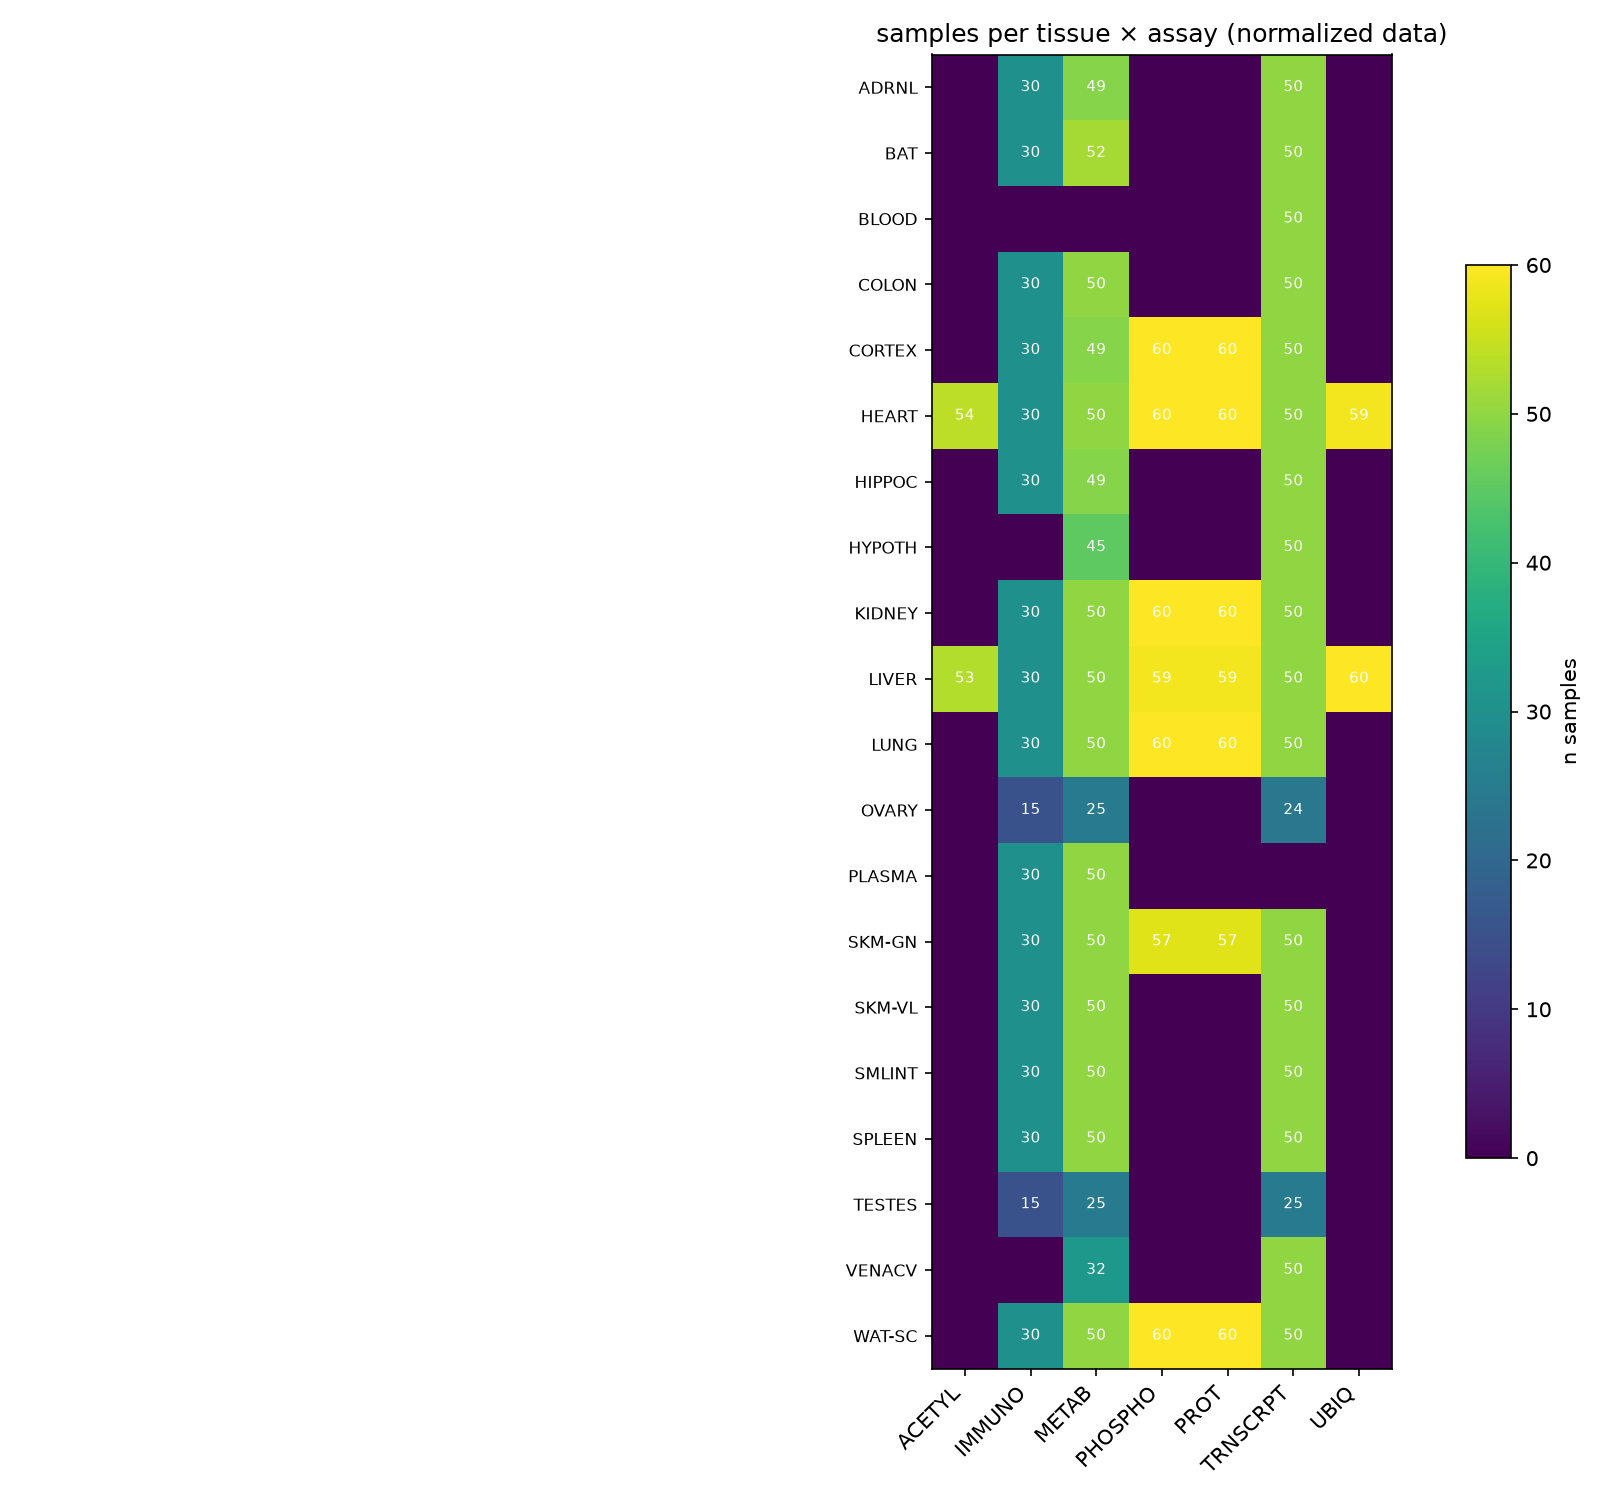

In [23]:
# ---- per-assay summary of the normalized tables (the Data table of results/SUMMARY.md) ----
# from scripts/10_make_report.py (verbatim aggregation). Note: `animals` there is the MAX over tissues
# of the per-table animal count, not the number of distinct animals; the distinct count is added next to it.
norm = inv[inv["kind"] == "norm"]
s01_by_assay = norm.groupby("assay").agg(tissues=("tissue", "nunique"), samples=("n_samples", "sum"),
                                         animals=("n_animals", "max"), features_median=("n_features", "median"))
s01_by_assay["distinct_animals"] = [len(s01_pids[("norm", a)]) for a in s01_by_assay.index]  # [notebook]
display(s01_by_assay)

# ---- tissue x assay: samples per tissue in each normalized assay (from 02_inventory, verbatim) ----
present = norm.pivot_table(index="tissue", columns="assay", values="n_samples", aggfunc="sum", fill_value=0)
display(present)
show_png(plots.missingness_heatmap(present, "samples per tissue × assay (normalized data)",
                                   S01_OUT / "tissue_by_assay.png"), width=520)

In [24]:
# ---- the fusion tissues: TRNSCRPT, PROT and METAB all present; animal overlap joined on bid ----
# from scripts/02_inventory.py::main (verbatim)
core = [a for a in ("TRNSCRPT", "PROT", "METAB") if a in present.columns]
fusion_tissues = list(present.index[(present[core] > 0).all(axis=1)]) if core else []
print("fusion tissues:", fusion_tissues)
record("s01.n_fusion_tissues", len(fusion_tissues), "01")
overlap_rows = []
for t in fusion_tissues:
    mats = {a: io.load_norm(a, t, pheno) for a in core}
    bids = {a: set(m.meta["bid"]) for a, m in mats.items()}
    common = set.intersection(*bids.values())
    overlap_rows.append({"tissue": t, **{f"n_{a}": len(b) for a, b in bids.items()}, "n_common_bid": len(common)})
overlap = pd.DataFrame(overlap_rows)
s01_ov_pub = pd.read_csv(res("02_inventory", "fusion_overlap.csv"))
display(overlap.merge(s01_ov_pub[["tissue", "n_common_bid"]], on="tissue", suffixes=("", "_published")))
record("s01.fusion_common_bid_total", overlap["n_common_bid"].sum(), "01")

fusion tissues: ['CORTEX', 'HEART', 'KIDNEY', 'LIVER', 'LUNG', 'SKM-GN', 'WAT-SC']


,tissue,n_TRNSCRPT,n_PROT,n_METAB,n_common_bid,n_common_bid_published
0,CORTEX,50,60,49,49,49
1,HEART,50,60,50,50,50
2,KIDNEY,50,60,50,50,50
3,LIVER,50,59,50,49,49
4,LUNG,50,60,50,50,50
5,SKM-GN,50,57,50,47,47
6,WAT-SC,50,60,50,50,50


**What this shows.** The design table above is the full set of animals in the export, split by sex and
training group; groups are roughly balanced by sex. `bid` and `pid` are one-to-one, and `bid` is the
first five characters of every viallabel, so joining assays on `bid` and splitting on `pid` refer to
the same animals. Transcriptomics and metabolomics cover most tissues; proteomics (and its PTM
assays) covers a small subset, and the fusion tissues are the tissues where all three core assays
exist, with nearly all animals shared across the three assays (last table). The matching printout
separates what the pipeline's `n_unmatched` column merges: sample columns found by their exact
viallabel, and those found only through the `bid` fallback. The pipeline's inventory reports zero
unmatched samples; the fallback count above says how much of that zero is the fallback at work.

**What it does not show.** A fallback match is correct at the *animal* level (bid is one-to-one with
pid) but it cannot confirm that the vial itself is the one described in PHENO. The design is also not
balanced in *time*: arrival cohort and sacrifice date differ between groups and between sexes
(`docs/DATA_GUIDE.md`, design confounds), which no count table can reveal. The `animals` column of the
pipeline's summary is the largest per-tissue count, not the number of distinct animals per assay;
both are printed above.

## 2. PCA and variance partition: what the leading axes of each assay are

**Question.** When all tissues of one assay are stacked into one matrix, what do the first principal
components track — tissue, sex, training group, or the individual animal?

**Why it matters.** A tissue-identity classifier (sections 4 onward) is only meaningful if tissue is a
real axis of the data. If the leading axes are tissue, the task is easy and the interesting question
becomes *how few features* suffice; if they are not, a high accuracy has to come from somewhere else.

**What to look for.** Two different quantities, printed as separate columns:
- `explained` — the fraction of the *total* (scaled) variance that the PC carries;
- `R2_<factor>` — the fraction of *that PC's own* variance explained by the group means of a factor.

A PC can have R² near 1 for tissue while carrying only a modest share of the total variance; the two
should not be multiplied or confused. `R2_pid` is the animal effect; animals nest sex × group, so it
is an upper bound on anything animal-level. Compare the proteomics rows with the other two assays.

Settings are the pipeline defaults of `scripts/03_eda.py` (`make eda`): outer feature join keeping
features present in ≥ 80 % of samples, TRNSCRPT from raw counts (log2 CPM, stacked gene filter),
median imputation, top 5,000 features by variance, standardized, 10 PCs.

In [25]:
section("2 PCA and variance partition")
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# from scripts/03_eda.py::r2_categorical (verbatim)
def r2_categorical(scores: np.ndarray, cat: pd.Series) -> np.ndarray:
    """Fraction of variance of each column of `scores` explained by group means of `cat`."""
    cat = pd.Series(cat).astype(str).to_numpy()
    out = []
    for j in range(scores.shape[1]):
        s = scores[:, j]
        tot = np.var(s) * len(s)
        if tot == 0:
            out.append(0.0)
            continue
        between = sum(len(s[cat == c]) * (s[cat == c].mean() - s.mean()) ** 2 for c in np.unique(cat))
        out.append(float(between / tot))
    return np.array(out)


# from scripts/03_eda.py::pca_of (verbatim)
def pca_of(om: io.OmicsMatrix, n_components: int = 10, top_var: int | None = 5000, seed: int = C.SEED):
    X = om.X.to_numpy(dtype=float)
    X = SimpleImputer(strategy="median").fit_transform(X)
    if top_var and X.shape[1] > top_var:
        v = X.var(axis=0)
        X = X[:, np.argsort(v)[::-1][:top_var]]
    X = StandardScaler().fit_transform(X)
    n = min(n_components, X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n, random_state=seed)
    S = pca.fit_transform(X)
    return S, pca.explained_variance_ratio_


# from src/tfp/cli.py::resolve_source (verbatim; cli.py is not part of the pasted library)
def resolve_source(assay: str, source: str) -> str:
    if source != "auto":
        return source
    if assay == "TRNSCRPT" and any((C.COUNTS_DIR).glob(f"{assay}__*.csv")):
        return "counts"
    return "norm"

In [26]:
# ---- stacked PCA per assay, outer join (03_eda default) and inner join (03_eda --join inner) ----
# from scripts/03_eda.py::main (trimmed: only the stacked PCA + variance-partition block; plots done below)
S02_OUT = OUT / "s02"
S02_OUT.mkdir(parents=True, exist_ok=True)
s02_scores, s02_rows, s02_oms = {}, [], {}
for assay in ("TRNSCRPT", "PROT", "METAB"):
    source = resolve_source(assay, "auto")
    for join in ("outer", "inner"):
        if source == "counts" and join == "inner":  # same matrix as the outer pass (see below): reuse its PCs
            s02_rows.append(s02_rows[-1].assign(join="inner"))
            continue
        if source == "counts":
            # the counts path ignores `join` (stacked gene filter, absent = 0 counts), so the matrix is the
            # same one section 4 uses — share it through the cache
            om = cached("TRNSCRPT_counts", lambda: io.stack_tissues(
                "TRNSCRPT", tissues=None, source="counts", join="inner", pheno=pheno,
                complete=False, drop_incomplete_samples=None))
        else:
            om = io.stack_tissues(assay, tissues=None, source=source, join=join, min_present=0.8,
                                  pheno=pheno, verbose=False)
        print(f"{assay:8s} join={join:5s}: {om.notes[-1] if source == 'norm' else om.notes[0][:120]}")
        S, ev = pca_of(om, seed=C.SEED)
        vp = pd.DataFrame({"assay": assay, "join": join, "PC": [f"PC{i+1}" for i in range(S.shape[1])],
                           "explained": ev[: S.shape[1]]})
        for col in ("tissue", "sex", "group", "pid"):
            if om.meta[col].nunique() > 1:
                vp[f"R2_{col}"] = r2_categorical(S, om.meta[col])
        s02_rows.append(vp)
        if join == "outer":
            s02_scores[assay] = (S, ev, om.meta)
            s02_oms[assay] = om            # notebook addition: kept for the UMAP in 2b
s02_vp = pd.concat(s02_rows, ignore_index=True)
s02_vp.to_csv(S02_OUT / "variance_partition_all.csv", index=False)

  loaded OmicsMatrix(TRNSCRPT-rawcounts/ADRNL: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/BAT: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/BLOOD: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/COLON: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/CORTEX: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/HEART: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/HIPPOC: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/HYPOTH: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/KIDNEY: 50 samples, 32883 features, 50 animals) (raw counts)
  loaded OmicsMatrix(TRNSCRPT-rawcounts/LIVER: 50 samples, 32883 features, 50 animals) (raw counts

  stack TRNSCRPT/counts (stacked filter): 19 tissues, 899 samples, 21193 genes with >= 10 counts in >= 20% of samples in >= 1 tissue (in every tissue: 10424; recovered 10769 tissue-restricted genes that the per-tissue inner join drops; annotation union 32883); absent = 0 counts, log2 CPM on total library size
TRNSCRPT join=outer: stack TRNSCRPT/counts (stacked filter): 19 tissues, 899 samples, 21193 genes with >= 10 counts in >= 20% of samples in >


PROT     join=outer: stack PROT/norm: 7 tissues, 416 samples, 4930 features after join=outer (union 18398)


PROT     join=inner: stack PROT/norm: 7 tissues, 416 samples, 3917 features after join=inner (union 18398)


METAB    join=outer: stack METAB/norm: 19 tissues, 876 samples, 187 features after join=outer (union 3018); WARNING 5 samples have no value for any joined feature (imputed unless dropped)


METAB    join=inner: stack METAB/norm: 19 tissues, 876 samples, 130 features after join=inner (union 3018); WARNING 6 samples have no value for any joined feature (imputed unless dropped)


In [27]:
# ---- the headline table: PCs 1–3 per assay (outer join), recomputed next to the published values ----
s02_pub = pd.concat([pd.read_csv(res("03_eda", f"variance_partition_{a}.csv")).assign(assay=a)
                     for a in ("TRNSCRPT", "PROT", "METAB")])
s02_pub_inner = pd.concat([pd.read_csv(res("03_eda_inner", f"variance_partition_{a}.csv")).assign(assay=a)
                           for a in ("TRNSCRPT", "PROT", "METAB")])
s02_top = s02_vp[(s02_vp["join"] == "outer") & s02_vp["PC"].isin(["PC1", "PC2", "PC3"])].drop(columns="join")
s02_top = s02_top.merge(s02_vp[s02_vp["join"] == "inner"][["assay", "PC", "R2_tissue"]]
                        .rename(columns={"R2_tissue": "R2_tissue_inner_join"}), on=["assay", "PC"])
cols = ["explained", "R2_tissue", "R2_sex", "R2_group", "R2_pid"]
s02_cmp = s02_top.merge(s02_pub[["assay", "PC"] + cols], on=["assay", "PC"], suffixes=("", "_pub"))
print("PCs 1–3, stacked tissues. `explained` = share of total variance; `R2_*` = share of that PC's variance.")
display(s02_top.set_index(["assay", "PC"]).round(4))
s02_dev = max(float((s02_cmp[c] - s02_cmp[c + "_pub"]).abs().max()) for c in cols)
s02_inner_pub = s02_top.merge(s02_pub_inner[["assay", "PC", "R2_tissue"]], on=["assay", "PC"], suffixes=("", "_pub"))
s02_dev_inner = float((s02_inner_pub["R2_tissue_inner_join"] - s02_inner_pub["R2_tissue_pub"]).abs().max())
print(f"max |recomputed - published| over these cells: outer join {s02_dev:.2e}; inner-join R2_tissue {s02_dev_inner:.2e}")

for a in ("TRNSCRPT", "PROT", "METAB"):
    r = s02_top[(s02_top["assay"] == a) & (s02_top["PC"] == "PC1")].iloc[0]
    p = s02_pub[(s02_pub["assay"] == a) & (s02_pub["PC"] == "PC1")].iloc[0]
    print(f"{a:8s} PC1: explained {r['explained']:.4f} (published {p['explained']:.4f})   "
          f"R2_tissue {r['R2_tissue']:.4f} (published {p['R2_tissue']:.4f})   R2_sex {r['R2_sex']:.4f} (published {p['R2_sex']:.4f})")
    record(f"s02.{a}_PC1_explained", r["explained"], "02")
    record(f"s02.{a}_PC1_R2_tissue", r["R2_tissue"], "02")
    record(f"s02.{a}_PC1_R2_sex", r["R2_sex"], "02")

PCs 1–3, stacked tissues. `explained` = share of total variance; `R2_*` = share of that PC's variance.


explained  R2_tissue  R2_sex  R2_group  R2_pid  R2_tissue_inner_join
assay    PC                                                                       
TRNSCRPT PC1     0.2795     0.9950  0.0000    0.0001  0.0003                0.9950
         PC2     0.1729     0.9813  0.0023    0.0005  0.0033                0.9813
         PC3     0.1166     0.9857  0.0016    0.0000  0.0022                0.9857
PROT     PC1     0.1596     0.0008  0.2473    0.0037  0.2625                0.0009
         PC2     0.0574     0.0039  0.1630    0.0072  0.2140                0.0039
         PC3     0.0385     0.2078  0.0229    0.0063  0.1363                0.2184
METAB    PC1     0.1850     0.9918  0.0000    0.0005  0.0037                0.9888
         PC2     0.1391     0.9790  0.0007    0.0002  0.0031                0.9733
         PC3     0.1099     0.9768  0.0011    0.0005  0.0040                0.9699

max |recomputed - published| over these cells: outer join 1.05e-15; inner-join R2_tissue 5.83e-16
TRNSCRPT PC1: explained 0.2795 (published 0.2795)   R2_tissue 0.9950 (published 0.9950)   R2_sex 0.0000 (published 0.0000)
PROT     PC1: explained 0.1596 (published 0.1596)   R2_tissue 0.0008 (published 0.0008)   R2_sex 0.2473 (published 0.2473)
METAB    PC1: explained 0.1850 (published 0.1850)   R2_tissue 0.9918 (published 0.9918)   R2_sex 0.0000 (published 0.0000)


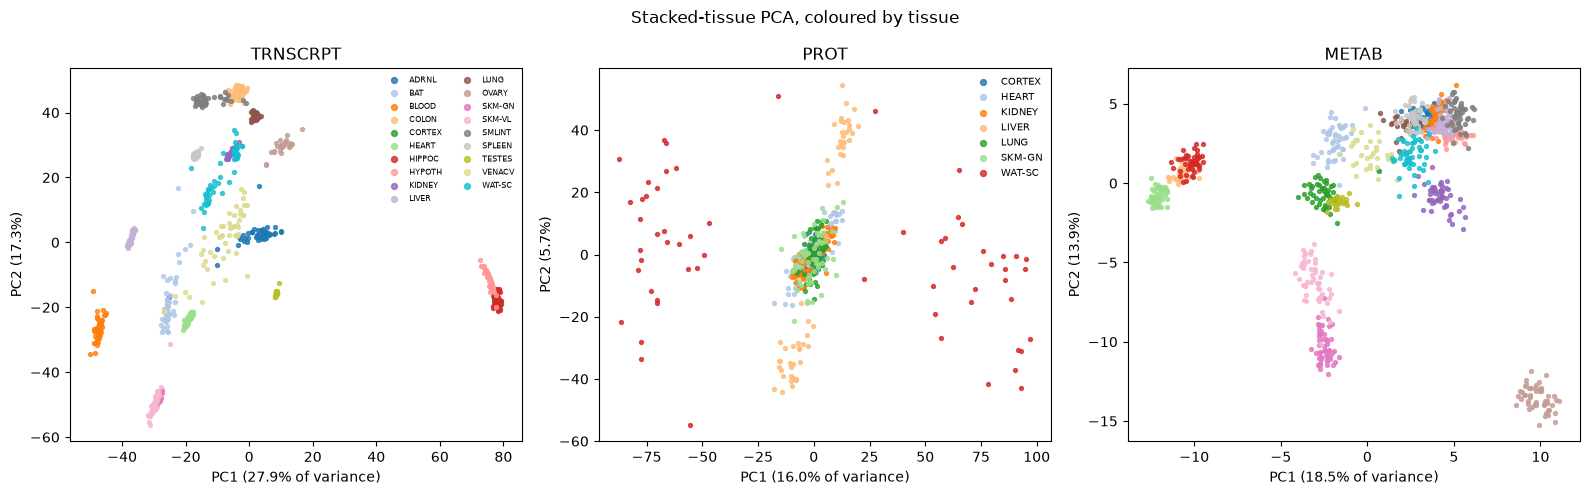

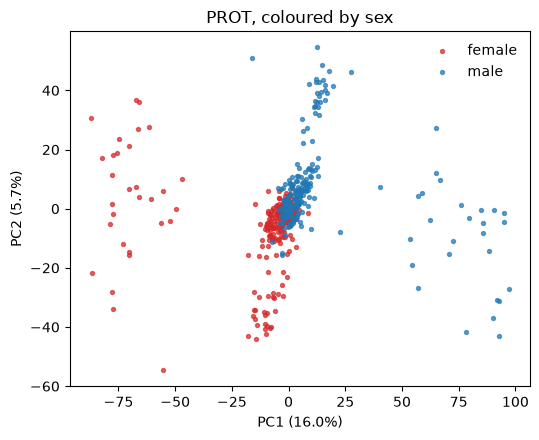

In [28]:
# ---- PC1 vs PC2 per assay, coloured by tissue (outer join; same scores as the table) ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmap = plt.get_cmap("tab20")
for ax, (a, (S, ev, meta)) in zip(axes, s02_scores.items()):
    tissues = sorted(meta["tissue"].unique())
    for i, t in enumerate(tissues):
        m = (meta["tissue"] == t).to_numpy()
        ax.scatter(S[m, 0], S[m, 1], s=8, color=cmap(i % 20), label=t, alpha=0.8)
    ax.set_title(a)
    ax.set_xlabel(f"PC1 ({ev[0]:.1%} of variance)")
    ax.set_ylabel(f"PC2 ({ev[1]:.1%})")
axes[0].legend(fontsize=6, ncol=2, frameon=False, markerscale=1.5)
axes[1].legend(fontsize=7, frameon=False, markerscale=1.5)
fig.suptitle("Stacked-tissue PCA, coloured by tissue")
plt.tight_layout()
plt.show()

# PROT again, coloured by sex: the axis PC1 does track
S, ev, meta = s02_scores["PROT"]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for sex, c in (("female", "tab:red"), ("male", "tab:blue")):
    m = (meta["sex"] == sex).to_numpy()
    ax.scatter(S[m, 0], S[m, 1], s=8, color=c, label=sex, alpha=0.7)
ax.set_xlabel(f"PC1 ({ev[0]:.1%})")
ax.set_ylabel(f"PC2 ({ev[1]:.1%})")
ax.set_title("PROT, coloured by sex")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**What this shows.** For transcripts and metabolites, the first three PCs are almost entirely tissue:
R² of tissue on each PC is close to 1, and the scatter plots separate into tissue clusters. Proteomics
is the exception: its PC1 has essentially no tissue component, and sex and the individual animal
explain more of it than tissue does; tissue appears only weakly on a later PC. The inner-join column
shows the same picture, so the choice of feature join does not drive it. This is what the
normalization of `PROT_*_NORM_DATA` predicts: values are log2 ratios to a *per-tissue* reference pool,
median-centred per sample, so every tissue sits near zero and between-tissue abundance differences are
removed by design.

**What it does not show.** R² of a PC is not a share of the total variance: a tissue R² near 1 on a PC
that carries a minority of the total variance does not mean tissue explains the data "almost entirely" — read
`explained` and `R2_tissue` separately. This is descriptive, on all samples, and nothing here selects
features for later sections. It also does not say whether training (the `group` factor) is visible
*within* a tissue: stacked across tissues, group R² is negligible for every assay, which is expected
when tissue dominates, and says nothing about within-tissue effects.

### 2b. UMAP: the same matrices, viewed non-linearly

**Question.** PCA shows only linear axes, and only a few of them at a time. Does a non-linear
embedding of the same data show the same grouping: tissue for transcripts and metabolites, and
something other than tissue for proteomics?

**Why it matters.** Several tissues that PCA stacks on top of each other may still be separable in the
full space. That is the question the classifiers in sections 4–5 answer formally. UMAP is a quick visual
check of which tissues sit next to each other: the muscle pair, the brain regions, vena cava and fat.

**How it is computed.** For each assay: the same matrix as the PCA above, with the same preprocessing
(median imputation, 5,000 highest-variance features, z-scoring), then its first 50 principal
components, then UMAP (`umap-learn`, 15 neighbours, minimum distance 0.1, fixed seed). The
first run in a kernel compiles UMAP's numba code, which takes a few extra seconds.

**What to look for.** Whether each tissue forms its own island, and which tissues share one. The table
makes that quantitative: the share of each sample's 15 nearest neighbours that come from the same
tissue, in the UMAP map and in the 50-PC space it was built from.

In [29]:
# notebook addition (not in the pipeline): UMAP of the section-2 matrices; umap-learn is optional → import-guarded
try:
    import umap
except ImportError:
    umap = None
    print("umap-learn is not installed in this kernel: 2b is skipped (conda install -c conda-forge umap-learn)")

from sklearn.neighbors import NearestNeighbors


def s02_neighbour_purity(Z: np.ndarray, labels: pd.Series, k: int = 15) -> float:
    """Mean share of each sample's k nearest neighbours (itself excluded) that carry the same label."""
    idx = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(Z, return_distance=False)[:, 1:]
    lab = labels.to_numpy()
    return float((lab[idx] == lab[:, None]).mean())


s02_umap, s02_purity = {}, []
if umap is not None:
    for a, om in s02_oms.items():
        P50, _ = pca_of(om, n_components=50, seed=C.SEED)          # same preprocessing as the PCA above
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")                        # "n_jobs overridden by random_state"
            U = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=C.SEED).fit_transform(P50)
        s02_umap[a] = (U, om.meta)
        for col in ("tissue", "sex"):
            s02_purity.append({"assay": a, "label": col, "n_samples": len(U),
                               "same-label share of 15 neighbours, 50-PC space": s02_neighbour_purity(P50, om.meta[col]),
                               "same-label share of 15 neighbours, UMAP": s02_neighbour_purity(U, om.meta[col]),
                               "chance (share of the commonest label)": float(om.meta[col].value_counts(normalize=True).iloc[0])})
    s02_purity = pd.DataFrame(s02_purity)
    s02_purity.to_csv(S02_OUT / "umap_neighbour_purity.csv", index=False)
    display(s02_purity.round(3))
    for r in s02_purity.itertuples(index=False):
        record(f"s02.umap_purity_{r.assay}_{r.label}", r[4], "02", note="UMAP neighbour purity")
        record(f"s02.pc50_purity_{r.assay}_{r.label}", r[3], "02", note="50-PC neighbour purity")

,assay,label,n_samples,"same-label share of 15 neighbours, 50-PC space","same-label share of 15 neighbours, UMAP",chance (share of the commonest label)
0,TRNSCRPT,tissue,899,0.984,0.986,0.056
1,TRNSCRPT,sex,899,0.840,0.858,0.501
2,PROT,tissue,416,0.885,0.983,0.144
3,PROT,sex,416,0.858,0.854,0.502
4,METAB,tissue,876,0.995,0.995,0.059
5,METAB,sex,876,0.768,0.811,0.505


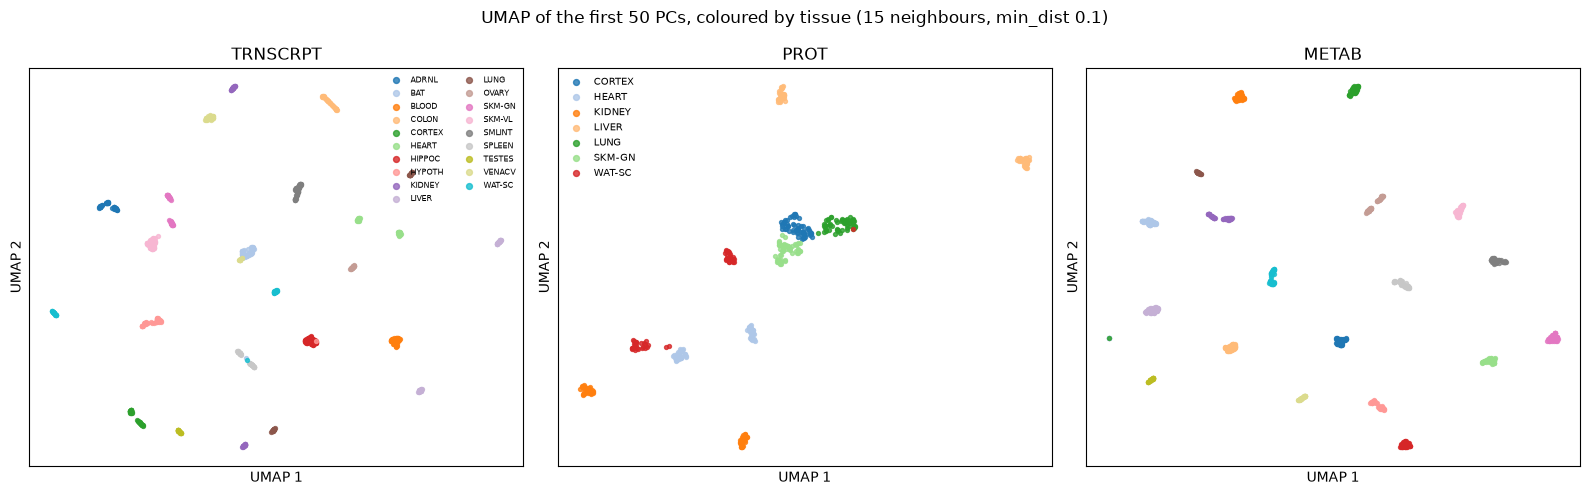

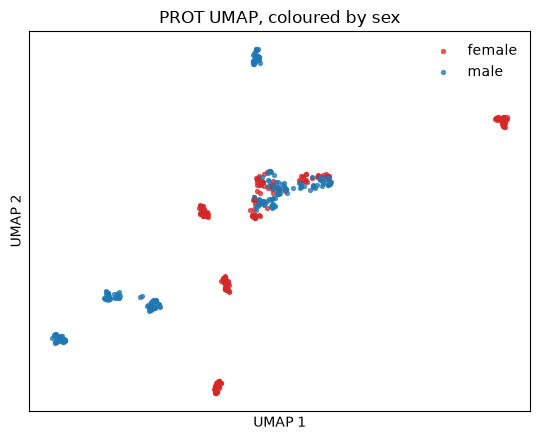

In [30]:
# UMAP per assay, coloured by tissue (same colours as the PCA figure), and PROT again coloured by sex
if s02_umap:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    cmap = plt.get_cmap("tab20")
    for ax, (a, (U, meta)) in zip(axes, s02_umap.items()):
        for i, t in enumerate(sorted(meta["tissue"].unique())):
            m = (meta["tissue"] == t).to_numpy()
            ax.scatter(U[m, 0], U[m, 1], s=8, color=cmap(i % 20), label=t, alpha=0.8)
        ax.set_title(a)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_xticks([]); ax.set_yticks([])
    axes[0].legend(fontsize=6, ncol=2, frameon=False, markerscale=1.5)
    axes[1].legend(fontsize=7, frameon=False, markerscale=1.5)
    fig.suptitle("UMAP of the first 50 PCs, coloured by tissue (15 neighbours, min_dist 0.1)")
    plt.tight_layout()
    plt.show()

    U, meta = s02_umap["PROT"]
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    for sex, c in (("female", "tab:red"), ("male", "tab:blue")):
        m = (meta["sex"] == sex).to_numpy()
        ax.scatter(U[m, 0], U[m, 1], s=8, color=c, label=sex, alpha=0.7)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("PROT UMAP, coloured by sex")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

**What this shows.** The neighbour table gives the reading in numbers. For each assay and label it
compares the share of a sample's nearest neighbours that share its tissue (or sex) in the UMAP map
and in the 50-PC space the map was built from, against the share expected from the commonest label
alone. Where the tissue share is near 1 in both spaces, tissues form their own islands. The figure
then shows which tissues, if any, share an island, and whether a tissue splits into two nearby islands
(compare the sex rows of the table). For proteomics, a tissue grouping that PC1 did not show is **not**
evidence of tissue biology. This outer-join matrix median-imputes proteins that are missing from
whole tissues, and section 3 shows that the missingness pattern alone identifies the tissue. The
per-tissue reference normalization has already removed abundance differences between tissues.

**What it does not show.** UMAP keeps local neighbourhoods, not global geometry. Distances *between*
islands, their sizes and their positions mean little, and they change with the number of neighbours
and the seed. Only who-is-next-to-whom is interpretable. Like the PCA, this is descriptive, on all
samples, and selects nothing for later sections. A tissue island is not a classifier's accuracy:
sections 4–5 measure that on held-out animals.

## 3. Proteomics diagnostic: why cross-tissue PROT values are not comparable

**Question.** Section 2 found no tissue axis in the stacked proteomics PCA, yet a cross-tissue
proteomics classifier still predicts tissue well. What is it using?

**Why it matters.** If the classifier lives on how each tissue was *processed* (its TMT plexes, its
missing-value pattern, residual offsets of the per-tissue normalization) rather than on protein
abundance, then a "proteomic tissue fingerprint" is an artefact, and proteomics has to be used within
tissue only.

**What to look for.** Three test accuracies on the same held-out animals, against chance
(one over the number of tissues):
1. the tuned L2 logistic-regression pipeline, fitted as in section 4 (`model_as_fitted`);
2. a model that sees **only which values are missing** (`missingness_indicators_only`);
3. a model after each tissue's feature means are subtracted (`per_tissue_means_removed`). This uses
   the tissue labels to centre the data, so it is a diagnostic of what is left once mean offsets are
   erased — never an evaluation.

If (1) and (2) are high and (3) falls toward chance, the signal is processing, not biology. Then a
second check: inside HEART and LIVER, is the TMT channel a sample was run in confounded with its sex?

Settings are those of `scripts/04_prot_diagnostic.py --assay PROT` (`make prot-diagnostic`):
normalized PROT tables, inner feature join, animal-grouped stratified 5-fold split with the pipeline
seed, **outer fold 0 only** (as published), prefilter 5,000, full tuning grid.

In [31]:
section("3 Proteomics diagnostic")
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# from scripts/04_prot_diagnostic.py::r2_cat (verbatim)
def r2_cat(x: np.ndarray, cat: np.ndarray) -> float:
    ok = ~np.isnan(x)
    x, cat = x[ok], cat[ok]
    if len(x) < 3 or x.var() == 0 or len(np.unique(cat)) < 2:
        return np.nan
    between = sum(((x[cat == c].mean() - x.mean()) ** 2) * (cat == c).sum() for c in np.unique(cat))
    return float(between / (x.var() * len(x)))


# from scripts/04_prot_diagnostic.py::main (trimmed: argparse/report dropped; defaults of
# common_parser inlined: n_splits=5, prefilter=5000, seed=C.SEED, quick=False, no --complete-features)
S03_OUT = OUT / "s03"
S03_OUT.mkdir(parents=True, exist_ok=True)
om = io.stack_tissues("PROT", tissues=None, source="norm", join="inner", pheno=pheno,
                      complete=False, drop_incomplete_samples=None)
X = om.X.to_numpy(dtype=float)
y = om.meta["tissue"].astype(str).to_numpy()
g = om.groups()
feat = np.asarray(om.X.columns)
classes = sorted(np.unique(y))
tr, te = next(iter(grouped_kfold(om.meta, "tissue", 5, C.SEED)))
print(f"fold 0: {len(np.unique(g[tr]))} training / {len(np.unique(g[te]))} test animals; "
      f"{len(tr)} / {len(te)} samples; {len(classes)} tissues; overall fraction of NaN values {np.isnan(X).mean():.3f}")

# 1. tissue R² per protein, all samples (descriptive)
tr2 = pd.Series([r2_cat(X[:, j], y) for j in range(X.shape[1])], index=feat, name="tissue_R2")
print("across-tissue R² of tissue per protein, quantiles:", tr2.quantile([0.5, 0.9, 0.99]).round(3).to_dict(),
      f"; proteins with R² > 0.5: {int((tr2 > 0.5).sum())} of {len(tr2)}")

  loaded OmicsMatrix(PROT/CORTEX: 60 samples, 11108 features, 60 animals)
  loaded OmicsMatrix(PROT/HEART: 60 samples, 9184 features, 60 animals)
  loaded OmicsMatrix(PROT/KIDNEY: 60 samples, 9852 features, 60 animals)
  loaded OmicsMatrix(PROT/LIVER: 59 samples, 9791 features, 59 animals)
  loaded OmicsMatrix(PROT/LUNG: 60 samples, 10877 features, 60 animals)


  loaded OmicsMatrix(PROT/SKM-GN: 57 samples, 5999 features, 57 animals)
  loaded OmicsMatrix(PROT/WAT-SC: 60 samples, 9964 features, 60 animals)
  stack PROT/norm: 7 tissues, 416 samples, 3917 features after join=inner (union 18398)
fold 0: 48 training / 12 test animals; 333 / 83 samples; 7 tissues; overall fraction of NaN values 0.018


across-tissue R² of tissue per protein, quantiles: {0.5: 0.062, 0.9: 0.209, 0.99: 0.545} ; proteins with R² > 0.5: 49 of 3917


In [32]:
# 2. the fitted model (tuned inside the training fold only) and its largest coefficients
est = models.fit_tuned("logreg_l2", X[tr], y[tr], g[tr], prefilter=5000, quick=False, seed=C.SEED)
clf = est.named_steps["clf"]
kept = est.named_steps["prefilter"].idx_
coef = pd.DataFrame(clf.coef_, index=list(clf.classes_), columns=feat[kept])
meta_path = C.META_DIR / "PROT.csv"
channel = None
if meta_path.exists():
    meta = pd.read_csv(meta_path, dtype=str, low_memory=False).drop_duplicates("viallabel").set_index("viallabel")
    if "tmt11_channel" in meta.columns:
        channel = meta["tmt11_channel"].reindex(om.X.index).to_numpy()
sex = om.meta["sex"].astype(str).to_numpy()
rows = []
for t in classes:
    top = coef.loc[t].abs().sort_values(ascending=False).head(3)
    for f in top.index:
        j = int(np.flatnonzero(feat == f)[0])
        mk = y == t
        nan_by_t = pd.Series(np.isnan(X[:, j])).groupby(y).mean()
        rows.append({"tissue": t, "feature_ID": f, "coef": float(coef.loc[t, f]),
                     "tissue_R2_all_samples": float(tr2[f]),
                     "R2_sex_within_tissue": r2_cat(X[mk, j], sex[mk]),
                     "R2_channel_within_tissue": r2_cat(X[mk, j], channel[mk]) if channel is not None else np.nan,
                     "frac_nan_in_tissue": float(nan_by_t[t]), "max_frac_nan_other_tissue": float(nan_by_t.drop(t).max())})
top_df = pd.DataFrame(rows)
top_df.to_csv(S03_OUT / "diagnostic_top_coefs.csv", index=False)
print("largest-|coefficient| proteins per tissue (3 each):")
display(top_df.round(3))

largest-|coefficient| proteins per tissue (3 each):


,tissue,feature_ID,coef,tissue_R2_all_samples,R2_sex_within_tissue,R2_channel_within_tissue,frac_nan_in_tissue,max_frac_nan_other_tissue
0,CORTEX,NP_001020878.1,-0.040,0.609,0.000,0.365,0.167,0.000
1,CORTEX,NP_001014144.1,0.039,0.665,0.006,0.407,0.333,0.175
2,CORTEX,NP_872615.3,-0.033,0.237,0.001,0.178,0.000,0.333
3,HEART,NP_695209.1,0.030,0.792,0.009,0.315,0.167,0.000
4,HEART,NP_001004240.1,0.030,0.679,0.004,0.225,0.333,0.000
5,HEART,NP_446314.2,0.029,0.565,0.015,0.297,0.167,0.333
6,KIDNEY,XP_001058548.1,0.032,0.633,0.007,0.290,0.167,0.500
7,KIDNEY,NP_001099961.2,0.030,0.746,0.069,0.358,0.500,0.500
8,KIDNEY,XP_002726783.1,0.030,0.618,0.051,0.219,0.167,0.667
9,LIVER,NP_001127981.1,-0.034,0.505,0.228,0.415,0.169,0.500


In [33]:
# 3. fold-0 accuracies: as fitted / missingness only / per-tissue means removed (label-using)
# from scripts/04_prot_diagnostic.py::main (verbatim)
acc = {"model_as_fitted": float(np.mean(est.predict(X[te]) == y[te]))}
M = np.isnan(X).astype(float)
if M[tr].std(axis=0).max() > 0:
    miss = LogisticRegression(C=0.1, max_iter=3000).fit(M[tr], y[tr])
    acc["missingness_indicators_only"] = float(np.mean(miss.predict(M[te]) == y[te]))
else:
    acc["missingness_indicators_only"] = np.nan
Xi = SimpleImputer(strategy="median").fit(X[tr]).transform(X)
Xc = Xi.copy()
for t in classes:  # centre every tissue on its TRAINING-fold feature means (uses labels: diagnostic only)
    mu = Xi[tr][y[tr] == t].mean(axis=0)
    Xc[y == t] -= mu
sc = StandardScaler().fit(Xc[tr])
cen = LogisticRegression(C=0.1, max_iter=3000).fit(sc.transform(Xc[tr]), y[tr])
acc["per_tissue_means_removed"] = float(np.mean(cen.predict(sc.transform(Xc[te])) == y[te]))
acc["chance_balanced"] = 1.0 / len(classes)
acc_df = pd.DataFrame([acc])
acc_df.to_csv(S03_OUT / "diagnostic_accuracy.csv", index=False)

s03_pub = pd.read_csv(res("04_baselines", "PROT", "diagnostic_accuracy.csv"))
print(f"fold-0 test accuracy ({len(classes)} tissues; chance = 1/{len(classes)}):")
display(pd.concat([acc_df.assign(run="recomputed"), s03_pub.assign(run="published")]).set_index("run").round(4))
for k in acc:
    record(f"s03.{k}", acc[k], "03")

fold-0 test accuracy (7 tissues; chance = 1/7):


,model_as_fitted,missingness_indicators_only,per_tissue_means_removed,chance_balanced
run,,,,
recomputed,0.9759,1.0,0.1928,0.1429
published,0.9759,1.0,0.1928,0.1429


**What this shows.** The quantile printout: for most proteins tissue explains only a small share of
the variance across the stacked samples — the per-tissue reference ratios and per-sample centring
remove most mean differences — but a minority keep tissue-specific offsets. The accuracy table: the fitted model classifies held-out
animals' tissues far above chance; the missing-value pattern *alone* does at least as well; and once
each tissue's mean offsets are removed, accuracy falls to near chance. The classifier therefore rests
on how each tissue was processed (which proteins each tissue's plexes detected, and residual offsets
of the per-tissue normalization), not on a proteomic tissue fingerprint. The top-coefficient table
shows the same from the model's side: its most-used proteins are among the minority with large
tissue offsets, several are partly missing in their own or in other tissues, and their within-tissue
variation mostly tracks TMT channel more than sex.

**What it does not show.** This is one fold of five, as in the pipeline's diagnostic, so its
accuracies have no fold-to-fold spread; the full 5-fold PROT baseline is in section 4's results. The
mean-removal model uses the labels to centre and is not a valid classifier. It does not say that
proteomics lacks tissue biology — only that these per-tissue-normalized tables cannot show it.

In [34]:
# ---- TMT channel vs sex within each proteomics tissue ----
# from scripts/03_eda.py::shared_with (verbatim). Association of a covariate with a design factor on a
# 0–1 scale (Cramér's V² for a categorical covariate); 1 = the covariate is the factor in this tissue.
def shared_with(cov, factor) -> float:
    cov = pd.Series(np.asarray(cov)).reset_index(drop=True)
    fac = pd.Series(np.asarray(factor)).astype(str).reset_index(drop=True)
    ok = cov.notna().to_numpy()
    if ok.sum() < 3 or cov[ok].nunique() < 2 or fac[ok].nunique() < 2:
        return np.nan
    if pd.api.types.is_numeric_dtype(cov):
        return float(r2_categorical(cov[ok].to_numpy(dtype=float)[:, None], fac[ok])[0])
    ct = pd.crosstab(cov[ok].astype(str), fac[ok]).to_numpy(dtype=float)
    n = ct.sum()
    expected = np.outer(ct.sum(1), ct.sum(0)) / n
    chi2 = ((ct - expected) ** 2 / expected).sum()
    return float(chi2 / (n * (min(ct.shape) - 1)))


# recompute R2_tmt11_channel~sex per tissue (as scripts/03_eda.py::main does on each tissue's own table),
# next to the published within-tissue table
s03_wt = pd.read_csv(res("03_eda", "within_tissue_pca_PROT.csv")).set_index("tissue")
s03_rows = []
for t in s03_wt.index:
    sub = io.load_norm("PROT", t, pheno)
    ch = meta["tmt11_channel"].reindex(sub.X.index)
    s03_rows.append({"tissue": t, "n": sub.n_samples, "n_channels": int(ch.nunique()),
                     "R2_channel~sex (recomputed)": shared_with(ch, sub.meta["sex"]),
                     "R2_channel~sex (published)": s03_wt.loc[t, "R2_tmt11_channel~sex"],
                     "max_R2_sex_PC1-5 (published)": s03_wt.loc[t, "max_R2_sex_PC1-5"],
                     "max_R2_channel|design_PC1-5 (published)": s03_wt.loc[t, "max_R2_tmt11_channel|design_PC1-5"]})
s03_ch = pd.DataFrame(s03_rows).set_index("tissue")
display(s03_ch.round(3))
# the sex-by-channel crosstab in the two tissues where they coincide
for t in ("HEART", "LIVER"):
    sub = io.load_norm("PROT", t, pheno)
    print(f"\n{t}: samples per TMT channel x sex")
    display(pd.crosstab(meta["tmt11_channel"].reindex(sub.X.index).to_numpy(), sub.meta["sex"].to_numpy(),
                        rownames=["tmt11_channel"], colnames=["sex"]).T)
    record(f"s03.{t}_R2_channel_sex", s03_ch.loc[t, "R2_channel~sex (recomputed)"], "03")

,n,n_channels,R2_channel~sex (recomputed),R2_channel~sex (published),max_R2_sex_PC1-5 (published),max_R2_channel|design_PC1-5 (published)
tissue,,,,,,
CORTEX,60,10,0.000,0.000,0.307,0.542
HEART,60,10,1.000,1.000,0.880,0.457
KIDNEY,60,10,0.000,0.000,0.989,0.911
LIVER,59,10,1.000,1.000,0.952,0.333
LUNG,60,10,0.000,0.000,0.420,0.697
SKM-GN,57,10,0.003,0.003,0.423,0.324
WAT-SC,60,10,0.000,0.000,0.919,0.178



HEART: samples per TMT channel x sex


tmt11_channel,126C,127C,127N,128C,128N,129C,129N,130C,130N,131N
sex,,,,,,,,,,
female,0,0,6,0,6,0,6,0,6,6
male,6,6,0,6,0,6,0,6,0,0



LIVER: samples per TMT channel x sex


tmt11_channel,126C,127C,127N,128C,128N,129C,129N,130C,130N,131N
sex,,,,,,,,,,
female,0,0,6,0,6,0,6,0,6,5
male,6,6,0,6,0,6,0,6,0,0


**What this shows.** In HEART and LIVER the TMT channel and sex are the same variable (association 1:
each channel holds one sex only, as the crosstabs show), while in the other proteomics tissues they
are unrelated. So in those two tissues any sex difference in protein abundance is also a channel
difference and cannot be attributed to biology from these data alone. The last published column is
the share of a within-tissue PC that channel still explains after the sex × group design means are
removed — a purely technical component in several tissues.

**What it does not show.** Channel–sex confounding does not mean the sex effects in HEART and LIVER
are false; it means this design cannot separate them from a channel effect. Correcting for channel in
those tissues would remove the sex effect with it.

## 4. Tissue-fingerprint baselines (transcriptome, 19 tissues)

**Question.** How well do *simple, tuned* classifiers tell the 19 tissues apart from RNA-seq, when
every sample of a test animal is kept out of training?

**Why it matters.** Every later claim — compact panels (section 5), certified panel sizes, shift
tests, fusion — has to beat this reference on the same folds. If the simple models are already near
the ceiling, "tissue identity from the transcriptome" is not a result by itself; the content is in
how *small* and how *robust* the fingerprint can be.

**What to look for.** (1) The leakage guard: a split over *samples* puts the same animal on both
sides, and the pipeline's assertion refuses it; the animal-grouped split passes. (2) The balanced
accuracy of the three baselines, recomputed here, next to the published values. (3) Which tissue
pairs remain confused even with all genes.

Design (from the Makefile target `baselines`, with the published `MODELS=centroid,logreg_l2,rf`):
raw counts stacked across tissues → log2 CPM, 5 animal-grouped outer folds stratified on tissue,
variance prefilter to 5,000 genes inside each fold, a small grid search inside each training fold.
The L1 logistic model is in the library's default list but was **never run** in the published
pipeline; this notebook reproduces the three models that were.

In [35]:
section("4 baselines")


# from src/tfp/cli.py::resolve_source (verbatim) — cli.py is not pasted into this notebook
def resolve_source(assay: str, source: str) -> str:
    if source != "auto":
        return source
    if assay == "TRNSCRPT" and any((C.COUNTS_DIR).glob(f"{assay}__*.csv")):
        return "counts"
    return "norm"


# from scripts/04_fingerprint_baselines.py::main (trimmed: argparse defaults inlined —
# --assay TRNSCRPT, --source auto, no --tissues, no --complete-features, no --drop-incomplete-samples)
S04_SOURCE = resolve_source("TRNSCRPT", "auto")
pheno = cached("pheno", io.load_pheno)
S04_OM = cached("TRNSCRPT_counts", lambda: io.stack_tissues(
    "TRNSCRPT", tissues=None, source=resolve_source("TRNSCRPT", "auto"), join="inner", pheno=pheno,
    complete=False, drop_incomplete_samples=None))
om = S04_OM
print("source:", S04_SOURCE)
print(om)
# the stacking note (genes kept by the pre-split filter). Picked by content: the script's report used
# om.notes[-1], which for counts is the long per-gene "expressed in n tissues" list, not this note.
print(next(n for n in om.notes if n.startswith("stack ")))
record("s04.n_samples", om.n_samples, "04")
record("s04.n_features", om.n_features, "04")
record("s04.n_animals", om.n_animals, "04")

source: counts
OmicsMatrix(TRNSCRPT-counts-stacked: 899 samples, 21193 features, 50 animals)
stack TRNSCRPT/counts (stacked filter): 19 tissues, 899 samples, 21193 genes with >= 10 counts in >= 20% of samples in >= 1 tissue (in every tissue: 10424; recovered 10769 tissue-restricted genes that the per-tissue inner join drops; annotation union 32883); absent = 0 counts, log2 CPM on total library size


### 4a. The leakage guard, fired on purpose

Each rat contributes up to 19 tissue samples. A plain `KFold` over *samples* scatters one animal's
tissues across train and test, so a model could learn that animal's individual signature (sex,
library batch, genotype) and get credit for it on the test side. `splits.assert_no_group_leak` checks
every split the pipeline makes. Below it is run first on a deliberately wrong split, then on the
grouped split the pipeline actually uses.

In [36]:
from sklearn.model_selection import KFold

S04_N_SPLITS = 5          # --n-splits default
# (1) the wrong split: 5-fold over samples, ignoring which animal each sample came from
bad_tr, bad_te = next(KFold(n_splits=S04_N_SPLITS, shuffle=True, random_state=C.SEED).split(om.X))
try:
    splits.assert_no_group_leak(om.meta, bad_tr, bad_te)          # group = "pid" by default
    print("sample-level split: no leak detected (unexpected)")
except AssertionError as e:
    print("sample-level split REJECTED ->", e)
    n_shared = len(set(om.meta.iloc[bad_tr]["pid"]) & set(om.meta.iloc[bad_te]["pid"]))
    print(f"  animals on both sides: {n_shared} of {om.n_animals}")
    record("s04.leak_shared_animals_samplekfold", n_shared, "04", "this run; plain KFold(5, shuffle, SEED)")

# (2) the pipeline's split: stratified on tissue, grouped by animal (pid). grouped_kfold itself calls the
# assertion on every fold; here it is called once more, explicitly, so the pass is visible.
# These are exactly the folds models.evaluate_cv makes (same meta, label, n_splits, seed) — section 13 reuses them.
S04_FOLDS = list(grouped_kfold(om.meta, "tissue", S04_N_SPLITS, C.SEED))
# the fold of each vial, written so notebook 02 (section 13) can assert it rebuilt exactly these folds
(OUT / "s04").mkdir(parents=True, exist_ok=True)
pd.DataFrame({"viallabel": S04_OM.meta.index[np.concatenate([te for _, te in S04_FOLDS])],
              "fold": np.concatenate([[k] * len(te) for k, (_, te) in enumerate(S04_FOLDS)])}).to_csv(OUT / "s04" / "folds.csv", index=False)
rows = []
for f, (tr, te) in enumerate(S04_FOLDS):
    splits.assert_no_group_leak(om.meta, tr, te)
    rows.append(splits.describe_split(om.meta, tr, te) | {"fold": f})
print("animal-grouped split: all", len(S04_FOLDS), "folds pass the assertion")
display(pd.DataFrame(rows).set_index("fold"))

sample-level split REJECTED -> 50 pid(s) appear in both train and test: ['10023259', '10024735', '10025626', '10025707', '10025979']
  animals on both sides: 50 of 50
animal-grouped split: all 5 folds pass the assertion


,n_train,n_test,animals_train,animals_test,classes_train,classes_test
fold,,,,,,
0,720,179,40,10,19,19
1,719,180,40,10,19,19
2,719,180,40,10,19,19
3,719,180,40,10,19,19
4,719,180,40,10,19,19


**What this shows.** The assertion is live: a sample-level split is refused with the list of animals
that sit on both sides, and the animal-grouped folds pass. The table gives the animals and samples per
fold. **What it does not show.** Grouping by animal removes animal-level leakage only. It does not
remove *batch* leakage: each tissue was extracted and sequenced as one batch (section 2), so "tissue"
and "library batch" cannot be separated by any split of these data.

In [37]:
# from scripts/04_fingerprint_baselines.py::main (trimmed: dropped --quick and --time-one-fold branches,
# report.add_section, writing per_fold/predictions CSVs to results/).
# Runtime: the three models took 150-200 s here on a 20-core workstation (random forest is about half of it). To keep
# the default run short, RECOMPUTE=False fits centroid and logreg_l2 live and LOADS the random-forest
# folds from results/; RECOMPUTE=True fits all three.
S04_MODELS = ["centroid", "logreg_l2", "rf"]      # Makefile MODELS (published run); logreg_l1 was never run
S04_LIVE = S04_MODELS if RECOMPUTE else ["centroid", "logreg_l2"]
S04_PREFILTER = 5000                              # --prefilter default
s04_res = models.evaluate_cv(om, label="tissue", kinds=S04_LIVE, n_splits=S04_N_SPLITS,
                             prefilter=S04_PREFILTER, quick=False, seed=C.SEED)
s04_per_fold = s04_res.per_fold.assign(source="recomputed")
s04_conf = dict(s04_res.confusion)
for kind in [k for k in S04_MODELS if k not in S04_LIVE]:          # loaded, not recomputed
    pf = pd.read_csv(res("04_baselines", "TRNSCRPT", "per_fold.csv"))
    s04_per_fold = pd.concat([s04_per_fold, pf[pf["model"] == kind].assign(source="loaded")], ignore_index=True)
    s04_conf[kind] = pd.read_csv(res("04_baselines", "TRNSCRPT", f"confusion_{kind}.csv"), index_col=0)
summ = CVResult(s04_per_fold.drop(columns="source"), s04_res.predictions, s04_conf).summary()
fit_time = s04_per_fold.groupby("model")["fit_seconds"].agg(fit_seconds_mean="mean", fit_seconds_total="sum").reset_index()
summ = summ.merge(fit_time, on="model").merge(s04_per_fold.groupby("model")["source"].first().reset_index(), on="model")
(OUT / "s04").mkdir(parents=True, exist_ok=True)
summ.to_csv(OUT / "s04" / "summary.csv", index=False)

# recomputed vs published, side by side
pub = pd.read_csv(res("04_baselines", "TRNSCRPT", "summary.csv"))
cmp = summ[["model", "source", "balanced_accuracy_mean", "balanced_accuracy_std", "macro_f1_mean", "log_loss_mean"]].merge(
    pub[["model", "balanced_accuracy_mean", "balanced_accuracy_std"]], on="model", suffixes=("", "_published"))
cmp["diff"] = cmp["balanced_accuracy_mean"] - cmp["balanced_accuracy_mean_published"]
display(cmp.round(4))
for _, r in cmp.iterrows():
    record(f"s04.bal_acc_{r['model']}", r["balanced_accuracy_mean"], "04", r["source"])
best = summ.sort_values("balanced_accuracy_mean", ascending=False).iloc[0]
print(f"best baseline: {best['model']}  balanced accuracy {best['balanced_accuracy_mean']:.3f} ± {best['balanced_accuracy_std']:.3f} (sd over folds)")
print("per-fold balanced accuracy:")
display(s04_per_fold.pivot(index="fold", columns="model", values="balanced_accuracy").round(3))

  fold 0 centroid   bal.acc=0.984 macroF1=0.984 (2.4s, 10 test animals)


  fold 0 logreg_l2  bal.acc=0.989 macroF1=0.989 (3.6s, 10 test animals)


  fold 1 centroid   bal.acc=0.979 macroF1=0.979 (2.0s, 10 test animals)


  fold 1 logreg_l2  bal.acc=1.000 macroF1=1.000 (3.4s, 10 test animals)


  fold 2 centroid   bal.acc=0.979 macroF1=0.979 (1.9s, 10 test animals)


...

  fold 4 centroid   bal.acc=0.979 macroF1=0.978 (1.9s, 10 test animals)


  fold 4 logreg_l2  bal.acc=0.989 macroF1=0.989 (3.2s, 10 test animals)


,model,source,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,log_loss_mean,balanced_accuracy_mean_published,balanced_accuracy_std_published,diff
0,centroid,recomputed,0.9821,0.0047,0.9820,0.4813,0.9821,0.0047,-0.0
1,logreg_l2,recomputed,0.9947,0.0053,0.9947,0.0357,0.9947,0.0053,-0.0
2,rf,loaded,0.9926,0.0071,0.9925,0.0951,0.9926,0.0071,-0.0


best baseline: logreg_l2  balanced accuracy 0.995 ± 0.005 (sd over folds)
per-fold balanced accuracy:


model,centroid,logreg_l2,rf
fold,,,
0,0.984,0.989,0.989
1,0.979,1.000,1.000
2,0.979,0.995,0.984
3,0.989,1.000,1.000
4,0.979,0.989,0.989


centroid (recomputed): 17 misclassified samples of 899; confused pairs identical to published: True
logreg_l2 (recomputed): 5 misclassified samples of 899; confused pairs identical to published: True


,true,predicted,count,frac_of_true
0,VENACV,ADRNL,2,0.04
1,ADRNL,BAT,1,0.02
2,HIPPOC,HYPOTH,1,0.02
3,HYPOTH,HIPPOC,1,0.02


rf (loaded): 7 misclassified samples of 899; confused pairs identical to published: True


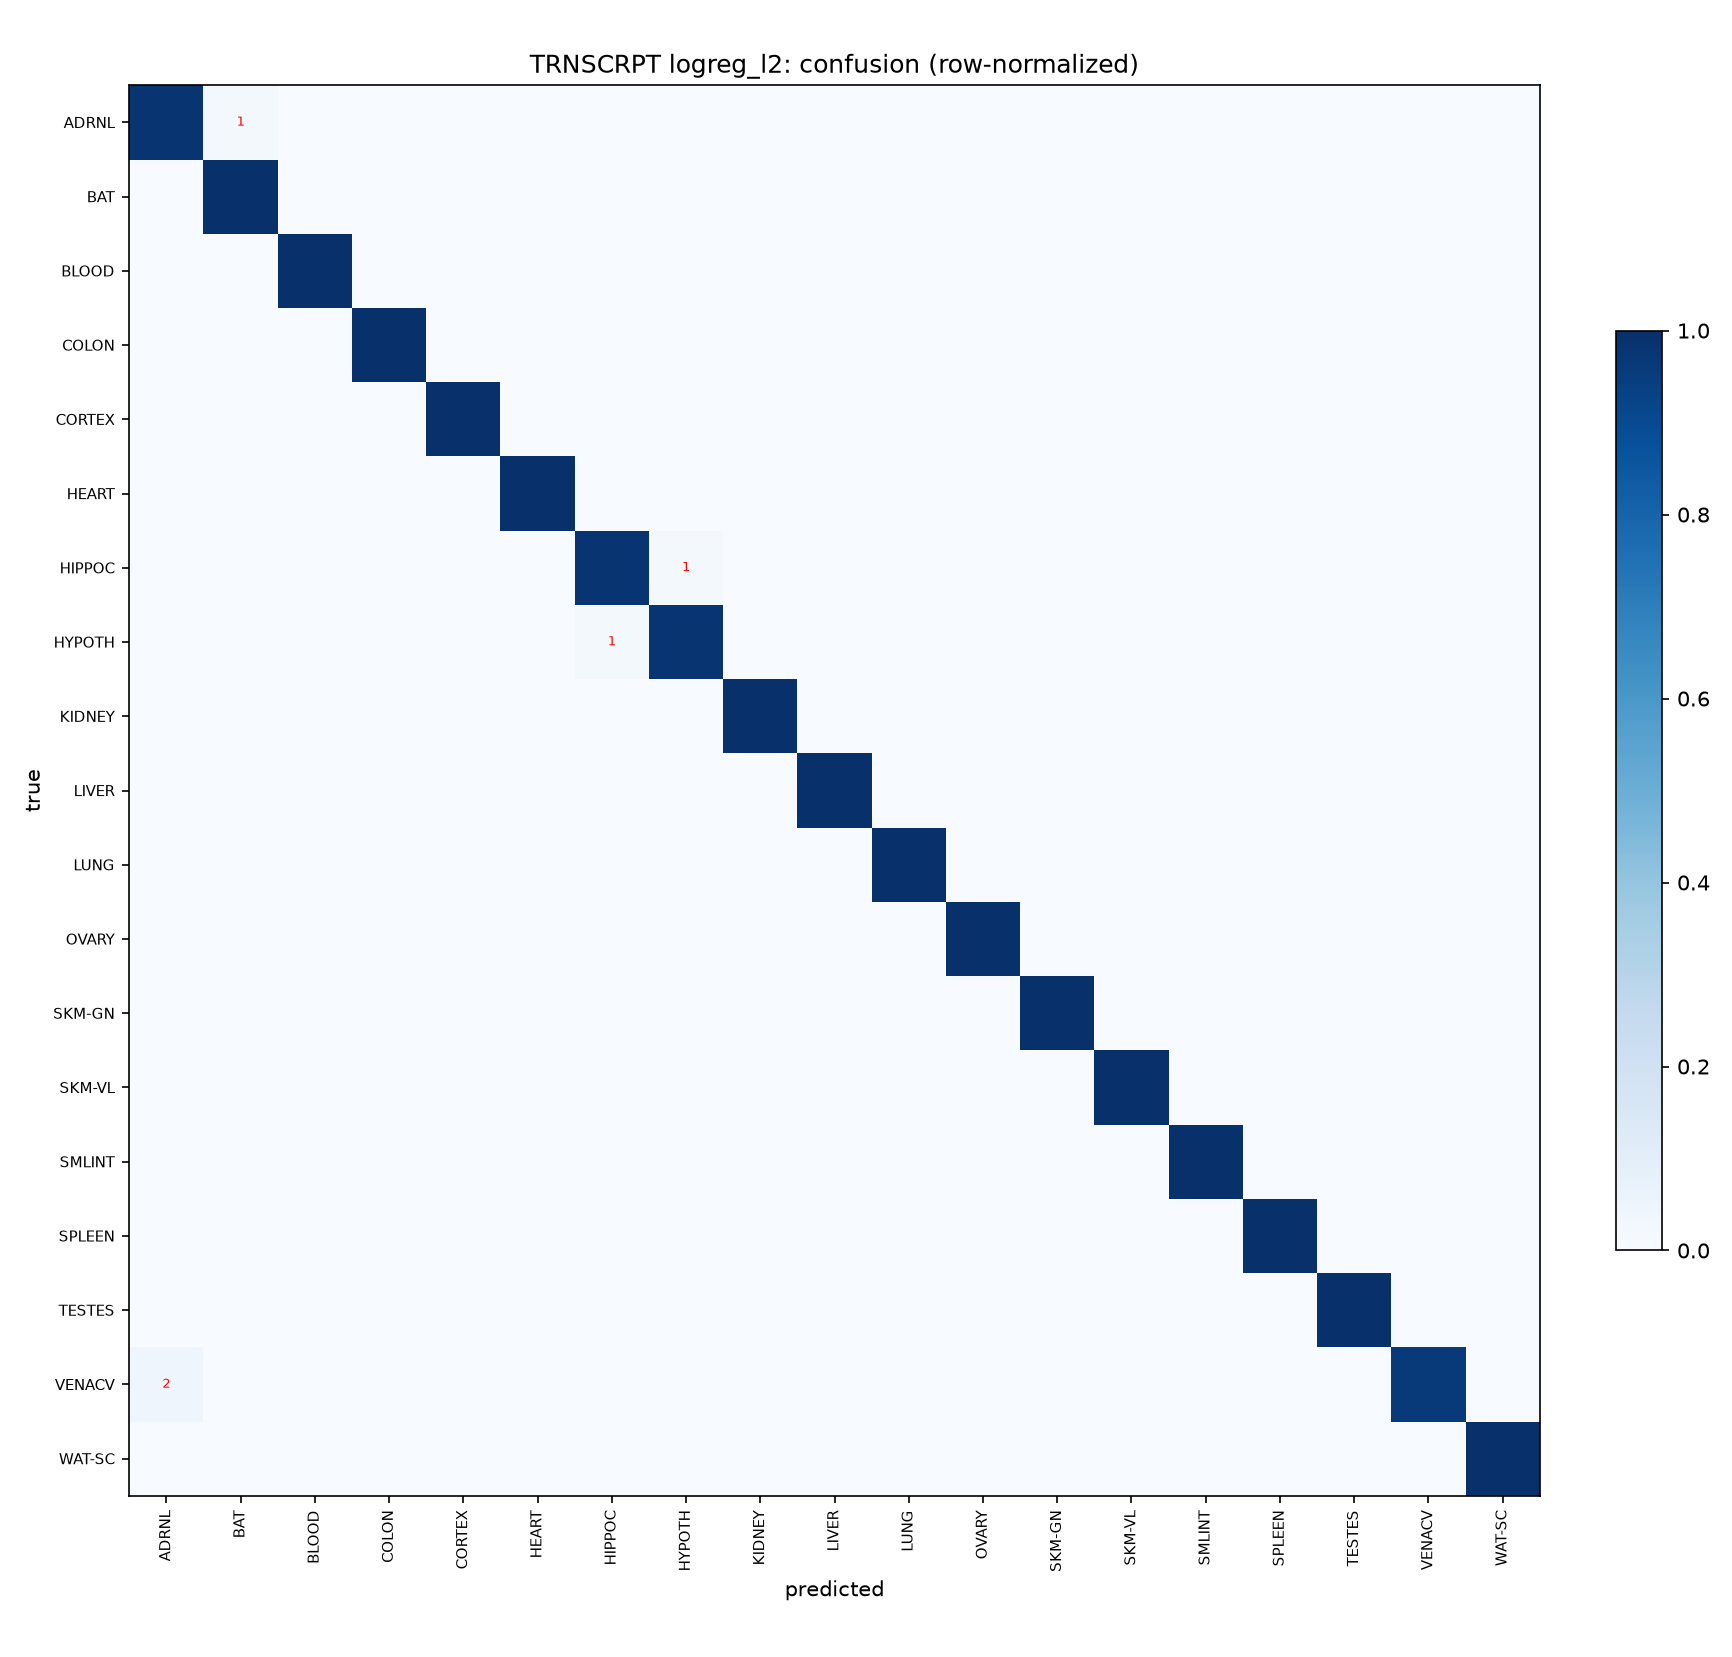

In [38]:
# from scripts/04_fingerprint_baselines.py::confusable_pairs (verbatim)
def confusable_pairs(conf: pd.DataFrame, top: int = 10) -> pd.DataFrame:
    rows = []
    for a in conf.index:
        for b in conf.columns:
            if a != b and conf.loc[a, b] > 0:
                rows.append({"true": a, "predicted": b, "count": int(conf.loc[a, b]),
                             "frac_of_true": float(conf.loc[a, b] / max(conf.loc[a].sum(), 1))})
    cols = ["true", "predicted", "count", "frac_of_true"]
    df = pd.DataFrame(rows, columns=cols)  # keeps the header even when nothing is confused
    return df.sort_values("count", ascending=False).head(top)


# remaining confusions with all genes, per model (pooled over the 5 test folds), vs the published lists
for kind in S04_MODELS:
    conf = s04_conf[kind]
    live = confusable_pairs(conf).reset_index(drop=True)
    pubp = pd.read_csv(res("04_baselines", "TRNSCRPT", f"confusable_pairs_{kind}.csv"))  # top 10 pairs
    key = ["true", "predicted", "count"]
    same = live[key].sort_values(key).reset_index(drop=True).equals(pubp[key].sort_values(key).reset_index(drop=True))
    print(f"{kind} ({'recomputed' if kind in S04_LIVE else 'loaded'}): {int(live['count'].sum())} misclassified samples of {int(conf.to_numpy().sum())}; "
          f"confused pairs identical to published: {same}")
    if kind == "logreg_l2":
        display(live)
        record("s04.n_errors_logreg_l2", int(live["count"].sum()), "04")
show_png(plots.confusion_heatmap(s04_conf["logreg_l2"],
                                 "TRNSCRPT logreg_l2: confusion (row-normalized)", OUT / "s04" / "confusion_logreg_l2.png"),
         width=600)

**What this shows.** All three tuned baselines separate the 19 tissues almost perfectly under
animal-grouped cross-validation, and the recomputed numbers match the published ones (the `diff`
column; the `source` column says which rows were fitted in this run and which were loaded). The fold-to-fold spread is the same size as the gaps between models, so the three are
effectively tied; the L2 logistic regression is the reference later sections must beat. The few
errors that remain are mostly between tissues that are anatomically adjacent or similar (listed above).

**What it does not show.** High accuracy here is not evidence of a biological "fingerprint" in any
strong sense: tissue is confounded with processing batch, and the test animals come from the same
cohorts, lab and pipeline as the training animals. It says nothing about transfer to another lab,
another library chemistry, or trained animals held out as a group (sections 8–10). The gene filter
(≥ 10 counts in ≥ 20 % of one tissue's samples) is applied to the full matrix before splitting — a
known deviation, reproduced here as the pipeline ran it. That filter sees the tissue labels of the
test samples too, so any bias it adds is optimistic; the variance prefilter and all tuning are inside the folds.

## 5. Compact panels: how few genes identify a tissue?

**Question.** If the classifier may use only *k* genes, chosen inside each training fold, how does
accuracy grow with *k*? And does *how* the genes are chosen matter?

**Why it matters.** A small panel is what a hackathon project could actually explain, transfer to
another dataset (sections 9–10) or certify (section 6). The selector is the design choice that
matters most: the obvious one, `SelectKBest(f_classif)`, ranks genes by a single multiclass F-score.
The pipeline's round-robin selector instead ranks genes per tissue (one-vs-rest effect size) and takes
the best remaining gene of each tissue in turn.

**What to look for.** (1) The two selectors at k = 20 on the same folds. (2) Where the round-robin
curve flattens. (3) Which tissues are still confused at k = 20 — derived from the predictions, not
typed in. (4) Whether the genes chosen are stable across animal bootstraps, and what risk flags they
carry.

Design (Makefile target `panels`, TRNSCRPT line): classifier `logreg_l2` on the *k* selected genes,
the same 5 animal-grouped folds as section 4, variance prefilter 5,000 → scaling → selector, all inside
each fold; `--compare-selectors --stability-k 20`, 50 animal bootstraps for stability.
**Default mode** runs a reduced grid live (k = 5, 10, 20, 50 round-robin; k = 20 F-test) and loads
the full published grid for the figure; `RECOMPUTE=True` runs the full grid for both selectors.

In [39]:
section("5 panels")
om = S04_OM                                   # the TRNSCRPT matrix loaded in section 4 (same cached object)
S05_OUT = OUT / "s05"
S05_OUT.mkdir(parents=True, exist_ok=True)
S05_GRID_FULL = C.PANEL_GRID                  # --grid default
S05_GRID = S05_GRID_FULL if RECOMPUTE else [5, 10, 20, 50]
S05_FC_GRID = S05_GRID_FULL if RECOMPUTE else [20]

# from scripts/05_compact_panels.py::main (trimmed: argparse defaults inlined — --model logreg_l2,
# --selector roundrobin, n_splits 5, prefilter 5000; grid reduced in default mode; no REPORT.md)
s05_curve, s05_selected, s05_preds = models.panel_curve(
    om, label="tissue", grid=S05_GRID, kind="logreg_l2", n_splits=5, prefilter=5000, quick=False,
    seed=C.SEED, selector="roundrobin", return_predictions=True, verbose=False)
# --compare-selectors: the same folds and classifier, F-test selector
s05_curve_fc, _ = models.panel_curve(om, label="tissue", grid=S05_FC_GRID, kind="logreg_l2", n_splits=5,
                                     prefilter=5000, quick=False, seed=C.SEED, selector="fclassif", verbose=False)
s05_curve.to_csv(S05_OUT / "panel_curve.csv", index=False)
s05_curve_fc.to_csv(S05_OUT / "panel_curve_fclassif.csv", index=False)

# recomputed vs published, per k and selector (mean balanced accuracy over the 5 folds)
pub_rr = pd.read_csv(res("05_panels", "TRNSCRPT", "panel_curve.csv"))
pub_fc = pd.read_csv(res("05_panels", "TRNSCRPT", "panel_curve_fclassif.csv"))
agg = lambda d: d.groupby("k")["balanced_accuracy"].agg(["mean", "std"])
s05_cmp = pd.concat({
    ("roundrobin", "recomputed"): agg(s05_curve)["mean"], ("roundrobin", "published"): agg(pub_rr)["mean"],
    ("roundrobin", "published_sd"): agg(pub_rr)["std"],
    ("fclassif", "recomputed"): agg(s05_curve_fc)["mean"], ("fclassif", "published"): agg(pub_fc)["mean"],
}, axis=1).sort_index()
display(s05_cmp.round(3))
rr20, fc20 = agg(s05_curve).loc[20, "mean"], agg(s05_curve_fc).loc[20, "mean"]
print(f"k = 20: round-robin {rr20:.3f} vs F-test {fc20:.3f} (published {agg(pub_rr).loc[20, 'mean']:.3f} vs {agg(pub_fc).loc[20, 'mean']:.3f})")
record("s05.bal_acc_rr_k20", rr20, "05")
record("s05.bal_acc_fclassif_k20", fc20, "05")
record("s05.bal_acc_rr_k50", agg(s05_curve).loc[50, "mean"], "05")
record("s05.bal_acc_rr_k10", agg(s05_curve).loc[10, "mean"], "05")

# how many different tissues do the 20 F-test genes of fold 0 "belong to"? (their top one-vs-rest tissue)
# — the mechanism behind the gap. Recomputed on fold 0's training data, the same steps as the pipeline.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
tr0 = S04_FOLDS[0][0]
X0 = om.X.to_numpy(dtype=float)[tr0]
y0 = om.meta["tissue"].astype(str).to_numpy()[tr0]
Z0 = StandardScaler().fit_transform(models.VarianceTopK(5000).fit_transform(SimpleImputer(strategy="median").fit_transform(X0)))
fc_sel = models.make_selector("fclassif", 20).fit(Z0, y0)
rr_sel = models.make_selector("roundrobin", 20).fit(Z0, y0)
owner = rr_sel.scores_.argmax(axis=0)          # tissue with the largest one-vs-rest score, per gene
for name, idx in (("F-test", np.flatnonzero(fc_sel.get_support())), ("round-robin", rr_sel.idx_)):
    tissues_hit = pd.Series(rr_sel.classes_[owner[idx]]).value_counts()
    print(f"fold 0, {name:11s}: 20 genes are top markers of {tissues_hit.size} of {len(rr_sel.classes_)} tissues; "
          f"most common: {tissues_hit.index[0]} ({tissues_hit.iloc[0]} genes)")

roundrobin                          fclassif          
    recomputed published published_sd recomputed published
k                                                         
1          NaN     0.202        0.011        NaN     0.106
2          NaN     0.346        0.028        NaN     0.111
3          NaN     0.495        0.059        NaN     0.117
5        0.661     0.661        0.041        NaN     0.121
8          NaN     0.744        0.051        NaN     0.132
10       0.814     0.814        0.032        NaN     0.133
15         NaN     0.975        0.014        NaN     0.282
20       0.976     0.976        0.008      0.399     0.399
30         NaN     0.981        0.010        NaN     0.716
50       0.993     0.993        0.003        NaN     0.837
100        NaN     0.993        0.003        NaN     0.924

k = 20: round-robin 0.976 vs F-test 0.399 (published 0.976 vs 0.399)


fold 0, F-test     : 20 genes are top markers of 3 of 19 tissues; most common: TESTES (18 genes)
fold 0, round-robin: 20 genes are top markers of 17 of 19 tissues; most common: ADRNL (2 genes)


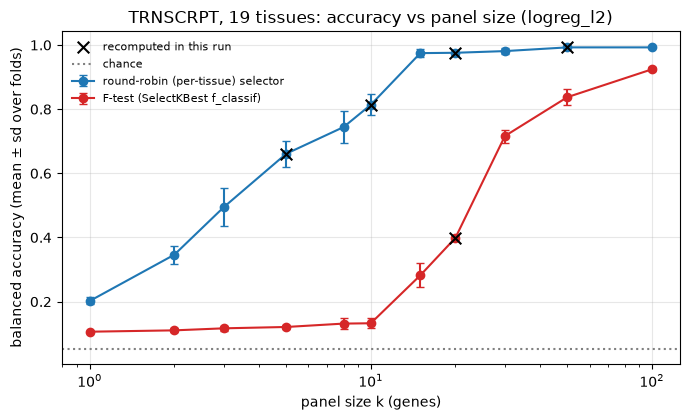

smallest k with mean balanced accuracy >= 0.99 (round-robin, point estimate): 50


In [40]:
# The figure: the full published grid (default) or this run's full grid (RECOMPUTE), both selectors.
full_rr, full_fc = (s05_curve, s05_curve_fc) if RECOMPUTE else (pub_rr, pub_fc)
fig, ax = plt.subplots(figsize=(7, 4.3))
for d, lab, c in ((full_rr, "round-robin (per-tissue) selector", "C0"), (full_fc, "F-test (SelectKBest f_classif)", "C3")):
    a = agg(d)
    ax.errorbar(a.index, a["mean"], yerr=a["std"].fillna(0), marker="o", capsize=3, color=c, label=lab)
if not RECOMPUTE:   # overlay this run's live points on the published curves
    ax.scatter(agg(s05_curve).index, agg(s05_curve)["mean"], marker="x", s=70, color="k", zorder=5, label="recomputed in this run")
    ax.scatter(agg(s05_curve_fc).index, agg(s05_curve_fc)["mean"], marker="x", s=70, color="k", zorder=5)
ax.axhline(1 / om.meta["tissue"].nunique(), color="grey", ls=":", label="chance")
ax.set_xscale("log"); ax.set_xlabel("panel size k (genes)"); ax.set_ylabel("balanced accuracy (mean ± sd over folds)")
ax.set_title("TRNSCRPT, 19 tissues: accuracy vs panel size (logreg_l2)"); ax.grid(alpha=0.3); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(S05_OUT / "panel_curve_both_selectors.png", dpi=120); plt.show()
k99 = agg(full_rr).query("mean >= 0.99").index.min()
print("smallest k with mean balanced accuracy >= 0.99 (round-robin, point estimate):", k99)
record("s05.smallest_k_bal_acc_ge_099", k99, "05")

**What this shows.** With the round-robin selector a panel of a couple of dozen genes already comes
close to the all-gene baseline of section 4, and the curve is flat from there on. With the F-test
selector the same 20 genes fail badly: the fold-0 diagnosis above shows why — the top F-scores
concentrate on a few tissues with huge, easy markers, leaving most tissues without a gene of their own.
The live points sit on the published curve.

**What it does not show.** These are point estimates over 5 folds of 10 test animals each; the sd bars
are fold-to-fold spread, not a guarantee. Which *k* is enough with a stated error rate is section 6's
job (conformal certification). And "smallest k ≥ 0.99" depends on the grid points that were tried.

confusion matrix at k = 20 identical to published confusion_k20.csv: True
23 errors of 899 test samples (pooled over folds); top confused pairs:


,k,true,predicted,count,frac_of_true
0,20,VENACV,BAT,12,0.24
1,20,SKM-VL,SKM-GN,5,0.10
2,20,SKM-GN,SKM-VL,2,0.04
3,20,ADRNL,BAT,1,0.02
4,20,BAT,VENACV,1,0.02
5,20,HIPPOC,HYPOTH,1,0.02
6,20,HYPOTH,HIPPOC,1,0.02


largest single error: VENACV -> BAT: 12 samples (24% of all VENACV samples; 52% of all errors)


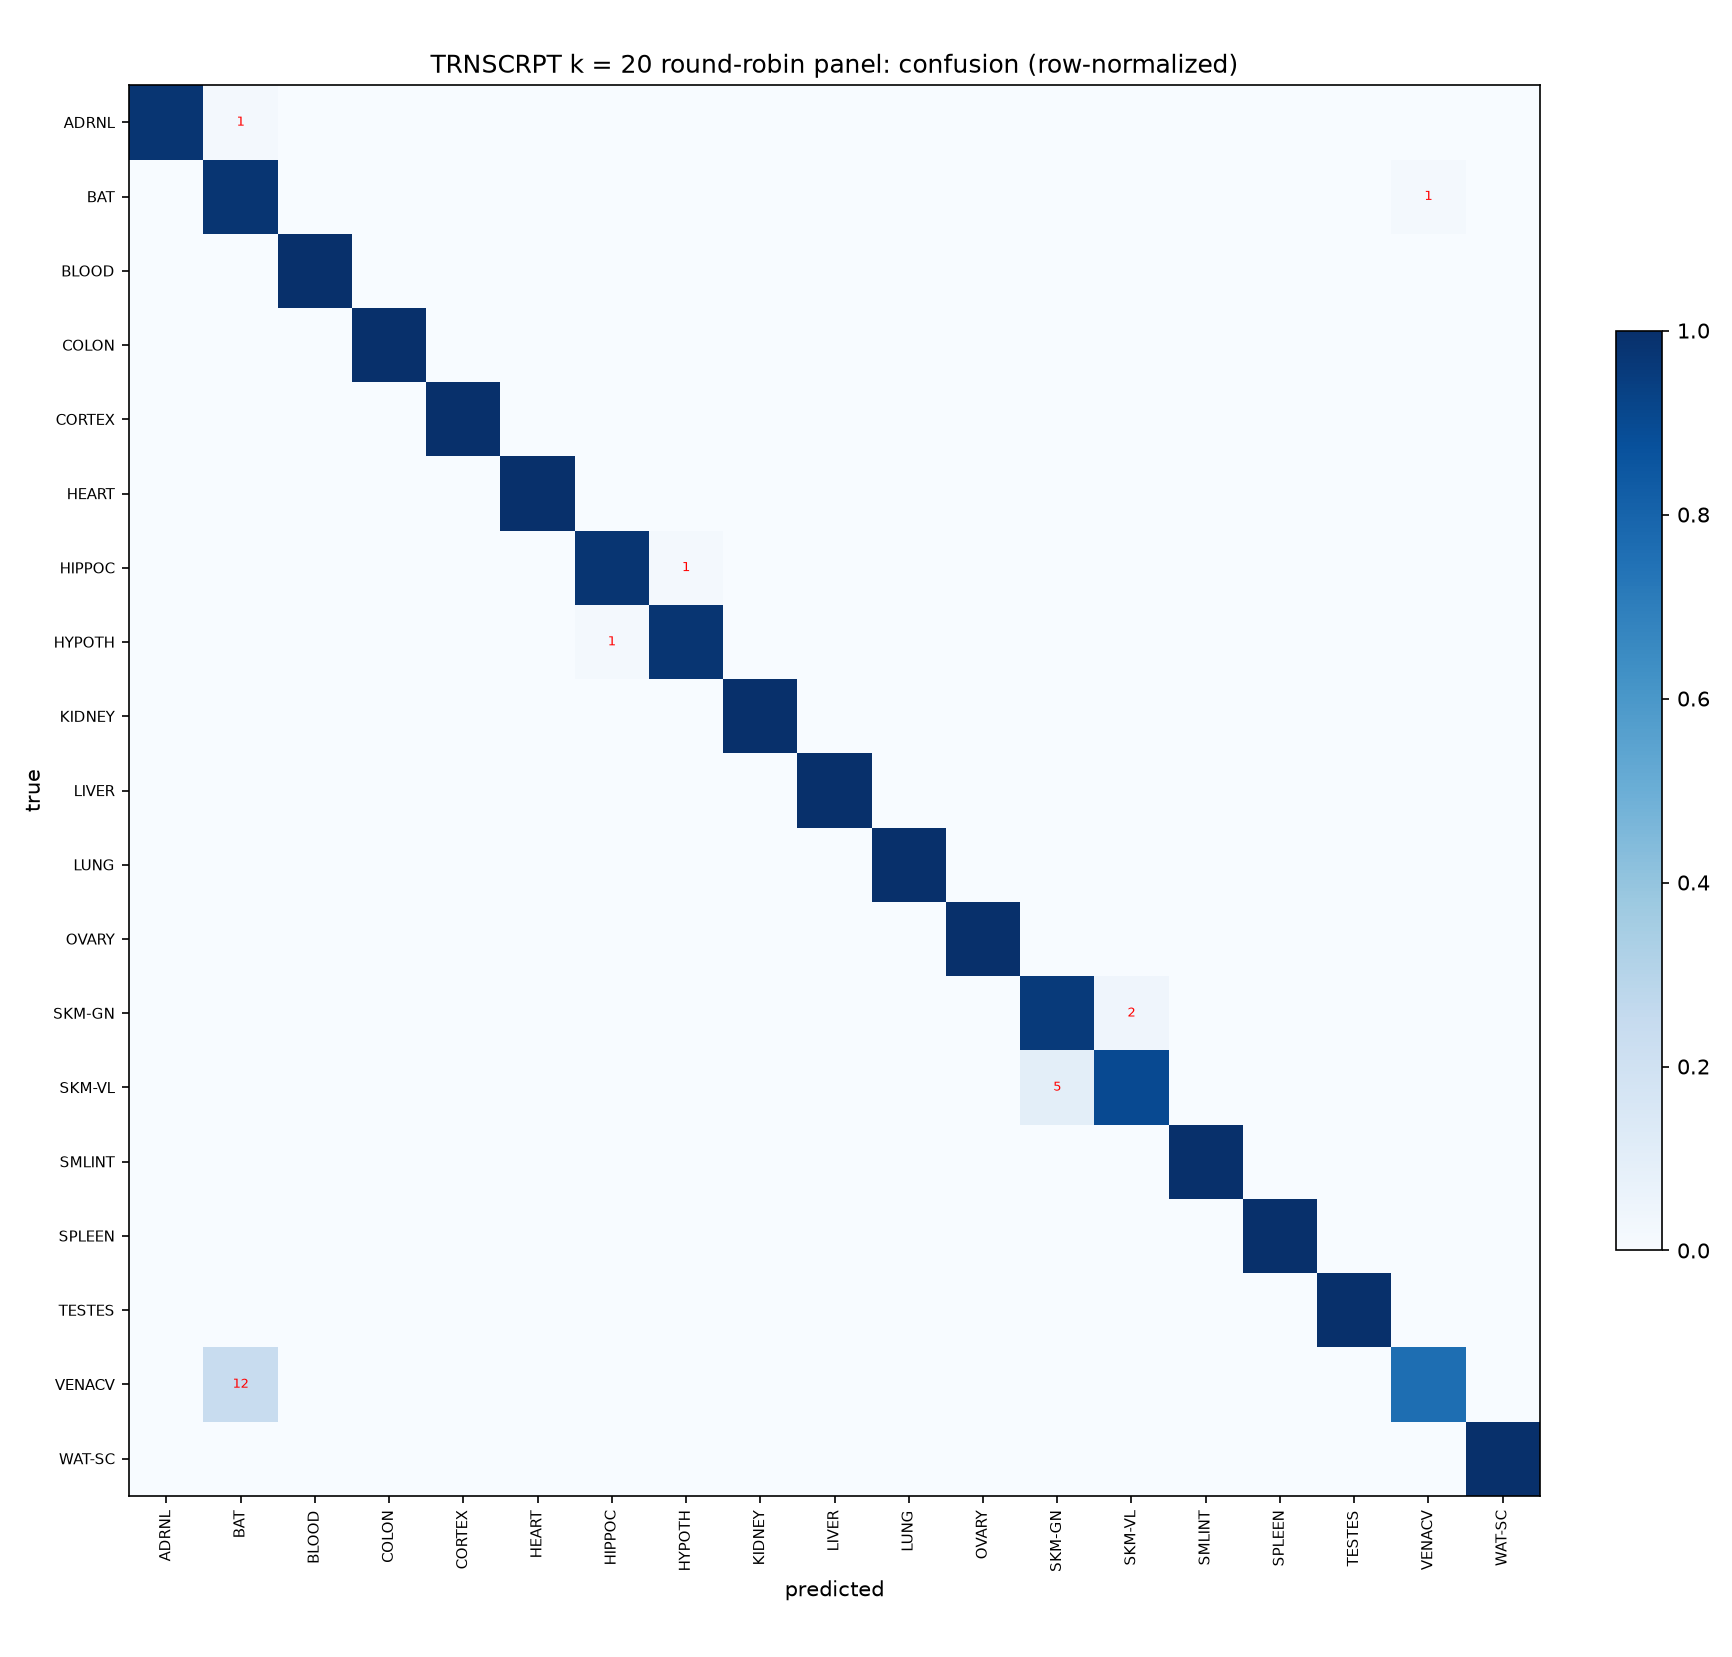

In [41]:
# Confusion at k = 20, from this run's pooled out-of-fold predictions
# from scripts/05_compact_panels.py::main (verbatim confusion block, --confusion-k 20 only)
classes = sorted(om.meta["tissue"].astype(str).unique())
pk = s05_preds[s05_preds["k"] == 20]
s05_conf20 = pd.crosstab(pk["y_true"], pk["y_pred"]).reindex(index=classes, columns=classes, fill_value=0)
s05_conf20.to_csv(S05_OUT / "confusion_k20.csv")
rows = [{"k": 20, "true": a, "predicted": b, "count": int(s05_conf20.loc[a, b]),
         "frac_of_true": float(s05_conf20.loc[a, b] / max(s05_conf20.loc[a].sum(), 1))}
        for a in classes for b in classes if a != b and s05_conf20.loc[a, b] > 0]
s05_pairs20 = pd.DataFrame(rows, columns=["k", "true", "predicted", "count", "frac_of_true"]).sort_values("count", ascending=False)

pub_conf20 = pd.read_csv(res("05_panels", "TRNSCRPT", "confusion_k20.csv"), index_col=0)
print("confusion matrix at k = 20 identical to published confusion_k20.csv:",
      s05_conf20.equals(pub_conf20.reindex(index=classes, columns=classes)))
n_err = int(s05_pairs20["count"].sum())
print(f"{n_err} errors of {len(pk)} test samples (pooled over folds); top confused pairs:")
display(s05_pairs20.head(8).reset_index(drop=True).round(2))
top = s05_pairs20.iloc[0]
share = top["count"] / n_err
print(f"largest single error: {top['true']} -> {top['predicted']}: {top['count']} samples "
      f"({top['frac_of_true']:.0%} of all {top['true']} samples; {share:.0%} of all errors)")
record("s05.n_errors_k20", n_err, "05")
record("s05.top_error_count_k20", top["count"], "05", f"{top['true']}->{top['predicted']}")
show_png(plots.confusion_heatmap(s05_conf20, "TRNSCRPT k = 20 round-robin panel: confusion (row-normalized)",
                                 S05_OUT / "confusion_k20.png"), width=600)

**What this shows.** At k = 20 the errors are few and concentrated: the table is sorted by count, so
its first rows are the pairs that dominate. The largest one sends vena cava samples to brown adipose
tissue — consistent with the brown-fat contamination of some vena cava vials that the consortium
flagged as outliers (see docs/DATA_GUIDE.md §6; many of those vials remain in the shipped matrices).
Most of the rest are between the two skeletal muscles and the two brain regions, which are genuinely similar.

**What it does not show.** This is one set of 5 folds; with 10 test animals per fold, a single
contaminated animal moves several counts. Whether the vena-cava errors are exactly the flagged vials
is not checked here.

### 5b. Is the panel stable, and what is in it?

Stability selection refits the selection step (impute → prefilter → scale → round-robin, k = 20) on 50
bootstrap resamples of *animals* and counts how often each gene is chosen. Genes chosen in at least
80 % of resamples form the candidate panel. Each is then annotated (script `05_annotate_panel.py`):
its marker tissue, effect size, whether it is training-regulated in that tissue (a risk for the
controls → trained shift, section 8) and whether it correlates with a library QC metric (`pct_mrna`)
within its tissue (a risk for transfer to another library chemistry). Flags are annotation, not
exclusion.

In [42]:
if RECOMPUTE:
    # from scripts/05_compact_panels.py::main (verbatim call; --stability-k 20, --n-boot 50 default)
    s05_stab = models.stability_selection(om, label="tissue", k=20, n_boot=50, prefilter=5000,
                                          seed=C.SEED, selector="roundrobin")
    s05_stab.to_csv(S05_OUT / "stability_k20.csv", index=False)
else:
    s05_stab = pd.read_csv(res("05_panels", "TRNSCRPT", "stability_k20.csv"), dtype={"feature_ID": str})
s05_stab["gene_symbol"] = io.map_to_gene_symbols(s05_stab["feature_ID"]).values
s05_panel = s05_stab[s05_stab["selection_frequency"] >= 0.8].reset_index(drop=True)   # candidate_panel.csv
pub_panel = pd.read_csv(res("05_panels", "TRNSCRPT", "candidate_panel.csv"), dtype={"feature_ID": str})
print(f"{len(s05_stab)} genes selected at least once in the bootstraps; {len(s05_panel)} in >= 80 % "
      f"(published candidate panel: {len(pub_panel)}; same genes: {set(s05_panel['feature_ID']) == set(pub_panel['feature_ID'])})")
record("s05.n_candidate_panel", len(s05_panel), "05")

51 genes selected at least once in the bootstraps; 10 in >= 80 % (published candidate panel: 10; same genes: True)


In [43]:
# from scripts/05_annotate_panel.py::main (trimmed: argparse defaults inlined — qc_col pct_mrna,
# qc_risk 0.5, label tissue; panel = the candidate panel above; no REPORT.md). Annotation only.
qc_col, qc_risk = "pct_mrna", 0.5
panel = s05_panel.drop_duplicates("feature_ID").reset_index(drop=True)
y = om.meta["tissue"].astype(str).to_numpy()
classes = sorted(np.unique(y))
ids = [f for f in panel["feature_ID"] if f in om.X.columns]
full = SimpleImputer(strategy="median").fit_transform(om.X.to_numpy(dtype=float))   # full matrix: annotation only
sel = models.RoundRobinSelector(k=len(ids)).fit(full, y)
scores = sel.scores_
col = {f: j for j, f in enumerate(om.X.columns)}
rank_pos = {i: {j: r + 1 for r, j in enumerate(np.argsort(-scores[i]))} for i in range(len(classes))}
top_full = set(np.asarray(om.X.columns)[sel.idx_])
mu = om.X[ids].groupby(y).mean()
reg = pd.read_csv(C.RAW_DIR / "training_regulated_features.csv", dtype=str, usecols=["feature_ID", "assay", "tissue"])
reg_map = reg[reg["assay"] == "TRNSCRPT"].groupby("feature_ID")["tissue"].agg(lambda s: sorted(set(s))).to_dict()
m = pd.read_csv(C.META_DIR / "TRNSCRPT.csv", dtype=str, low_memory=False)
qc = pd.to_numeric(m.drop_duplicates("viallabel").set_index("viallabel")[qc_col], errors="coerce").reindex(om.X.index)
symbols = io.map_to_gene_symbols(ids)
rows = []
for f in ids:
    j = col[f]; sc = scores[:, j]; order = np.argsort(-sc)
    i1, i2 = int(order[0]), int(order[1])
    t1 = classes[i1]; means = mu[f]; others = means.drop(t1); x = om.X[f]
    r_in, r_max, t_max = np.nan, np.nan, None
    for t in classes:
        mk = (y == t) & x.notna().to_numpy() & qc.notna().to_numpy()
        if mk.sum() >= 8 and x[mk].std() > 0 and qc[mk].std() > 0:
            r = float(np.corrcoef(x[mk], qc[mk])[0, 1])
            if t == t1:
                r_in = r
            if np.isnan(r_max) or abs(r) > abs(r_max):
                r_max, t_max = r, t
    reg_t = reg_map.get(f, [])
    rows.append({"feature_ID": f, "gene_symbol": symbols.get(f),
                 "selection_frequency": panel.set_index("feature_ID").loc[f, "selection_frequency"],
                 "marker_tissue": t1, "ovr_score": float(sc[i1]), "rank_in_tissue": int(rank_pos[i1][j]),
                 "runner_up_tissue": classes[i2], "runner_up_score": float(sc[i2]),
                 "in_full_data_roundrobin_top_k": f in top_full, "mean_in_marker_tissue": float(means[t1]),
                 "next_highest_tissue": str(others.idxmax()), "next_highest_mean": float(others.max()),
                 "effect_size": float(means[t1] - others.max()),
                 "regulated_in_marker_tissue": t1 in reg_t, "regulated_tissues": ";".join(reg_t),
                 f"r_{qc_col}_in_marker_tissue": r_in, f"max_abs_r_{qc_col}": r_max, "tissue_of_max_r": t_max,
                 "risk_T7_regulated": t1 in reg_t, "risk_qc_correlated": bool(not np.isnan(r_in) and abs(r_in) >= qc_risk)})
s05_ann = pd.DataFrame(rows).sort_values(["marker_tissue", "ovr_score"], ascending=[True, False]).reset_index(drop=True)
s05_ann.to_csv(S05_OUT / "candidate_panel_annotated.csv", index=False)

show = ["gene_symbol", "selection_frequency", "marker_tissue", "rank_in_tissue", "effect_size", "next_highest_tissue",
        "regulated_tissues", f"r_{qc_col}_in_marker_tissue", "risk_T7_regulated", "risk_qc_correlated"]
display(s05_ann[show].round(2))
pub_ann = pd.read_csv(res("05_panels", "TRNSCRPT", "candidate_panel_annotated.csv"), dtype={"feature_ID": str})
num = ["ovr_score", "effect_size", f"r_{qc_col}_in_marker_tissue"]
a, b = s05_ann.set_index("feature_ID"), pub_ann.set_index("feature_ID").reindex(s05_ann["feature_ID"])
print("annotation vs published: marker tissues identical:", (a["marker_tissue"] == b["marker_tissue"]).all(),
      "| max |diff| in", num, "=", f"{np.nanmax(np.abs(a[num].to_numpy() - b[num].to_numpy())):.2e}")
uncovered = [c for c in classes if c not in set(s05_ann["marker_tissue"])]
print(f"tissues with a stable marker: {s05_ann['marker_tissue'].nunique()} of {len(classes)}; without: {', '.join(uncovered)}")
print(f"flags: training-regulated in marker tissue {int(s05_ann['risk_T7_regulated'].sum())}, "
      f"|r| >= {qc_risk} with {qc_col} in marker tissue {int(s05_ann['risk_qc_correlated'].sum())}")
record("s05.n_panel_tissues_covered", s05_ann["marker_tissue"].nunique(), "05")
record("s05.n_flag_regulated", int(s05_ann["risk_T7_regulated"].sum()), "05")
record("s05.n_flag_qc", int(s05_ann["risk_qc_correlated"].sum()), "05")

,gene_symbol,selection_frequency,marker_tissue,rank_in_tissue,effect_size,next_highest_tissue,regulated_tissues,r_pct_mrna_in_marker_tissue,risk_T7_regulated,risk_qc_correlated
0,Cyp21a1,1.00,ADRNL,1,11.56,VENACV,,-0.80,False,True
1,Gabrd,0.88,CORTEX,6,1.33,HIPPOC,,0.17,False,False
2,Lrrc10,0.94,HEART,6,2.90,VENACV,LUNG,0.06,False,False
3,Fibcd1l1,1.00,HIPPOC,3,3.59,CORTEX,,-0.01,False,False
4,Pmch,0.96,HYPOTH,1,8.17,CORTEX,,0.03,False,False
5,Umod,1.00,KIDNEY,1,11.79,TESTES,,-0.43,False,False
6,Cldn18,0.94,LUNG,1,8.55,TESTES,,0.34,False,False
7,Akr1c3,1.00,OVARY,2,8.23,WAT-SC,OVARY,-0.06,True,False
8,Ccl25,1.00,SMLINT,2,6.57,COLON,SMLINT,0.25,True,False
9,Fcrl5,0.90,SPLEEN,10,5.42,BLOOD,WAT-SC,-0.52,False,True


annotation vs published: marker tissues identical: True | max |diff| in ['ovr_score', 'effect_size', 'r_pct_mrna_in_marker_tissue'] = 1.78e-15
tissues with a stable marker: 10 of 19; without: BAT, BLOOD, COLON, LIVER, SKM-GN, SKM-VL, TESTES, VENACV, WAT-SC
flags: training-regulated in marker tissue 2, |r| >= 0.5 with pct_mrna in marker tissue 2


**What this shows.** Only part of the k = 20 selection is stable across animal bootstraps: the stable
genes are textbook tissue markers (adrenal steroidogenesis, kidney uromodulin, lung claudin, the
hypothalamic neuropeptide, and so on), most with a large effect size. The other chosen genes rotate
between near-equivalent candidates, which is why accuracy is stable even though the gene list is not.
Many tissues have no stable marker of their own (printed above). A few stable genes carry a flag:
training-regulated in their own tissue, or correlated with library mRNA content.

**What it does not show.** The one-vs-rest scores, means and QC correlations in the annotation are
computed on the full matrix — they describe the panel, they are not an evaluation. A flag is a risk,
not a demonstrated failure: whether a flagged gene actually breaks under the controls → trained shift
or in another dataset is tested in sections 8–10. Stability selection here uses one seed and 50
resamples, so frequencies near the threshold are uncertain.

## 6. Conformal prediction sets: does "90 % coverage" hold on new animals?

**Question.** A split-conformal wrapper turns the tissue classifier into a *set*-valued predictor with
a promise: on new animals, the true tissue is in the set with probability at least 1 − α. Does that
promise hold here, marginally (over all vials) and per tissue? Two scores are compared: **LAC**
(the set holds every class with p̂ ≥ 1 − q̂; smallest sets, can be empty) and **APS** (classes are
added in order of p̂ until the cumulative mass passes q̂; never empty, larger sets). Two
calibrations use the *same* calibration animals: **pooled** (every vial of the 22 calibration
animals) and **one vial per animal** (22 points, exchangeable by construction). On the pooled
calibration two class-conditional variants are added: **Mondrian** (one quantile per tissue) and
**floored Mondrian** (each tissue's quantile never below the marginal one).

**Why it matters.** Coverage is the number a user of a tissue-ID tool would rely on; a marginal
guarantee can hold while one tissue is almost never covered.

**What to look for.** Marginal LAC coverage close to 1 − α; APS well above it (over-coverage) with
sets a little larger than one class; per-tissue coverage far below 1 − α for the confusable tissues
under marginal calibration, restored by Mondrian at the price of larger sets for those tissues.

The settings are those of the pipeline's `make conformal` (first command): 5 outer animal-grouped
folds, 22 calibration animals taken from each training fold, L2 logistic regression tuned on the
remaining fit animals, α ∈ {0.05, 0.10, 0.20}. Only the conformal-set leg is run here (it is cheap);
the 100-split certificate is section 7.

**Note on the quantile.** On 2026-09-25 the library's `conformal_quantile` was changed to the
textbook rule (the ⌈(n+1)(1−α)⌉-th smallest score, and an infinite threshold — the full set — when
that rank exceeds n). The library pasted above is the fixed one; the cells below also print the
pipeline's pre-fix numbers so the effect of the fix is visible.

In [44]:
section("6 conformal sets")

# -- the data: the same stacked TRNSCRPT matrix phases 04, 06 and 08 use (shared cache key) --
# from src/tfp/cli.py::resolve_source (verbatim)
def resolve_source(assay: str, source: str) -> str:
    if source != "auto":
        return source
    if assay == "TRNSCRPT" and any((C.COUNTS_DIR).glob(f"{assay}__*.csv")):
        return "counts"
    return "norm"


pheno = cached("pheno", io.load_pheno)
om_trn = cached("TRNSCRPT_counts", lambda: io.stack_tissues(
    "TRNSCRPT", tissues=None, source=resolve_source("TRNSCRPT", "auto"), join="inner", pheno=pheno,
    complete=False, drop_incomplete_samples=None))

# -- the flags of `make conformal` (first command) --
s06_args = SimpleNamespace(label="tissue", model="logreg_l2", n_splits=5, prefilter=5000, seed=C.SEED, quick=False,
                           cal_frac=0.3, cal_animals=22, conditional=True)
X = om_trn.X.to_numpy(dtype=float)
y = om_trn.meta[s06_args.label].astype(str).to_numpy()
classes = sorted(np.unique(y))
y_idx = np.array([classes.index(v) for v in y])
g = om_trn.groups()
print(f"{X.shape[0]} vials × {X.shape[1]} genes, {len(np.unique(g))} animals, {len(classes)} tissues")


# from scripts/06_conformal_certify.py::proba_on (verbatim)
def proba_on(est, X, classes):
    p = est.predict_proba(X)
    order = [list(est.classes_).index(c) for c in classes]
    return p[:, order]


# from scripts/06_conformal_certify.py::split_train (verbatim)
def split_train(meta, tr, cal_frac, cal_animals, seed):
    """(fit, calibration) by animal: an absolute number of calibration animals if given, else a fraction."""
    if cal_animals is None:
        return fit_calibration_split(meta, tr, cal_frac, seed)
    tr = np.asarray(tr)
    rng = np.random.default_rng(seed)
    pids = meta.iloc[tr]["pid"].astype(str).to_numpy()
    uniq = np.unique(pids)
    rng.shuffle(uniq)
    n_cal = min(max(1, int(cal_animals)), len(uniq) - 1)
    cal = set(uniq[:n_cal])
    is_cal = np.array([p in cal for p in pids])
    fit_idx, cal_idx = tr[~is_cal], tr[is_cal]
    assert_no_group_leak(meta, fit_idx, cal_idx)
    return fit_idx, cal_idx

899 vials × 21193 genes, 50 animals, 19 tissues


In [45]:
# from scripts/06_conformal_certify.py::main, the fold loop, conformal-set leg (a) only
# (trimmed: the repeat loop runs only rep == 0, which is the only repeat that computes sets;
#  the certificate leg (b) is section 7; `args.` → `s06_args.`)
t0 = time.perf_counter()
cov_rows, pc_rows = [], []
args = s06_args
for fold, (tr, te) in enumerate(grouped_kfold(om_trn.meta, args.label, args.n_splits, args.seed)):
    rep = 0
    seed_r = args.seed + 1000 * fold + rep
    fit_idx, cal_idx = split_train(om_trn.meta, tr, args.cal_frac, args.cal_animals, seed_r)
    cal_opa = cp.one_per_group(cal_idx, g, seed_r)          # one random vial per calibration animal
    # (a) full-feature model → conformal sets, calibrated pooled and one-per-animal on the same animals
    est = models.fit_tuned(args.model, X[fit_idx], y[fit_idx], g[fit_idx], k=None, prefilter=args.prefilter,
                           quick=args.quick, seed=args.seed)
    p_te = proba_on(est, X[te], classes)
    for mode, cidx in (("pooled", cal_idx), ("one_per_animal", cal_opa)):
        p_cal = proba_on(est, X[cidx], classes)
        for method in ("lac", "aps"):
            for alpha in C.ALPHAS:
                variants = [("marginal", False)] + ([("mondrian", True), ("floored", "floored")] if (args.conditional and mode == "pooled") else [])
                for cname, cond in variants:
                    r = cp.calibrate_and_evaluate(p_cal, y_idx[cidx], p_te, y_idx[te], classes, alpha, method,
                                                  extra_test=om_trn.meta.iloc[te][["sex", "group"]], conditional=cond)
                    cov_rows.append({"fold": fold, "calibration": mode, "conformal": cname, "method": method, "alpha": alpha,
                                     "qhat": r.qhat, "n_cal": r.n_cal, "n_cal_animals": int(om_trn.meta.iloc[cidx]["pid"].nunique()),
                                     "n_fit_animals": int(om_trn.meta.iloc[fit_idx]["pid"].nunique()),
                                     "n_test_animals": int(om_trn.meta.iloc[te]["pid"].nunique()), **r.overall})
                    pc_rows.append(r.per_class.assign(fold=fold, calibration=mode, conformal=cname, method=method, alpha=alpha))
    lac = [c for c in cov_rows if c["fold"] == fold and c["method"] == "lac" and c["alpha"] == 0.1 and c["conformal"] == "marginal"]
    print(f"  fold {fold}: {lac[0]['n_fit_animals']} fit / {lac[0]['n_cal_animals']} calibration / {lac[0]['n_test_animals']} test animals; "
          f"LAC α=0.1 coverage pooled={lac[0]['coverage']:.3f} one-per-animal={lac[1]['coverage']:.3f}")
del args
s06_cov = pd.DataFrame(cov_rows)
s06_pc = pd.concat(pc_rows, ignore_index=True)
(OUT / "s06").mkdir(parents=True, exist_ok=True)
s06_cov.to_csv(OUT / "s06" / "coverage.csv", index=False)
s06_pc.to_csv(OUT / "s06" / "per_class_coverage.csv", index=False)
print(f"conformal-set leg: {time.perf_counter() - t0:.0f} s")

  fold 0: 18 fit / 22 calibration / 10 test animals; LAC α=0.1 coverage pooled=0.916 one-per-animal=0.832


  fold 1: 18 fit / 22 calibration / 10 test animals; LAC α=0.1 coverage pooled=0.883 one-per-animal=0.983


  fold 2: 18 fit / 22 calibration / 10 test animals; LAC α=0.1 coverage pooled=0.878 one-per-animal=0.878


  fold 3: 18 fit / 22 calibration / 10 test animals; LAC α=0.1 coverage pooled=0.961 one-per-animal=0.917


  fold 4: 18 fit / 22 calibration / 10 test animals; LAC α=0.1 coverage pooled=0.900 one-per-animal=0.972
conformal-set leg: 12 s


### 6a. Marginal coverage and set size

The table below averages the five folds (the pipeline's own summary). Next to each recomputed value
it prints the pipeline's value from `results/06_conformal/TRNSCRPT/coverage.csv` (post-fix; same
seeds, so the two should agree to rounding) and the pre-fix value from the backup copy.

In [46]:
# from scripts/06_conformal_certify.py::main (verbatim: the cov_summary aggregation)
def s06_summary(cov):
    cov = cov[cov["conformal"] == "marginal"]
    return cov.groupby(["calibration", "method", "alpha"]).agg(
        coverage=("coverage", "mean"), coverage_sd=("coverage", "std"), avg_set_size=("avg_set_size", "mean"),
        frac_singleton=("frac_singleton", "mean"), frac_empty=("frac_empty", "mean"), n_cal=("n_cal", "mean")).reset_index()


S06_PRE = REPO / "backup" / "pipeline_history" / "results_pre_quantile_fix_2026-09-25" / "06_conformal" / "TRNSCRPT"
s06_pub = pd.read_csv(res("06_conformal", "TRNSCRPT", "coverage.csv"))     # post-fix pipeline run
s06_pre = pd.read_csv(S06_PRE / "coverage.csv")                              # pre-fix pipeline run
keys = ["calibration", "method", "alpha"]
s06_sum = s06_summary(s06_cov)
s06_cmp = (s06_sum[keys + ["coverage", "coverage_sd", "avg_set_size", "frac_empty", "n_cal"]]
           .merge(s06_summary(s06_pub)[keys + ["coverage", "avg_set_size"]].rename(columns=lambda c: c if c in keys else c + "_pub"), on=keys)
           .merge(s06_summary(s06_pre)[keys + ["coverage", "avg_set_size"]].rename(columns=lambda c: c if c in keys else c + "_prefix"), on=keys))
display(s06_cmp.round(3))
# the recomputation must match the post-fix pipeline run row by row (same folds, seeds and fits)
num = ["coverage", "avg_set_size", "qhat", "frac_empty"]
mrg = s06_cov.merge(s06_pub, on=["fold", "calibration", "conformal", "method", "alpha"], suffixes=("", "_pub"))
print(f"rows matched: {len(mrg)} of {len(s06_cov)}; max |recomputed − published| over coverage, set size, q̂, frac_empty: "
      f"{max(np.nanmax(np.abs(np.where(np.isinf(mrg[c]) & np.isinf(mrg[c + '_pub']), 0, mrg[c] - mrg[c + '_pub']))) for c in num):.2e}")


def s06_get(tbl, cal, method, alpha, col="coverage"):
    return float(tbl.loc[(tbl.calibration == cal) & (tbl.method == method) & (tbl.alpha == alpha), col].iloc[0])


for cal in ("pooled", "one_per_animal"):
    for method in ("lac", "aps"):
        tag = f"{'pooled' if cal == 'pooled' else 'opa'}_{method}_a10"
        record(f"s06.cov_{tag}", s06_get(s06_sum, cal, method, 0.1), "06", f"mean over 5 folds, {cal}, {method.upper()}, α=0.1")
        record(f"s06.size_{tag}", s06_get(s06_sum, cal, method, 0.1, "avg_set_size"), "06", f"avg set size, {cal}, {method.upper()}, α=0.1")
record("s06.cov_opa_lac_a05", s06_get(s06_sum, "one_per_animal", "lac", 0.05), "06", "one vial per animal, LAC, α=0.05")

,calibration,method,alpha,coverage,coverage_sd,avg_set_size,frac_empty,n_cal,coverage_pub,avg_set_size_pub,coverage_prefix,avg_set_size_prefix
0,one_per_animal,aps,0.05,0.997,0.005,1.234,0.000,22.0,0.997,1.234,0.997,1.234
1,one_per_animal,aps,0.10,0.997,0.005,1.111,0.000,22.0,0.997,1.111,0.997,1.234
2,one_per_animal,aps,0.20,0.994,0.006,1.020,0.000,22.0,0.994,1.020,0.994,1.052
3,one_per_animal,lac,0.05,0.962,0.050,1.181,0.037,22.0,0.962,1.181,0.962,1.181
4,one_per_animal,lac,0.10,0.916,0.064,0.920,0.080,22.0,0.916,0.920,0.962,1.181
5,one_per_animal,lac,0.20,0.840,0.074,0.841,0.159,22.0,0.840,0.841,0.872,0.875
6,pooled,aps,0.05,0.997,0.005,1.154,0.000,395.6,0.997,1.154,0.997,1.155
7,pooled,aps,0.10,0.997,0.005,1.068,0.000,395.6,0.997,1.068,0.997,1.072
8,pooled,aps,0.20,0.994,0.006,1.014,0.000,395.6,0.994,1.014,0.994,1.014
9,pooled,lac,0.05,0.958,0.033,0.962,0.038,395.6,0.958,0.962,0.959,0.963


rows matched: 120 of 120; max |recomputed − published| over coverage, set size, q̂, frac_empty: 4.44e-16


**What this shows.** Pooled LAC coverage sits close to 1 − α at every α, with an empty-set rate that
is essentially the miss rate: LAC misses a vial by returning no tissue at all rather than a wrong
one. APS over-covers at every α, because it can never return an empty set, and pays in set size.
With one vial per animal the calibration has only 22 points, so its coverage swings more across
folds (larger sd). Compare the `_prefix` columns: where the fix moved a number, it moved the
one-vial-per-animal rows (with 22 calibration points the old rule sat one rank higher) — the pooled
rows, with hundreds of points, barely change.

**What it does not show.** Marginal coverage says nothing about any single tissue (next cell), and
it is averaged over five folds of about ten test animals each, so a fold-level value is noisy.

### 6b. Per-tissue (conditional) coverage: marginal vs Mondrian vs floored

**What to look for.** Tissues far below 1 − α under marginal calibration, and whether the
class-conditional quantiles bring them back and at what set size.

**These values differ from the published report.** They come from the pipeline after the
2026-09-25 conformal-quantile fix. The pre-fix code took a threshold one rank too high, so the
report's per-tissue Mondrian and floored coverages were higher than the textbook rule supports. The
report's claim that flooring keeps every tissue at or above its old minimum no longer holds. Every
moved value, old and new, with the document sentence that quotes it, is in
`docs/QUANTILE_FIX_DELTA.md`. The table below is compared with the *post-fix* results files.

In [47]:
# per-tissue coverage at LAC α = 0.1 (pooled calibration), mean over folds, for the three variants
# (after scripts/06_conformal_certify.py::main, the `mpt` table)
mp = s06_pc[(s06_pc["calibration"] == "pooled") & (s06_pc["method"] == "lac") & (s06_pc["alpha"] == 0.1)]
s06_mpt = mp.groupby(["y_true", "conformal"]).agg(coverage=("coverage", "mean"), set_size=("avg_set_size", "mean")).unstack("conformal")
s06_mpt.columns = [f"{a}_{b}" for a, b in s06_mpt.columns]
s06_mpt = s06_mpt.reset_index().sort_values("coverage_marginal")
# one-vial-per-animal marginal coverage for the same tissues
opa = s06_pc[(s06_pc["calibration"] == "one_per_animal") & (s06_pc["method"] == "lac") & (s06_pc["alpha"] == 0.1)]
s06_mpt = s06_mpt.merge(opa.groupby("y_true")["coverage"].mean().rename("coverage_opa_marginal").reset_index(), on="y_true")
display(s06_mpt.round(2))
pub_mpt = pd.read_csv(res("06_conformal", "TRNSCRPT", "per_tissue_marginal_vs_mondrian_alpha0.1.csv"))
chk = s06_mpt.merge(pub_mpt, on="y_true", suffixes=("", "_pub"))
print("max |recomputed − published| per-tissue coverage:",
      f"{max(np.abs(chk[c] - chk[c + '_pub']).max() for c in ['coverage_marginal', 'coverage_mondrian', 'coverage_floored']):.2e}")
under = s06_mpt[s06_mpt["coverage_marginal"] < 0.85]
print(f"tissues under 0.85 (marginal, pooled): {', '.join(under['y_true'])}")
# Mondrian / floored overall (pooled, LAC, α = 0.1): coverage and set size over all test vials
s06_var = (s06_cov[s06_cov.calibration == "pooled"].groupby(["conformal", "method", "alpha"])
           .agg(coverage=("coverage", "mean"), avg_set_size=("avg_set_size", "mean"), frac_empty=("frac_empty", "mean")).reset_index())
pre_var = pd.read_csv(S06_PRE / "coverage_marginal_vs_mondrian.csv")
display(s06_var.merge(pre_var, on=["conformal", "method", "alpha"], suffixes=("", "_prefix")).round(3))
record("s06.skmgn_cov_marginal", float(s06_mpt.set_index("y_true").loc["SKM-GN", "coverage_marginal"]), "06", "SKM-GN, pooled LAC α=0.1")
record("s06.skmgn_cov_mondrian", float(s06_mpt.set_index("y_true").loc["SKM-GN", "coverage_mondrian"]), "06", "SKM-GN, Mondrian LAC α=0.1")
record("s06.n_tissues_under085", len(under), "06", "tissues with marginal pooled LAC α=0.1 coverage < 0.85")
for v in ("mondrian", "floored"):
    row = s06_var[(s06_var.conformal == v) & (s06_var.method == "lac") & (s06_var.alpha == 0.1)].iloc[0]
    record(f"s06.cov_{v}_lac_a10", row["coverage"], "06", f"{v}, pooled, LAC, α=0.1")
    record(f"s06.size_{v}_lac_a10", row["avg_set_size"], "06", f"{v}, pooled, LAC, α=0.1")
# why the α = 0.05 Mondrian sets grew with the quantile fix: a class needs n ≥ n_min calibration vials for the
# ⌈(n+1)(1−α)⌉-th score to exist; below that its threshold is +inf and the class enters every set
for a_ in C.ALPHAS:
    n_min = next(n for n in range(1, 200) if np.ceil((n + 1) * (1 - a_) - 1e-9) <= n)
    print(f"α = {a_:.2f}: a class needs ≥ {n_min} calibration vials for a finite Mondrian threshold")
cal_counts = pd.Series(y[cal_idx]).value_counts()   # pooled calibration vials per tissue, last fold
print("pooled calibration vials per tissue (last fold): min", cal_counts.min(), "for", ", ".join(cal_counts[cal_counts == cal_counts.min()].index),
      "| others", cal_counts[cal_counts > cal_counts.min()].min(), "–", cal_counts.max())
v05 = s06_var[(s06_var.conformal == "mondrian") & (s06_var.method == "lac") & (s06_var.alpha == 0.05)].iloc[0]
record("s06.size_mondrian_lac_a05", v05["avg_set_size"], "06", "Mondrian, pooled, LAC, α=0.05 (moved by the quantile fix)")

,y_true,coverage_floored,coverage_marginal,coverage_mondrian,set_size_floored,set_size_marginal,set_size_mondrian,coverage_opa_marginal
0,SKM-GN,0.88,0.42,0.88,0.88,0.42,0.88,0.56
1,SKM-VL,0.94,0.48,0.94,0.94,0.48,0.94,0.54
2,VENACV,0.90,0.84,0.90,0.90,0.84,0.90,0.82
3,HIPPOC,0.94,0.84,0.90,0.96,0.86,0.92,0.84
4,HYPOTH,0.90,0.88,0.88,0.92,0.90,0.90,0.92
5,ADRNL,0.96,0.94,0.94,0.96,0.94,0.94,0.94
6,SMLINT,0.98,0.98,0.94,0.98,0.98,0.94,0.98
7,WAT-SC,0.98,0.98,0.92,0.98,0.98,0.92,0.98
8,BAT,0.98,0.98,0.94,0.98,0.98,0.94,0.96
9,KIDNEY,1.00,1.00,0.88,1.00,1.00,0.88,1.00


max |recomputed − published| per-tissue coverage: 1.11e-16
tissues under 0.85 (marginal, pooled): SKM-GN, SKM-VL, VENACV, HIPPOC


,conformal,method,alpha,coverage,avg_set_size,frac_empty,coverage_prefix,avg_set_size_prefix,frac_empty_prefix
0,floored,aps,0.05,0.997,3.197,0.000,0.997,1.253,0.000
1,floored,aps,0.10,0.997,1.106,0.000,0.997,1.215,0.000
2,floored,aps,0.20,0.994,1.022,0.000,0.994,1.031,0.000
3,floored,lac,0.05,0.988,2.968,0.000,0.988,1.022,0.007
4,floored,lac,0.10,0.970,0.972,0.028,0.986,1.018,0.009
5,floored,lac,0.20,0.937,0.939,0.061,0.948,0.950,0.050
6,marginal,aps,0.05,0.997,1.154,0.000,0.997,1.155,0.000
7,marginal,aps,0.10,0.997,1.068,0.000,0.997,1.072,0.000
8,marginal,aps,0.20,0.994,1.014,0.000,0.994,1.014,0.000
9,marginal,lac,0.05,0.958,0.962,0.038,0.959,0.963,0.037


α = 0.05: a class needs ≥ 19 calibration vials for a finite Mondrian threshold
α = 0.10: a class needs ≥ 9 calibration vials for a finite Mondrian threshold
α = 0.20: a class needs ≥ 4 calibration vials for a finite Mondrian threshold
pooled calibration vials per tissue (last fold): min 10 for OVARY | others 12 – 22


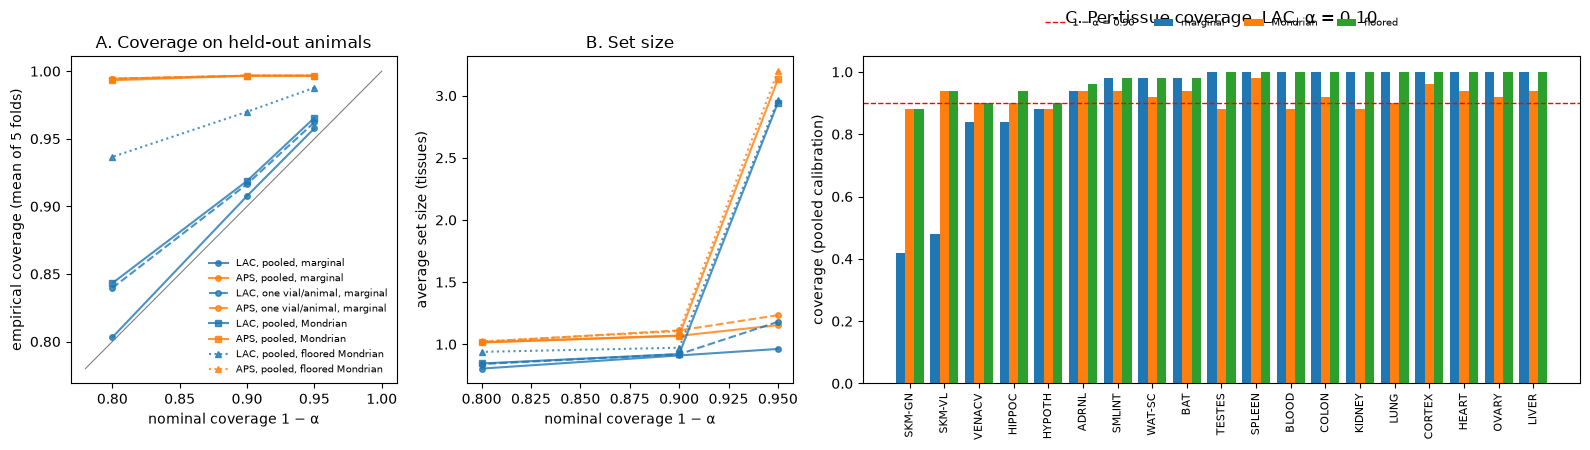

In [48]:
# One figure: (A) coverage vs nominal 1 − α; (B) average set size; (C) per-tissue coverage at LAC α = 0.1.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1, 1, 2.2]})
styles = {("pooled", "marginal"): ("pooled, marginal", "-o"), ("one_per_animal", "marginal"): ("one vial/animal, marginal", "--o"),
          ("pooled", "mondrian"): ("pooled, Mondrian", "-s"), ("pooled", "floored"): ("pooled, floored Mondrian", ":^")}
colors = {"lac": "tab:blue", "aps": "tab:orange"}
agg = s06_cov.groupby(["calibration", "conformal", "method", "alpha"]).agg(coverage=("coverage", "mean"),
                                                                          size=("avg_set_size", "mean")).reset_index()
for (cal, cname), (lab, ls) in styles.items():
    for method in ("lac", "aps"):
        d = agg[(agg.calibration == cal) & (agg.conformal == cname) & (agg.method == method)].sort_values("alpha")
        axes[0].plot(1 - d["alpha"], d["coverage"], ls, color=colors[method], label=f"{method.upper()}, {lab}", ms=4, alpha=0.8)
        axes[1].plot(1 - d["alpha"], d["size"], ls, color=colors[method], ms=4, alpha=0.8)
axes[0].plot([0.78, 1.0], [0.78, 1.0], color="grey", lw=0.8)
axes[0].set(xlabel="nominal coverage 1 − α", ylabel="empirical coverage (mean of 5 folds)", title="A. Coverage on held-out animals")
axes[1].set(xlabel="nominal coverage 1 − α", ylabel="average set size (tissues)", title="B. Set size")
axes[0].legend(fontsize=7, frameon=False)
d = s06_mpt.sort_values("coverage_marginal")
xx = np.arange(len(d))
for off, col, lab in ((-0.27, "coverage_marginal", "marginal"), (0, "coverage_mondrian", "Mondrian"), (0.27, "coverage_floored", "floored")):
    axes[2].bar(xx + off, d[col], width=0.27, label=lab)
axes[2].axhline(0.9, color="red", ls="--", lw=1, label="1 − α = 0.90")
axes[2].set_xticks(xx, d["y_true"], rotation=90, fontsize=8)
axes[2].set(ylabel="coverage (pooled calibration)", ylim=(0, 1.05), title="C. Per-tissue coverage, LAC, α = 0.10")
axes[2].legend(fontsize=7, frameon=False, ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.06))
axes[2].set_title("C. Per-tissue coverage, LAC, α = 0.10", pad=24)
fig.tight_layout()
fig.savefig(OUT / "s06" / "conformal_summary.png", dpi=150)
plt.show()

**What this shows.** The marginal guarantee holds on average while a handful of tissues — the two
skeletal muscles first, then the brain regions and vena cava, i.e. the tissues the classifier
confuses with a neighbour — are covered far less often than 1 − α (panel C and the table above).
Mondrian calibration pulls every tissue towards 1 − α: *up* for the confusable tissues (their own,
looser threshold lets the true tissue into the set instead of leaving it empty) and *down* for the
easy ones (their own threshold, from a couple of dozen well-classified vials, is tighter than the
marginal one). At α = 0.10 the set sizes equal the coverages, i.e. the sets are singletons or empty
under all three variants. The floored variant keeps the easy tissues at the marginal threshold, so
it covers at least as well as both. After the quantile fix the α = 0.05 Mondrian and floored sets
are much larger than before (the `_prefix` columns): the two sex-specific tissues have too few
calibration vials (the printed minimum) for a finite threshold at α = 0.05, so under the textbook
rule OVARY and TESTES enter *every* set — the honest answer "this calibration set cannot support
α = 0.05 for these classes"; the old rule silently used their largest score instead.

**What it does not show.** Per-tissue coverage here comes from about ten test animals per tissue
per fold, so a single value can move by 0.1 with one animal. Pooled calibration treats the vials of
one animal as exchangeable with other animals' vials; its test-animal coverage is the empirical
check, not a proof. None of this is a guarantee under shift (section 8).

## 7. The certified panel size (Learn-then-Test with Clopper–Pearson)

**Question.** Section 5 found the smallest panel whose *average* cross-validated balanced accuracy
reaches 1 − α. A certificate asks for more: a panel size k such that, with probability at least
1 − δ over the draw of calibration animals, the panel's error on new animals is at most α. The
pipeline certifies k by Learn-then-Test: for each k on a fixed grid (10, 15, 20, 30, 50, 100), fit
the k-gene panel on the fit animals, count its errors on the calibration animals, compute the
one-sided Clopper–Pearson upper bound on the error rate, and test from the largest k downward,
stopping at the first k whose bound exceeds α. The primary certificate (`make conformal`, first
command) uses α = δ = 0.10, 22 calibration animals and **one vial per animal** as the loss unit;
the fit/calibration split is repeated 20 times in each of 5 outer folds (100 splits), so the
certified k comes with a distribution.

**Why it matters.** "20 genes identify the tissue" is a point estimate; the certificate says how
many genes one can *promise* with this many animals — and whether the study is large enough to
promise anything.

**What to look for.** (1) The zero-error sizing table: how many calibration animals a certificate
needs when the panel makes no calibration error at all. (2) How often each k is certified over the
100 splits, and how often no k is. (3) Validity: at the certified k, is the test error ≤ α in at
least 1 − δ of the splits? (4) Why the certified k is larger than the point-estimate k.

### 7a. Zero-error sizing: how many calibration units does a certificate need?

With zero errors in n calibration units, the one-sided Clopper–Pearson upper bound is
1 − δ^(1/n). It falls to α only when n ≥ ln δ / ln(1 − α). The cell computes that bound for the
pipeline's four (α, δ) pairs and checks it against the pipeline's `sizing_table.csv` (post-fix and
pre-fix copies), and against the library's `clopper_pearson_upper`.

In [49]:
section("7 certificate")
# from scripts/06_conformal_certify.py (verbatim constant and the sizing block of main)
SIZING_PAIRS = [(0.05, 0.05), (0.10, 0.05), (0.10, 0.10), (0.20, 0.10)]
s07_sizing = pd.DataFrame([{"alpha": a, "delta": d, "n_zero_error_needed": int(np.ceil(np.log(d) / np.log(1 - a)))}
                           for a, d in SIZING_PAIRS])
# check with the library bound: the smallest n with UCB(0 errors, n, δ) ≤ α
s07_sizing["n_by_cp_search"] = [next(n for n in range(1, 500) if cp.clopper_pearson_upper(0, n, d) <= a) for a, d in SIZING_PAIRS]
S07_PRE = REPO / "backup" / "pipeline_history" / "results_pre_quantile_fix_2026-09-25" / "06_conformal"
pub = pd.read_csv(res("06_conformal", "TRNSCRPT", "sizing_table.csv"))
pre = pd.read_csv(S07_PRE / "TRNSCRPT" / "sizing_table.csv")
s07_sizing["published_post_fix"] = pub["n_zero_error_needed"].to_numpy()
s07_sizing["published_pre_fix"] = pre["n_zero_error_needed"].to_numpy()
display(s07_sizing)
for (a, d), n in zip(SIZING_PAIRS, s07_sizing["n_zero_error_needed"]):
    record(f"s07.sizing_a{a:.2f}_d{d:.2f}", n, "07", "ceil(ln δ / ln(1 − α))")

# the bound at the primary design (n = 22 calibration animals, δ = 0.10) for 0, 1, 2 errors
s07_n_cal, s07_alpha, s07_delta = 22, 0.10, 0.10
s07_ucb = pd.DataFrame({"n_err": [0, 1, 2]})
s07_ucb["point_error"] = s07_ucb["n_err"] / s07_n_cal
s07_ucb["cp_upper_bound"] = [cp.clopper_pearson_upper(e, s07_n_cal, s07_delta) for e in s07_ucb["n_err"]]
s07_ucb["passes_alpha"] = s07_ucb["cp_upper_bound"] <= s07_alpha
print(f"Clopper–Pearson (1 − δ) upper bound with n = {s07_n_cal} calibration animals, δ = {s07_delta}:")
display(s07_ucb.round(4))
record("s07.ucb_0err_n22", s07_ucb.loc[0, "cp_upper_bound"], "07", "CP upper bound, 0 errors of 22, δ=0.10")
record("s07.ucb_1err_n22", s07_ucb.loc[1, "cp_upper_bound"], "07", "CP upper bound, 1 error of 22, δ=0.10")

,alpha,delta,n_zero_error_needed,n_by_cp_search,published_post_fix,published_pre_fix
0,0.05,0.05,59,59,59,59
1,0.10,0.05,29,29,29,29
2,0.10,0.10,22,22,22,22
3,0.20,0.10,11,11,11,11


Clopper–Pearson (1 − δ) upper bound with n = 22 calibration animals, δ = 0.1:


,n_err,point_error,cp_upper_bound,passes_alpha
0,0,0.0000,0.0994,True
1,1,0.0455,0.1656,False
2,2,0.0909,0.2242,False


**What this shows.** The table's first column is the whole design problem: to certify a tissue call
at (0.05, 0.05) one needs more zero-error calibration animals than the study has per tissue, and at
the primary (0.10, 0.10) the 22 calibration animals are *exactly* the minimum — the bound with zero
errors sits just under α, and a single wrong calibration animal pushes it far above. So the primary
certificate is a zero-error certificate: a panel size is certified only if the panel classifies the
one random vial of every one of the 22 calibration animals correctly.

**What it does not show.** Nothing here depends on the data; it is arithmetic on the binomial. It
also does not depend on the conformal quantile (no quantile is involved).

### 7b. The certificate over 100 fit/calibration splits

With `RECOMPUTE = False` the 100-split certificate is loaded from the pipeline's
`results/06_conformal/TRNSCRPT/` (it fits 100 + 20 panel families, a few minutes). With
`RECOMPUTE = True` the cell below re-runs it (copied script logic) and writes under `OUT/s07/`.
Either way, the distribution, the validity check and the (α, δ) grid are then computed *in this
notebook* from the per-split tables and compared with the pipeline's summary files.

In [50]:
# from scripts/06_conformal_certify.py::panel_family (verbatim)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


def panel_family(X_fit, y_fit, grid, prefilter, model):
    """Preprocessing (impute → variance prefilter → scale → round-robin scores) fit once on the fit
    animals; then one k-panel classifier per k. Same model as the quick pipeline of phase 05
    (logreg_l2: C = 0.1). Returns predict(k, X)."""
    if model != "logreg_l2":
        raise ValueError("the certificate is defined for --model logreg_l2 (round-robin panel + L2 logistic regression)")
    imp = SimpleImputer(strategy="median").fit(X_fit)
    pre = models.VarianceTopK(prefilter).fit(imp.transform(X_fit))
    sc = StandardScaler().fit(pre.transform(imp.transform(X_fit)))
    Xs = sc.transform(pre.transform(imp.transform(X_fit)))
    sel = models.RoundRobinSelector(k=max(grid)).fit(Xs, y_fit)
    order = sel.order_
    fam = {}
    for k in grid:
        idx = np.sort(order[:k])
        fam[k] = (idx, LogisticRegression(solver="lbfgs", C=0.1, max_iter=3000).fit(Xs[:, idx], y_fit))

    def predict(k, X):
        Z = sc.transform(pre.transform(imp.transform(X)))
        idx, clf = fam[k]
        return clf.predict(Z[:, idx])
    return predict


# from scripts/06_conformal_certify.py::certify_losses (verbatim)
def certify_losses(predict, X, y, g, cal_idx, cal_opa, te, grid, alpha, delta, one_per_animal):
    """Certified k under the chosen loss and under the per-animal any-wrong loss; test error per k."""
    errors, errors_animal, test_err = {}, {}, {}
    m_opa = np.isin(cal_idx, cal_opa)
    for k in grid:
        wrong = predict(k, X[cal_idx]) != y[cal_idx]
        errors[k] = (int(wrong[m_opa].sum()), int(m_opa.sum())) if one_per_animal else (int(wrong.sum()), len(cal_idx))
        any_wrong = pd.Series(wrong).groupby(g[cal_idx]).any()
        errors_animal[k] = (int(any_wrong.sum()), int(len(any_wrong)))
        test_err[k] = float((predict(k, X[te]) != y[te]).mean()) if len(te) else np.nan
    k1, t1 = cp.certify_panel_size(errors, alpha, delta)
    k2, t2 = cp.certify_panel_size(errors_animal, alpha, delta)
    t1["loss"] = "one_vial_per_animal" if one_per_animal else "pooled_vials"
    t2["loss"] = "animal_any_tissue_wrong"
    return k1, k2, pd.concat([t1, t2], ignore_index=True), test_err, errors

In [51]:
# the flags of `make conformal` (first command)
s07_args = SimpleNamespace(label="tissue", model="logreg_l2", n_splits=5, prefilter=5000, seed=C.SEED, cal_frac=0.3,
                           cal_animals=22, n_repeats=20, one_per_animal=True, alpha=0.1, delta=0.1,
                           grid=[10, 15, 20, 30, 50, 100], k_of_interest=20)
LOSS = "one_vial_per_animal"
if RECOMPUTE:
    # from scripts/06_conformal_certify.py::main — the repeat loop, certificate leg (b), and the deployment certificate
    # (trimmed: conformal-set leg (a) is section 6; `args.` → `a.`; `om` → `om_trn`)
    a = s07_args
    om_trn = cached("TRNSCRPT_counts", lambda: io.stack_tissues(
        "TRNSCRPT", tissues=None, source=resolve_source("TRNSCRPT", "auto"), join="inner", pheno=cached("pheno", io.load_pheno),
        complete=False, drop_incomplete_samples=None))
    X = om_trn.X.to_numpy(dtype=float)
    y = om_trn.meta[a.label].astype(str).to_numpy()
    g = om_trn.groups()
    grid = [k for k in a.grid if k <= X.shape[1]]
    cert_rows, valid_rows = [], []
    for fold, (tr, te) in enumerate(grouped_kfold(om_trn.meta, a.label, a.n_splits, a.seed)):
        for rep in range(a.n_repeats):
            seed_r = a.seed + 1000 * fold + rep
            fit_idx, cal_idx = split_train(om_trn.meta, tr, a.cal_frac, a.cal_animals, seed_r)
            cal_opa = cp.one_per_group(cal_idx, g, seed_r)
            predict = panel_family(X[fit_idx], y[fit_idx], grid, a.prefilter, a.model)
            k1, k2, table, test_err, errs = certify_losses(predict, X, y, g, cal_idx, cal_opa, te, grid, a.alpha, a.delta,
                                                           a.one_per_animal)
            table["fold"], table["repeat"] = fold, rep
            table["test_err"] = table["k"].map(test_err)
            cert_rows.append(table)
            valid_rows.append({"fold": fold, "repeat": rep, "n_fit_animals": int(om_trn.meta.iloc[fit_idx]["pid"].nunique()),
                               "n_cal_animals": int(om_trn.meta.iloc[cal_idx]["pid"].nunique()),
                               "n_cal_loss": int(len(cal_opa)) if a.one_per_animal else int(len(cal_idx)),
                               "certified_k": k1, "certified_k_animal_any_wrong": k2,
                               "test_err_at_certified_k": test_err.get(k1, np.nan) if k1 else np.nan,
                               "test_err_le_alpha": (test_err.get(k1, 1.0) <= a.alpha) if k1 else None})
        print(f"  fold {fold}: certified k over {a.n_repeats} repeats: {[v['certified_k'] for v in valid_rows if v['fold'] == fold]}")
    s07_cert = pd.concat(cert_rows, ignore_index=True)
    s07_valid = pd.DataFrame(valid_rows)
    all_idx = np.arange(len(y))
    final_rows = []
    for rep in range(a.n_repeats):
        fit_idx, cal_idx = split_train(om_trn.meta, all_idx, a.cal_frac, a.cal_animals, a.seed + 999 + rep)
        cal_opa = cp.one_per_group(cal_idx, g, a.seed + 999 + rep)
        predict = panel_family(X[fit_idx], y[fit_idx], grid, a.prefilter, a.model)
        k1, k2, table, _, _ = certify_losses(predict, X, y, g, cal_idx, cal_opa, np.array([], dtype=int), grid,
                                             a.alpha, a.delta, a.one_per_animal)
        final_rows.append({"repeat": rep, "n_fit_animals": int(om_trn.meta.iloc[fit_idx]["pid"].nunique()),
                           "n_cal_animals": int(om_trn.meta.iloc[cal_idx]["pid"].nunique()), "certified_k": k1,
                           "certified_k_animal_any_wrong": k2})
    s07_final = pd.DataFrame(final_rows)
    del a
    (OUT / "s07").mkdir(parents=True, exist_ok=True)
    s07_cert.to_csv(OUT / "s07" / "certificate_by_fold.csv", index=False)
    s07_valid.to_csv(OUT / "s07" / "certificate_validity.csv", index=False)
    s07_final.to_csv(OUT / "s07" / "certificate_final_repeats.csv", index=False)
else:
    s07_cert = pd.read_csv(res("06_conformal", "TRNSCRPT", "certificate_by_fold.csv"))
    s07_valid = pd.read_csv(res("06_conformal", "TRNSCRPT", "certificate_validity.csv"))
    s07_final = pd.read_csv(res("06_conformal", "TRNSCRPT", "certificate_final_repeats.csv"))
print(f"{len(s07_valid)} fit/calibration splits; {s07_valid['n_cal_loss'].iloc[0]} calibration units per split "
      f"({s07_valid['n_fit_animals'].iloc[0]} fit / {s07_valid['n_cal_animals'].iloc[0]} calibration animals)")

100 fit/calibration splits; 22 calibration units per split (18 fit / 22 calibration animals)


In [52]:
# from scripts/06_conformal_certify.py::main (verbatim: distribution of the certified k over folds × repeats)
grid = s07_args.grid
valid = s07_valid
dist = []
for k in grid:
    dist.append({"k": k, "frac_certified": float(valid["certified_k"].apply(lambda v: v is not None and not pd.isna(v) and v <= k).mean()),
                 "frac_certified_animal_any_wrong": float(valid["certified_k_animal_any_wrong"].apply(lambda v: v is not None and not pd.isna(v) and v <= k).mean())})
dist = pd.DataFrame(dist)
k_half = dist.loc[dist["frac_certified"] >= 0.5, "k"].min() if (dist["frac_certified"] >= 0.5).any() else None
ks = valid["certified_k"].dropna()
n_none = int(valid["certified_k"].isna().sum())
s07_dist = dist.merge(pd.read_csv(res("06_conformal", "TRNSCRPT", "certificate_distribution.csv")), on="k", suffixes=("", "_published"))
print("fraction of the splits whose certified k is ≤ k (cumulative), this notebook vs the pipeline's file:")
display(s07_dist)
print("certified k over the splits (value: number of splits):", ks.astype(int).value_counts().sort_index().to_dict(),
      f"| none certified: {n_none}")
print(f"certified k: min {int(ks.min())}, median {ks.median()}, max {int(ks.max())}; smallest k certified in ≥ half the splits: {k_half}")
s07_validity = float(valid["test_err_le_alpha"].dropna().astype(bool).mean())
print(f"validity: fraction of certified splits with test error ≤ α at the certified k = {s07_validity:.2f} "
      f"(target ≥ 1 − δ = {1 - s07_args.delta:.2f}); worst test error at a certified k = {valid['test_err_at_certified_k'].max():.3f}")
print("deployment certificate on all animals (20 repeats), certified k:",
      s07_final["certified_k"].value_counts(dropna=False).sort_index().to_dict())
record("s07.frac_certified_k20", float(dist.loc[dist.k == 20, "frac_certified"].iloc[0]), "07", "fraction of 100 splits certifying k ≤ 20")
record("s07.frac_certified_k15", float(dist.loc[dist.k == 15, "frac_certified"].iloc[0]), "07", "fraction of 100 splits certifying k ≤ 15")
record("s07.n_none_certified", n_none, "07", "splits certifying no k")
record("s07.k_half", k_half, "07", "smallest k certified in ≥ half the splits")
record("s07.validity", s07_validity, "07", "fraction of certified splits with test error ≤ α")
record("s07.frac_any_animal_any_wrong", float(dist["frac_certified_animal_any_wrong"].max()), "07", "per-animal any-wrong loss: fraction certifying any k")
del valid, dist, grid

fraction of the splits whose certified k is ≤ k (cumulative), this notebook vs the pipeline's file:


,k,frac_certified,frac_certified_animal_any_wrong,frac_certified_published,frac_certified_animal_any_wrong_published
0,10,0.00,0.0,0.00,0.0
1,15,0.34,0.0,0.34,0.0
2,20,0.52,0.0,0.52,0.0
3,30,0.52,0.0,0.52,0.0
4,50,0.64,0.0,0.64,0.0
5,100,0.70,0.0,0.70,0.0


certified k over the splits (value: number of splits): {15: 34, 20: 18, 50: 12, 100: 6} | none certified: 30
certified k: min 15, median 20.0, max 100; smallest k certified in ≥ half the splits: 20
validity: fraction of certified splits with test error ≤ α at the certified k = 1.00 (target ≥ 1 − δ = 0.90); worst test error at a certified k = 0.061
deployment certificate on all animals (20 repeats), certified k: {15.0: 6, 20.0: 3, 30.0: 1, 50.0: 2, 100.0: 1, nan: 7}


In [53]:
# (α, δ) grid on the same calibration errors (from scripts/06_conformal_certify.py::main, verbatim logic;
# the per-split error counts `err_store` are rebuilt from certificate_by_fold.csv, loss = one vial per animal)
cb = s07_cert[s07_cert["loss"] == LOSS]
err_store = [{int(r.k): (int(r.n_err), int(r.n_cal)) for r in grp.itertuples()} for _, grp in cb.groupby(["fold", "repeat"], sort=True)]
ad_grid = [(0.05, 0.05), (0.10, 0.05), (0.10, 0.10), (0.20, 0.05), (0.20, 0.10), (0.05, 0.10)]
ad_rows = []
for a_, d_ in ad_grid:
    ks_ad = [cp.certify_panel_size(e, a_, d_)[0] for e in err_store]
    ks_ok = [k for k in ks_ad if k is not None]
    ad_rows.append({"alpha": a_, "delta": d_, "n_splits": len(ks_ad),
                    f"frac_certified_k{s07_args.k_of_interest}": float(np.mean([(k is not None and k <= s07_args.k_of_interest) for k in ks_ad])),
                    "frac_any_certified": float(np.mean([k is not None for k in ks_ad])),
                    "median_certified_k": float(np.median(ks_ok)) if ks_ok else np.nan})
s07_ad = pd.DataFrame(ad_rows).merge(pd.read_csv(res("06_conformal", "TRNSCRPT", "certificate_alpha_delta_grid.csv")),
                                     on=["alpha", "delta"], suffixes=("", "_published"))
display(s07_ad)
record("s07.ad_a20_d10_frac_k20", float(s07_ad.loc[(s07_ad.alpha == 0.2) & (s07_ad.delta == 0.1), "frac_certified_k20"].iloc[0]), "07",
       "(α, δ) = (0.20, 0.10): fraction certifying k ≤ 20")
del cb

,alpha,delta,n_splits,frac_certified_k20,frac_any_certified,median_certified_k,n_splits_published,frac_certified_k20_published,frac_any_certified_published,median_certified_k_published
0,0.05,0.05,100,0.00,0.00,NaN,100,0.00,0.00,NaN
1,0.10,0.05,100,0.00,0.00,NaN,100,0.00,0.00,NaN
2,0.10,0.10,100,0.52,0.70,20.0,100,0.52,0.70,20.0
3,0.20,0.05,100,0.89,0.97,15.0,100,0.89,0.97,15.0
4,0.20,0.10,100,0.89,0.97,15.0,100,0.89,0.97,15.0
5,0.05,0.10,100,0.00,0.00,NaN,100,0.00,0.00,NaN


**What this shows.** The certified k is a random variable, not a number: across the 100 splits it
lands most often on the smallest certifiable sizes, but it is spread over the whole grid and no k
is certified at all in a sizeable share of splits (the "none certified" count). Where it certifies,
it is valid — the test error at the certified k stays at or below α in the validity line above.
The per-animal "any tissue of this animal wrong" loss never certifies anything (its column in the
distribution table): an animal counts as wrong if any of its ~18 vials is wrong, and at every k
enough calibration animals have one wrong vial to break a zero-error certificate. Loosening the target to
α = 0.20 (the grid) makes the certificate routine; tightening δ or α to 0.05 makes it impossible —
consistent with the sizing table.

**What it does not show.** 100 splits of one dataset are not 100 independent studies: the splits
share animals, so the distribution is narrower than a new study's would be. The deployment
certificate re-uses all animals and has no test set, so it has no validity check of its own.

### 7c. Why the certified k exceeds the point-estimate k

**Question.** Section 5's panel curve reaches mean balanced accuracy ≥ 1 − α at a smaller k than
the certificate usually certifies. Where does the gap come from? The table below is derived from the
per-split certificate table: for every k, the mean test error over the splits (what a point estimate
sees), the fraction of splits in which the panel made **zero** errors on the 22 calibration animals,
the zero-error probability that the mean test error predicts if the 22 calibration vials were
independent draws, `(1 − err)^22`, and the fraction of splits certifying *this very* k (fixed-sequence
testing also needs every larger k to pass).

In [54]:
# point-estimate k: from the phase-05 panel curve (verbatim logic of scripts/06_conformal_certify.py::main)
curve = pd.read_csv(res("05_panels", "TRNSCRPT", "panel_curve.csv")).groupby("k")["balanced_accuracy"].mean()
s07_point_k = int(curve[curve >= 1 - s07_args.alpha].index.min()) if (curve >= 1 - s07_args.alpha).any() else None
print(f"point-estimate k (smallest k with mean 5-fold balanced accuracy ≥ {1 - s07_args.alpha:.2f}): {s07_point_k}")
record("s07.point_k", s07_point_k, "07", "phase-05 curve, mean balanced accuracy ≥ 0.90")

cb = s07_cert[s07_cert["loss"] == LOSS]
n = int(cb["n_cal"].iloc[0])
s07_why = cb.groupby("k").agg(mean_test_err=("test_err", "mean"), mean_cal_err=("err_hat", "mean"),
                              frac_zero_cal_errors=("n_err", lambda v: float((v == 0).mean())),
                              mean_ucb=("ucb", "mean"), frac_k_passes_alone=("ucb", lambda v: float((v <= s07_args.alpha).mean()))).reset_index()
s07_why["pred_zero_err_prob"] = (1 - s07_why["mean_test_err"]) ** n
s07_why["frac_certified_this_k"] = s07_why["k"].map(s07_valid["certified_k"].value_counts() / len(s07_valid)).fillna(0.0)
s07_why["frac_certified_le_k"] = s07_why["k"].map(lambda k: float((s07_valid["certified_k"] <= k).mean()))
s07_why["curve_bal_acc"] = s07_why["k"].map(curve)
display(s07_why.round(3))
for k in (15, 20):
    r = s07_why.set_index("k").loc[k]
    record(f"s07.frac_zero_err_k{k}", r["frac_zero_cal_errors"], "07", f"fraction of splits with 0 calibration errors at k={k}")
    record(f"s07.mean_test_err_k{k}", r["mean_test_err"], "07", f"mean test error at k={k} over 100 splits")
del cb, n, curve

point-estimate k (smallest k with mean 5-fold balanced accuracy ≥ 0.90): 15


,k,mean_test_err,mean_cal_err,frac_zero_cal_errors,mean_ucb,frac_k_passes_alone,pred_zero_err_prob,frac_certified_this_k,frac_certified_le_k,curve_bal_acc
0,10,0.193,0.185,0.00,0.332,0.00,0.009,0.00,0.00,0.814
1,15,0.042,0.045,0.37,0.161,0.37,0.388,0.34,0.34,0.975
2,20,0.024,0.026,0.55,0.136,0.55,0.585,0.18,0.52,0.976
3,30,0.023,0.026,0.54,0.137,0.54,0.599,0.00,0.52,0.981
4,50,0.017,0.019,0.65,0.127,0.65,0.687,0.12,0.64,0.993
5,100,0.013,0.015,0.70,0.121,0.70,0.744,0.06,0.70,0.993


**What this shows — the derivation.** Read the table from left to right.

1. *The point estimate is an average.* The point-estimate k is the first grid value whose mean
   balanced accuracy (`curve_bal_acc`) clears 1 − α; its mean test error is already well below α.
   On average, the panel is good enough there — and that is all the phase-05 curve says.
2. *The certificate is a zero-error test at this design.* From 7a, with 22 calibration units and
   δ = 0.10, zero errors give a bound just below α and one error gives a bound far above it. So a
   k passes only in the splits where the panel got all 22 calibration vials right
   (`frac_k_passes_alone` equals `frac_zero_cal_errors`).
3. *Zero errors in 22 draws is rare unless the error rate is far below α.* If the error rate is p,
   the chance of 22 correct calls is about (1 − p)^22; the `pred_zero_err_prob` column shows this
   tracks the observed zero-error fraction. Even at the point-estimate k, whose error is well below
   α, 22 correct calls in a row happen in only a minority of splits; a k is certified in about half
   of the splits only once its error is several times smaller than α.
4. *Fixed-sequence testing compounds it.* Testing starts at the largest k and stops at the first
   failure, so a k is certified only if it *and every larger k* made zero calibration errors — one
   unlucky vial at k = 30 ends the certificate at 50, whatever smaller panels do. That is why the
   cumulative certified fraction at a k (`frac_certified_le_k`) is at or below that k's own pass rate.

Together: the certified k is the smallest k whose error is small enough that 22 consecutive correct
calls are likely — a stricter target than "average error ≤ α", so it sits above the point-estimate
k. The gap is the price of a guarantee over an estimate, and with this study's animal count it
shrinks only if α or δ are relaxed or more calibration animals are added.

**What it does not show.** The calibration vials are not independent draws of one error rate (the
error rate differs by tissue, and one vial per animal is a random tissue), so `(1 − err)^22` is an
approximation used only to explain the pattern; the certificate itself uses the exact counts.

### 7d. Did the conformal-quantile fix move the certificate?

**What to look for.** It should not: the certificate never calls the conformal quantile. It counts
calibration errors and bounds them with Clopper–Pearson. The cell compares every certificate file
of both certificate runs (primary; and the secondary pooled-vial run at α = δ = 0.05) between the
pre-fix backup and the post-fix pipeline results.

In [55]:
rows = []
for run in ("TRNSCRPT", "TRNSCRPT_pooled_a05"):
    for f in ("certificate_by_fold.csv", "certificate_validity.csv", "certificate_distribution.csv", "certificate_final.csv",
              "certificate_final_repeats.csv", "certificate_alpha_delta_grid.csv", "sizing_table.csv"):
        a_, b_ = pd.read_csv(S07_PRE / run / f), pd.read_csv(res("06_conformal", run, f))
        same_shape = a_.shape == b_.shape and list(a_.columns) == list(b_.columns)
        ints = [c for c in a_.columns if c in ("k", "n_cal", "n_err", "certified", "certified_k", "certified_k_animal_any_wrong",
                                               "n_zero_error_needed", "frac_certified", "frac_any_certified", "median_certified_k",
                                               "frac_certified_k20", "test_err_le_alpha", "loss")]
        counts_equal = same_shape and all(a_[c].astype(str).equals(b_[c].astype(str)) for c in ints)
        flo = [c for c in a_.columns if c not in ints and pd.api.types.is_float_dtype(a_[c])]
        max_diff = max([float(np.nanmax(np.abs(a_[c].to_numpy() - b_[c].to_numpy()))) if len(a_) else 0.0 for c in flo] or [0.0]) if same_shape else np.nan
        rows.append({"run": run, "file": f, "identical_bytes": (S07_PRE / run / f).read_bytes() == res("06_conformal", run, f).read_bytes(),
                     "counts_and_ks_equal": counts_equal, "max_abs_float_diff": max_diff})
s07_fixcmp = pd.DataFrame(rows)
display(s07_fixcmp)
print("certified k (primary, 100 splits) pre-fix == post-fix:",
      pd.read_csv(S07_PRE / "TRNSCRPT" / "certificate_validity.csv")["certified_k"].equals(
          pd.read_csv(res("06_conformal", "TRNSCRPT", "certificate_validity.csv"))["certified_k"]))
record("s07.n_cert_files_counts_changed", int((~s07_fixcmp["counts_and_ks_equal"]).sum()), "07",
       "certificate files whose error counts / certified k changed with the quantile fix")
del rows

,run,file,identical_bytes,counts_and_ks_equal,max_abs_float_diff
0,TRNSCRPT,certificate_by_fold.csv,True,True,0.0000e+00
1,TRNSCRPT,certificate_validity.csv,True,True,0.0000e+00
2,TRNSCRPT,certificate_distribution.csv,True,True,0.0000e+00
3,TRNSCRPT,certificate_final.csv,True,True,0.0000e+00
4,TRNSCRPT,certificate_final_repeats.csv,True,True,0.0000e+00
5,TRNSCRPT,certificate_alpha_delta_grid.csv,True,True,0.0000e+00
6,TRNSCRPT,sizing_table.csv,True,True,0.0000e+00
7,TRNSCRPT_pooled_a05,certificate_by_fold.csv,False,True,2.2204e-16
8,TRNSCRPT_pooled_a05,certificate_validity.csv,True,True,0.0000e+00
9,TRNSCRPT_pooled_a05,certificate_distribution.csv,True,True,0.0000e+00


certified k (primary, 100 splits) pre-fix == post-fix: True


**What this shows.** Every error count and every certified k is unchanged by the quantile fix, in
both certificate runs. Where a file is not byte-identical, the only differences are in the last
floating-point digits of the Clopper–Pearson bound (the `max_abs_float_diff` column), i.e. numerical
noise in `scipy.stats.beta.ppf` between runs — not a change in any count or decision.

**What it does not show.** That the certificate is *right*; only that it is independent of the
conformal quantile, as it should be.

## 8. Shift tests: does the fingerprint — and its coverage guarantee — survive a shift?

**Question.** Sections 6–7 evaluated on held-out animals drawn from the same design. Here the test
animals differ systematically from the training animals: train on one sex and test on the other
(both ways); hold out a whole time point (8 w, 1 w); train on sedentary controls and test on every
trained animal. For each split the pipeline fits the full-feature classifier and the k = 20 panel,
calibrates LAC sets (α = 0.10) on 30 % of the *source* animals (pooled vials), and reports accuracy,
in-distribution coverage on held-out source animals, and coverage on the target. It then asks
whether calibrating on a few *target* animals (3 or 5, 10 random draws) buys the guarantee back.

**Why it matters.** Conformal coverage is guaranteed only under exchangeability. A shift can break
the guarantee while accuracy still looks fine — and a tool that reports "90 % sets" would then be
silently wrong.

**What to look for.** Accuracy that stays high while target coverage falls below source coverage
(the guarantee breaks before the classifier does); unseen classes under the sex shift (OVARY and
TESTES exist in one sex only; they are listed and excluded from the "seen" columns); whether a few
target animals restore coverage.

The TRNSCRPT splits are recomputed live (the pipeline phase took about a minute and a half). The
metabolomics arm (9 core tissues, complete features only, k = 10) is small and is recomputed too.

In [56]:
section("8 shift tests")


# from scripts/08_shift_tests.py::coverage_with (verbatim)
def coverage_with(est, cls, X_te, y_te, qhat, method):
    sets = cp.predict_sets(est.predict_proba(X_te), qhat, method)
    cov, n_dropped = cp.coverage_seen(sets, y_te, cls)
    return cov, float(sets.sum(axis=1).mean()), n_dropped


# from scripts/08_shift_tests.py::eval_split (verbatim except one name: `models.balanced_accuracy_score` →
# `balanced_accuracy_score`, because the notebook's `models` namespace holds only the module's own definitions,
# not its imports; the sklearn function is the same object)
def eval_split(name, tr, te, X, y, g, meta, k, alpha, model, prefilter, quick, seed, method="lac",
               one_per_animal=False, recal_ns=(), recal_repeats=10):
    fit_idx, cal_idx = fit_calibration_split(meta, tr, 0.3, seed)
    cal_used = cp.one_per_group(cal_idx, g, seed) if one_per_animal else cal_idx
    rows, per_class, recal_rows, variant_rows = [], [], [], []
    for arm, kk in (("full", None), (f"panel_k{k}", k)):
        est = models.fit_tuned(model, X[fit_idx], y[fit_idx], g[fit_idx], k=kk, prefilter=prefilter, quick=quick, seed=seed)
        cls = list(est.classes_)
        unseen = sorted(set(y[te]) - set(cls))
        scores, n_cal_dropped = cp.calibration_scores(est.predict_proba(X[cal_used]), y[cal_used], cls, method)
        qhat = cp.conformal_quantile(scores, alpha)
        p_te = est.predict_proba(X[te])
        sets_te = cp.predict_sets(p_te, qhat, method)
        yi_te, seen_mask = cp.class_indices(y[te], cls)
        covered = np.zeros(len(te), dtype=bool)
        covered[seen_mask] = sets_te[np.flatnonzero(seen_mask), yi_te[seen_mask]]
        size = sets_te.sum(axis=1)
        # class-conditional variants from the same calibration scores: Mondrian and marginal-floor Mondrian
        yi_cal, seen_cal = cp.class_indices(y[cal_used], cls)
        q_variants = {"mondrian": cp.conformal_quantile_per_class(scores, yi_cal[seen_cal], alpha, len(cls), fallback=qhat),
                      "floored": cp.conformal_quantile_per_class(scores, yi_cal[seen_cal], alpha, len(cls), fallback=qhat, floor=qhat)}
        variant_sets = {"marginal": sets_te}
        variant_cov = {}
        for vname, qv in q_variants.items():
            sv = cp.predict_sets_conditional(p_te, qv, method)
            cv_ = np.zeros(len(te), dtype=bool)
            cv_[seen_mask] = sv[np.flatnonzero(seen_mask), yi_te[seen_mask]]
            variant_sets[vname], variant_cov[vname] = sv, cv_
        variant_cov["marginal"] = covered
        y_pred = est.predict(X[te])
        acc_all = float(np.mean(y_pred == y[te]))
        bal_seen = balanced_accuracy_score(y[te][seen_mask], y_pred[seen_mask]) if seen_mask.any() else np.nan
        # source in-distribution reference: calibrate on half of the calibration animals, test on the other half
        s_fit, s_cal = fit_calibration_split(meta, cal_idx, 0.5, seed + 1)
        s_fit_used = cp.one_per_group(s_fit, g, seed + 1) if one_per_animal else s_fit
        src_scores, n_src_fit_dropped = cp.calibration_scores(est.predict_proba(X[s_fit_used]), y[s_fit_used], cls, method)
        q_src = cp.conformal_quantile(src_scores, alpha)
        cov_src, size_src, n_src_cal_dropped = coverage_with(est, cls, X[s_cal], y[s_cal], q_src, method)
        n_src_dropped = n_src_fit_dropped + n_src_cal_dropped
        # empty-set rate (LAC) and APS sets under the same shift, same calibration animals
        frac_empty_te = float((sets_te.sum(axis=1) == 0).mean())
        sets_src_lac = cp.predict_sets(est.predict_proba(X[s_cal]), q_src, method)
        frac_empty_src = float((sets_src_lac.sum(axis=1) == 0).mean())
        aps_scores_cal, _ = cp.calibration_scores(est.predict_proba(X[cal_used]), y[cal_used], cls, "aps")
        q_aps = cp.conformal_quantile(aps_scores_cal, alpha)
        cov_aps_te, size_aps_te, _ = coverage_with(est, cls, X[te], y[te], q_aps, "aps")
        aps_src_scores, _ = cp.calibration_scores(est.predict_proba(X[s_fit_used]), y[s_fit_used], cls, "aps")
        _, size_aps_src, _ = coverage_with(est, cls, X[s_cal], y[s_cal], cp.conformal_quantile(aps_src_scores, alpha), "aps")
        if n_cal_dropped or n_src_dropped:
            print(f"  {name} {arm}: dropped {n_cal_dropped} calibration and {n_src_dropped} source-check samples "
                  f"whose class is absent from the fitted estimator ({', '.join(sorted(set(y[cal_idx]) - set(cls))) or '-'})")
        row = {"split": name, "arm": arm, "n_train_animals": int(meta.iloc[tr]["pid"].nunique()),
               "n_test_animals": int(meta.iloc[te]["pid"].nunique()), "n_test": len(te),
               "n_cal": int(len(scores)), "n_cal_animals": int(meta.iloc[cal_idx]["pid"].nunique()),
               "n_cal_dropped_unseen": int(n_cal_dropped), "n_src_dropped_unseen": int(n_src_dropped),
               "unseen_classes": ",".join(unseen), "accuracy_all": acc_all, "bal_acc_seen": bal_seen,
               "coverage_source_id": cov_src, "avg_set_size_source": size_src,
               "coverage_target_all": float(covered.mean()),
               "coverage_target_seen": float(covered[seen_mask].mean()) if seen_mask.any() else np.nan,
               "avg_set_size_target": float(size.mean()), "qhat": qhat, "alpha": alpha,
               "lac_frac_empty_source": frac_empty_src, "lac_frac_empty_target": frac_empty_te,
               "aps_coverage_target_seen": cov_aps_te, "aps_set_size_source": size_aps_src, "aps_set_size_target": size_aps_te}
        for vname in ("mondrian", "floored"):
            row[f"coverage_target_seen_{vname}"] = float(variant_cov[vname][seen_mask].mean()) if seen_mask.any() else np.nan
            row[f"avg_set_size_target_{vname}"] = float(variant_sets[vname].sum(axis=1).mean())
        for vname, sv in variant_sets.items():
            variant_rows.append(pd.DataFrame({"split": name, "arm": arm, "conformal": vname, "y_true": y[te], "covered": variant_cov[vname],
                                              "size": sv.sum(axis=1), "seen": seen_mask})
                                .groupby(["split", "arm", "conformal", "y_true"]).agg(coverage=("covered", "mean"), avg_set_size=("size", "mean"),
                                                                                       n=("covered", "size"), seen=("seen", "all")).reset_index())
        # recalibration on N target animals, test on the remaining target animals (same animals for both quantiles)
        rng = np.random.default_rng(seed + 7)
        t_pids = np.unique(g[te])
        for n_recal in recal_ns:
            if n_recal >= len(t_pids):
                continue
            cov_t, cov_s, sz_t, sz_s, dropped = [], [], [], [], []
            for _ in range(recal_repeats):
                chosen = set(rng.choice(t_pids, size=n_recal, replace=False))
                m_cal = np.array([p in chosen for p in g[te]])
                tcal, ttest = te[m_cal], te[~m_cal]
                assert_no_group_leak(meta, tcal, ttest)
                t_scores, n_drop = cp.calibration_scores(est.predict_proba(X[tcal]), y[tcal], cls, method)
                q_t = cp.conformal_quantile(t_scores, alpha)
                c_t, s_t, _ = coverage_with(est, cls, X[ttest], y[ttest], q_t, method)
                c_s, s_s, _ = coverage_with(est, cls, X[ttest], y[ttest], qhat, method)
                cov_t.append(c_t); cov_s.append(c_s); sz_t.append(s_t); sz_s.append(s_s); dropped.append(n_drop)
            row[f"cov_target_recal_N{n_recal}"] = float(np.nanmean(cov_t))
            row[f"cov_target_srccal_N{n_recal}"] = float(np.nanmean(cov_s))
            recal_rows.append({"split": name, "arm": arm, "n_recal_animals": n_recal, "repeats": recal_repeats,
                               "coverage_target_recalibrated": float(np.nanmean(cov_t)), "coverage_target_recal_sd": float(np.nanstd(cov_t)),
                               "coverage_target_source_cal_same_test": float(np.nanmean(cov_s)),
                               "set_size_recalibrated": float(np.mean(sz_t)), "set_size_source_cal": float(np.mean(sz_s)),
                               "n_recal_dropped_unseen_mean": float(np.mean(dropped))})
        rows.append(row)
        per_class.append(pd.DataFrame({"split": name, "arm": arm, "y_true": y[te], "covered": covered, "size": size})
                         .groupby(["split", "arm", "y_true"]).agg(coverage=("covered", "mean"), avg_set_size=("size", "mean"),
                                                                   n=("covered", "size")).reset_index())
    return rows, pd.concat(per_class), recal_rows, pd.concat(variant_rows)


# from scripts/08_shift_tests.py::main (trimmed: argparse → explicit flags of `make shift`; report and plot dropped;
# the table/per-class assembly is kept verbatim)
def s08_run(om, k, alpha=0.1, model="logreg_l2", prefilter=5000, seed=C.SEED, holdout_groups="8w,1w",
            recal_ns=(3, 5), recal_repeats=10, one_per_animal=False, label="tissue"):
    X = om.X.to_numpy(dtype=float)
    y = om.meta[label].astype(str).to_numpy()
    g = om.groups()
    splits = list(leave_one_sex_out(om.meta))
    splits += list(leave_one_group_out(om.meta, "group", [h.strip() for h in holdout_groups.split(",")]))
    splits += list(train_controls_test_trained(om.meta))
    rows, pcs, recals, variants = [], [], [], []
    for name, (tr, te) in splits:
        r, pc, rc, vr = eval_split(name, tr, te, X, y, g, om.meta, k, alpha, model, prefilter, False,
                                   seed, one_per_animal=one_per_animal, recal_ns=recal_ns, recal_repeats=recal_repeats)
        rows.extend(r); pcs.append(pc); recals.extend(rc); variants.append(vr)
        for rr in r:
            print(f"  {name:28s} {rr['arm']:10s} acc={rr['accuracy_all']:.3f} cov_src={rr['coverage_source_id']:.3f} "
                  f"cov_target={rr['coverage_target_all']:.3f} (seen: {rr['coverage_target_seen']:.3f}) "
                  f"size={rr['avg_set_size_target']:.2f} unseen={rr['unseen_classes'] or '-'}")
    table = pd.DataFrame(rows)
    table["coverage_drop"] = table["coverage_source_id"] - table["coverage_target_seen"]
    table["set_size_change"] = table["avg_set_size_target"] - table["avg_set_size_source"]
    return table, pd.concat(pcs, ignore_index=True), pd.DataFrame(recals), pd.concat(variants, ignore_index=True)

In [57]:
# TRNSCRPT, `make shift` first command: --assay TRNSCRPT --k 20 --recalibrate-target 3,5
pheno = cached("pheno", io.load_pheno)
om_trn = cached("TRNSCRPT_counts", lambda: io.stack_tissues(
    "TRNSCRPT", tissues=None, source=resolve_source("TRNSCRPT", "auto"), join="inner", pheno=pheno,
    complete=False, drop_incomplete_samples=None))
t0 = time.perf_counter()
s08_trn, s08_trn_pc, s08_trn_recal, s08_trn_var = s08_run(om_trn, k=20)
(OUT / "s08").mkdir(parents=True, exist_ok=True)
s08_trn.to_csv(OUT / "s08" / "TRNSCRPT_shift_table.csv", index=False)
print(f"TRNSCRPT shift splits: {time.perf_counter() - t0:.0f} s")

  train_male_test_female       full       acc=0.913 cov_src=0.931 cov_target=0.764 (seen: 0.807) size=0.78 unseen=OVARY
  train_male_test_female       panel_k20  acc=0.893 cov_src=0.931 cov_target=0.788 (seen: 0.833) size=0.82 unseen=OVARY


  train_female_test_male       full       acc=0.942 cov_src=0.931 cov_target=0.824 (seen: 0.873) size=0.82 unseen=TESTES
  train_female_test_male       panel_k20  acc=0.900 cov_src=0.931 cov_target=0.833 (seen: 0.882) size=0.83 unseen=TESTES


  holdout_group_8w             full       acc=1.000 cov_src=0.944 cov_target=0.894 (seen: 0.894) size=0.89 unseen=-
  holdout_group_8w             panel_k20  acc=0.989 cov_src=0.907 cov_target=0.867 (seen: 0.867) size=0.87 unseen=-


  holdout_group_1w             full       acc=0.967 cov_src=0.889 cov_target=0.872 (seen: 0.872) size=0.88 unseen=-
  holdout_group_1w             panel_k20  acc=0.956 cov_src=0.917 cov_target=0.850 (seen: 0.850) size=0.87 unseen=-


  train_control_test_trained   full       acc=0.979 cov_src=0.944 cov_target=0.880 (seen: 0.880) size=0.89 unseen=-
  train_control_test_trained   panel_k20  acc=0.961 cov_src=0.944 cov_target=0.903 (seen: 0.903) size=0.92 unseen=-
TRNSCRPT shift splits: 40 s


### 8a. TRNSCRPT, k = 20: accuracy vs coverage under each shift

The first table is the recomputed shift table. The second puts the target coverage next to the
pipeline's post-fix file (`results/08_shift/TRNSCRPT/shift_table.csv`, which this run should
reproduce) and the pre-fix backup, so the effect of the quantile fix is visible split by split.

In [58]:
cols = ["split", "arm", "n_train_animals", "n_test_animals", "n_cal", "unseen_classes", "accuracy_all", "bal_acc_seen",
        "coverage_source_id", "coverage_target_seen", "coverage_drop", "avg_set_size_target", "lac_frac_empty_target",
        "cov_target_recal_N3", "cov_target_recal_N5"]
display(s08_trn[cols].round(3))

S08_PRE = REPO / "backup" / "pipeline_history" / "results_pre_quantile_fix_2026-09-25" / "08_shift"


# notebook-only helper (not in the pipeline): presentation of tables the pipeline wrote
def s08_compare(table, run):
    """Recomputed vs the pipeline's post-fix shift_table.csv vs the pre-fix backup, on the headline columns."""
    pub = pd.read_csv(res("08_shift", run, "shift_table.csv"))
    pre = pd.read_csv(S08_PRE / run / "shift_table.csv")
    heads = ["accuracy_all", "coverage_source_id", "coverage_target_seen", "cov_target_recal_N3", "qhat"]
    out = table[["split", "arm"] + heads]
    out = out.merge(pub[["split", "arm"] + heads], on=["split", "arm"], suffixes=("", "_pub"))
    out = out.merge(pre[["split", "arm"] + heads].rename(columns={h: h + "_prefix" for h in heads}), on=["split", "arm"])
    diff = max(float(np.nanmax(np.abs(out[h] - out[h + "_pub"]))) for h in heads)
    print(f"{run}: max |recomputed − published (post-fix)| over {', '.join(heads)}: {diff:.2e}")
    return out[["split", "arm"] + [c for h in heads for c in (h, h + "_pub", h + "_prefix")]]


s08_trn_cmp = s08_compare(s08_trn, "TRNSCRPT")
display(s08_trn_cmp.drop(columns=[c for c in s08_trn_cmp.columns if c.startswith("qhat")]).round(3))
short = {"train_male_test_female": "m2f", "train_female_test_male": "f2m", "holdout_group_8w": "8w",
         "holdout_group_1w": "1w", "train_control_test_trained": "ctrl2trained"}
for r in s08_trn.itertuples():
    tag = f"s08.trn_{short[r.split]}_{'k20' if r.arm == 'panel_k20' else 'full'}"
    record(tag + "_acc", r.accuracy_all, "08", f"TRNSCRPT {r.split} {r.arm}: accuracy (all test vials)")
    record(tag + "_cov", r.coverage_target_seen, "08", f"TRNSCRPT {r.split} {r.arm}: target coverage, seen classes")
    record(tag + "_covsrc", r.coverage_source_id, "08", f"TRNSCRPT {r.split} {r.arm}: in-distribution source coverage")
    record(tag + "_recalN3", r.cov_target_recal_N3, "08", f"TRNSCRPT {r.split} {r.arm}: coverage after recalibrating on 3 target animals")

,split,arm,n_train_animals,n_test_animals,n_cal,unseen_classes,accuracy_all,bal_acc_seen,coverage_source_id,coverage_target_seen,coverage_drop,avg_set_size_target,lac_frac_empty_target,cov_target_recal_N3,cov_target_recal_N5
0,train_male_test_female,full,25,25,144,OVARY,0.913,0.965,0.931,0.807,0.123,0.780,0.220,0.903,0.914
1,train_male_test_female,panel_k20,25,25,144,OVARY,0.893,0.944,0.931,0.833,0.098,0.817,0.183,0.914,0.919
2,train_female_test_male,full,25,25,144,TESTES,0.942,0.998,0.931,0.873,0.058,0.824,0.176,0.914,0.902
3,train_female_test_male,panel_k20,25,25,144,TESTES,0.900,0.953,0.931,0.882,0.048,0.833,0.167,0.921,0.911
4,holdout_group_8w,full,40,10,216,,1.000,1.000,0.944,0.894,0.050,0.894,0.106,0.918,0.903
5,holdout_group_8w,panel_k20,40,10,216,,0.989,0.989,0.907,0.867,0.041,0.867,0.133,0.925,0.896
6,holdout_group_1w,full,40,10,216,,0.967,0.968,0.889,0.872,0.017,0.883,0.117,0.898,0.890
7,holdout_group_1w,panel_k20,40,10,216,,0.956,0.958,0.917,0.850,0.067,0.872,0.128,0.919,0.906
8,train_control_test_trained,full,10,40,54,,0.979,0.980,0.944,0.880,0.064,0.890,0.110,0.918,0.916
9,train_control_test_trained,panel_k20,10,40,54,,0.961,0.963,0.944,0.903,0.042,0.919,0.081,0.924,0.907


TRNSCRPT: max |recomputed − published (post-fix)| over accuracy_all, coverage_source_id, coverage_target_seen, cov_target_recal_N3, qhat: 1.11e-16


,split,arm,accuracy_all,accuracy_all_pub,accuracy_all_prefix,coverage_source_id,coverage_source_id_pub,coverage_source_id_prefix,coverage_target_seen,coverage_target_seen_pub,coverage_target_seen_prefix,cov_target_recal_N3,cov_target_recal_N3_pub,cov_target_recal_N3_prefix
0,train_male_test_female,full,0.913,0.913,0.913,0.931,0.931,0.931,0.807,0.807,0.819,0.903,0.903,0.931
1,train_male_test_female,panel_k20,0.893,0.893,0.893,0.931,0.931,0.944,0.833,0.833,0.838,0.914,0.914,0.939
2,train_female_test_male,full,0.942,0.942,0.942,0.931,0.931,0.931,0.873,0.873,0.896,0.914,0.914,0.940
3,train_female_test_male,panel_k20,0.900,0.900,0.900,0.931,0.931,0.958,0.882,0.882,0.882,0.921,0.921,0.928
4,holdout_group_8w,full,1.000,1.000,1.000,0.944,0.944,0.944,0.894,0.894,0.900,0.918,0.918,0.935
5,holdout_group_8w,panel_k20,0.989,0.989,0.989,0.907,0.907,0.907,0.867,0.867,0.900,0.925,0.925,0.934
6,holdout_group_1w,full,0.967,0.967,0.967,0.889,0.889,0.889,0.872,0.872,0.878,0.898,0.898,0.917
7,holdout_group_1w,panel_k20,0.956,0.956,0.956,0.917,0.917,0.935,0.850,0.850,0.850,0.919,0.919,0.929
8,train_control_test_trained,full,0.979,0.979,0.979,0.944,0.944,0.944,0.880,0.880,0.885,0.918,0.918,0.935
9,train_control_test_trained,panel_k20,0.961,0.961,0.961,0.944,0.944,0.944,0.903,0.903,0.904,0.924,0.924,0.932


**What this shows.** Under the sex shift, balanced accuracy on the seen classes stays high while
target coverage falls below the source's in-distribution coverage — the guarantee breaks before
the classifier does, most clearly male→female. Each sex split also has an unseen class (OVARY or
TESTES), which no source-calibrated set can cover. Held-out 8 w animals look like an ordinary
cross-validation fold; held-out 1 w and controls→trained lose less than male→female. Under every
shift the LAC misses are mostly empty sets (`lac_frac_empty_target`), rarely wrong singletons. The `_prefix`
columns show how the quantile fix moved each value: the source calibration sets hold from a few
dozen to a couple of hundred vials (`n_cal`), so the fix moves the threshold by one rank and most
target coverages by a point or two (a few by more); the recalibration on 3 target animals, with
far fewer vials, moves more (next table).

**What it does not show.** Each split is one draw of calibration animals (the recalibration rows
are averages over 10 draws); the sex shift also mixes sex with arrival cohort (the design confound
described in the project notes), so "sex shift" here means "sex and cohort shift".

### 8b. Recalibration on 3 and 5 target animals

**What to look for.** On the *same* remaining target animals: coverage with the source-calibrated
threshold vs with a threshold calibrated on N target animals.

In [59]:
recal_cols = ["split", "arm", "n_recal_animals", "coverage_target_source_cal_same_test", "coverage_target_recalibrated",
              "coverage_target_recal_sd", "set_size_source_cal", "set_size_recalibrated"]
pre_recal = pd.read_csv(S08_PRE / "TRNSCRPT" / "shift_recalibration.csv")
s08_recal = s08_trn_recal[recal_cols].merge(
    pre_recal[["split", "arm", "n_recal_animals", "coverage_target_recalibrated"]].rename(columns={"coverage_target_recalibrated": "recalibrated_prefix"}),
    on=["split", "arm", "n_recal_animals"])
display(s08_recal.round(3))
print("range of recalibrated coverage (N = 3):",
      f"{s08_trn_recal.loc[s08_trn_recal.n_recal_animals == 3, 'coverage_target_recalibrated'].min():.3f} – "
      f"{s08_trn_recal.loc[s08_trn_recal.n_recal_animals == 3, 'coverage_target_recalibrated'].max():.3f}")

,split,arm,n_recal_animals,coverage_target_source_cal_same_test,coverage_target_recalibrated,coverage_target_recal_sd,set_size_source_cal,set_size_recalibrated,recalibrated_prefix
0,train_male_test_female,full,3,0.807,0.903,0.032,0.779,0.879,0.931
1,train_male_test_female,full,5,0.807,0.914,0.027,0.780,0.891,0.926
2,train_male_test_female,panel_k20,3,0.834,0.914,0.032,0.817,0.904,0.939
3,train_male_test_female,panel_k20,5,0.835,0.919,0.029,0.819,0.909,0.930
4,train_female_test_male,full,3,0.874,0.914,0.027,0.825,0.863,0.940
5,train_female_test_male,full,5,0.871,0.902,0.031,0.823,0.852,0.917
6,train_female_test_male,panel_k20,3,0.884,0.921,0.023,0.835,0.893,0.928
7,train_female_test_male,panel_k20,5,0.883,0.911,0.027,0.834,0.878,0.921
8,holdout_group_8w,full,3,0.893,0.918,0.040,0.893,0.918,0.935
9,holdout_group_8w,full,5,0.891,0.903,0.037,0.891,0.903,0.912


range of recalibrated coverage (N = 3): 0.898 – 0.925


**What this shows.** On the same remaining target animals, a threshold calibrated on only 3 target
animals brings coverage back to about 1 − α in every split and arm, where the source-calibrated
threshold fell short; 5 animals do no better on average. Before the fix the recalibrated coverage
was a few points *above* 1 − α (`recalibrated_prefix`): with a few dozen calibration vials, the
old rule's extra rank over-covered. After the fix it sits close to the nominal level, as it should.

**What it does not show.** Each value is a mean over 10 random draws of target animals (the sd
column is the draw-to-draw spread), not a guarantee for one draw.

### 8c. Metabolomics, 9 core tissues (k = 10): the sharpest example

`make shift`, second command: `--assay METAB --k 10 --tissues <core 9> --drop-incomplete-samples 0.2
--complete-features --recalibrate-target 3,5`. Recomputed live (small matrix).

In [60]:
CORE9 = "SKM-GN,HEART,KIDNEY,LIVER,LUNG,BAT,WAT-SC,HIPPOC,PLASMA"


# from src/tfp/cli.py::parse_tissues (verbatim)
def parse_tissues(arg: str | None) -> list[str] | None:
    if not arg:
        return None
    return [C.tissue_from_token(C.tissue_token(t.strip())) for t in arg.split(",") if t.strip()]


om_met9 = cached("METAB_core9_complete", lambda: io.stack_tissues(
    "METAB", tissues=parse_tissues(CORE9), source=resolve_source("METAB", "auto"), join="inner", pheno=pheno,
    complete=True, drop_incomplete_samples=0.2))
print(f"METAB core 9: {om_met9.X.shape[0]} vials × {om_met9.X.shape[1]} features, {om_met9.meta['pid'].nunique()} animals")
s08_met, s08_met_pc, s08_met_recal, _ = s08_run(om_met9, k=10)
s08_met.to_csv(OUT / "s08" / "METAB_core9_shift_table.csv", index=False)
s08_met_cmp = s08_compare(s08_met, "METAB_core9")
display(s08_met_cmp.drop(columns=[c for c in s08_met_cmp.columns if c.startswith("qhat")]).round(3))
m2f = s08_met.set_index(["split", "arm"]).loc[("train_male_test_female", "full")]
print(f"METAB male→female, full model: accuracy {m2f['accuracy_all']:.3f}, target coverage {m2f['coverage_target_seen']:.3f}, "
      f"after recalibration on 3 female animals {m2f['cov_target_recal_N3']:.3f}")
low = s08_met_pc[(s08_met_pc.split == "train_male_test_female") & (s08_met_pc.arm == "full")].sort_values("coverage")
print("per-tissue coverage, male→female, full model:", ", ".join(f"{r.y_true} {r.coverage:.2f}" for r in low.itertuples()))
for r in s08_met.itertuples():
    tag = f"s08.met_{short[r.split]}_{'k10' if r.arm == 'panel_k10' else 'full'}"
    record(tag + "_acc", r.accuracy_all, "08", f"METAB core9 {r.split} {r.arm}: accuracy")
    record(tag + "_cov", r.coverage_target_seen, "08", f"METAB core9 {r.split} {r.arm}: target coverage, seen classes")
record("s08.met_m2f_full_recalN3", m2f["cov_target_recal_N3"], "08", "METAB core9 male→female full: recalibrated on 3 animals")

  loaded OmicsMatrix(METAB/BAT: 52 samples, 1312 features, 52 animals)
  loaded OmicsMatrix(METAB/HEART: 50 samples, 1430 features, 50 animals)
  loaded OmicsMatrix(METAB/HIPPOC: 49 samples, 1250 features, 49 animals)
  loaded OmicsMatrix(METAB/KIDNEY: 50 samples, 1494 features, 50 animals)
  loaded OmicsMatrix(METAB/LIVER: 50 samples, 1487 features, 50 animals)
  loaded OmicsMatrix(METAB/LUNG: 50 samples, 1467 features, 50 animals)
  loaded OmicsMatrix(METAB/PLASMA: 50 samples, 1268 features, 50 animals)
  loaded OmicsMatrix(METAB/SKM-GN: 50 samples, 1235 features, 50 animals)
  loaded OmicsMatrix(METAB/WAT-SC: 50 samples, 1286 features, 50 animals)
  stack METAB/norm: 9 tissues, 436 samples, 193 features after join=inner (union 3002); dropped 15 samples missing > 20% of features ({'BAT': 14, 'HEART': 1}); complete-features filter kept 193/435 features with no missing value in any sample
METAB core 9: 436 vials × 193 features, 50 animals


  train_male_test_female       full       acc=1.000 cov_src=0.743 cov_target=0.569 (seen: 0.569) size=0.57 unseen=-
  train_male_test_female       panel_k10  acc=0.981 cov_src=0.800 cov_target=0.722 (seen: 0.722) size=0.72 unseen=-
  train_female_test_male       full       acc=1.000 cov_src=0.889 cov_target=0.873 (seen: 0.873) size=0.87 unseen=-
  train_female_test_male       panel_k10  acc=1.000 cov_src=0.944 cov_target=0.918 (seen: 0.918) size=0.92 unseen=-


  holdout_group_8w             full       acc=1.000 cov_src=0.925 cov_target=0.880 (seen: 0.880) size=0.88 unseen=-
  holdout_group_8w             panel_k10  acc=1.000 cov_src=0.943 cov_target=0.892 (seen: 0.892) size=0.89 unseen=-
  holdout_group_1w             full       acc=1.000 cov_src=0.885 cov_target=0.831 (seen: 0.831) size=0.83 unseen=-
  holdout_group_1w             panel_k10  acc=0.989 cov_src=0.904 cov_target=0.888 (seen: 0.888) size=0.89 unseen=-


  train_control_test_trained   full       acc=1.000 cov_src=1.000 cov_target=0.937 (seen: 0.937) size=0.94 unseen=-
  train_control_test_trained   panel_k10  acc=0.997 cov_src=1.000 cov_target=0.980 (seen: 0.980) size=0.98 unseen=-
METAB_core9: max |recomputed − published (post-fix)| over accuracy_all, coverage_source_id, coverage_target_seen, cov_target_recal_N3, qhat: 1.11e-16


,split,arm,accuracy_all,accuracy_all_pub,accuracy_all_prefix,coverage_source_id,coverage_source_id_pub,coverage_source_id_prefix,coverage_target_seen,coverage_target_seen_pub,coverage_target_seen_prefix,cov_target_recal_N3,cov_target_recal_N3_pub,cov_target_recal_N3_prefix
0,train_male_test_female,full,1.000,1.000,1.000,0.743,0.743,0.743,0.569,0.569,0.662,0.946,0.946,0.963
1,train_male_test_female,panel_k10,0.981,0.981,0.981,0.800,0.800,0.857,0.722,0.722,0.722,0.955,0.955,0.974
2,train_female_test_male,full,1.000,1.000,1.000,0.889,0.889,0.917,0.873,0.873,0.900,0.917,0.917,0.955
3,train_female_test_male,panel_k10,1.000,1.000,1.000,0.944,0.944,0.944,0.918,0.918,0.932,0.919,0.919,0.958
4,holdout_group_8w,full,1.000,1.000,1.000,0.925,0.925,0.943,0.880,0.880,0.892,0.895,0.895,0.943
5,holdout_group_8w,panel_k10,1.000,1.000,1.000,0.943,0.943,0.943,0.892,0.892,0.892,0.942,0.942,0.967
6,holdout_group_1w,full,1.000,1.000,1.000,0.885,0.885,0.885,0.831,0.831,0.831,0.947,0.947,0.969
7,holdout_group_1w,panel_k10,0.989,0.989,0.989,0.904,0.904,0.942,0.888,0.888,0.888,0.944,0.944,0.969
8,train_control_test_trained,full,1.000,1.000,1.000,1.000,1.000,1.000,0.937,0.937,0.960,0.939,0.939,0.975
9,train_control_test_trained,panel_k10,0.997,0.997,0.997,1.000,1.000,1.000,0.980,0.980,0.997,0.935,0.935,0.968


METAB male→female, full model: accuracy 1.000, target coverage 0.569, after recalibration on 3 female animals 0.946
per-tissue coverage, male→female, full model: WAT-SC 0.00, KIDNEY 0.04, BAT 0.17, HEART 0.46, LIVER 0.68, LUNG 0.72, SKM-GN 0.96, HIPPOC 1.00, PLASMA 1.00


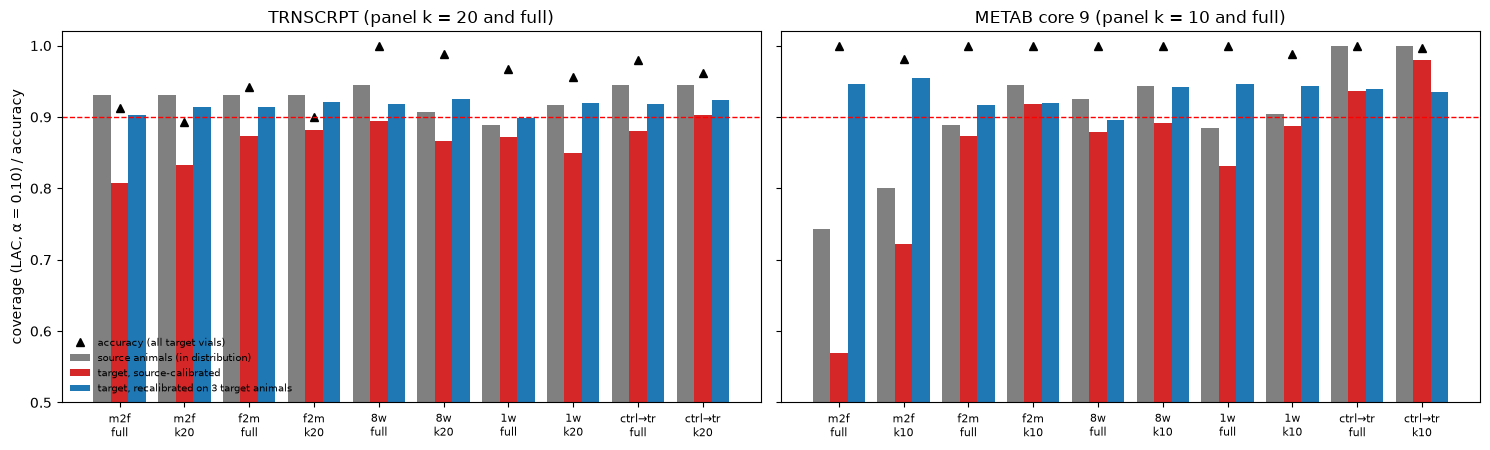

In [61]:
# One figure: target coverage per split — source-calibrated vs in-distribution vs recalibrated on 3 target animals.
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), sharey=True)
for ax, (tbl, title) in zip(axes, ((s08_trn, "TRNSCRPT (panel k = 20 and full)"), (s08_met, "METAB core 9 (panel k = 10 and full)"))):
    lab = tbl["split"].map(short).str.replace("ctrl2trained", "ctrl→tr") + "\n" + tbl["arm"].str.replace("panel_", "")
    xx = np.arange(len(tbl))
    ax.bar(xx - 0.27, tbl["coverage_source_id"], 0.27, label="source animals (in distribution)", color="grey")
    ax.bar(xx, tbl["coverage_target_seen"], 0.27, label="target, source-calibrated", color="tab:red")
    ax.bar(xx + 0.27, tbl["cov_target_recal_N3"], 0.27, label="target, recalibrated on 3 target animals", color="tab:blue")
    ax.plot(xx, tbl["accuracy_all"], "k^", label="accuracy (all target vials)")
    ax.axhline(0.9, color="red", ls="--", lw=1)
    ax.set_xticks(xx, lab, fontsize=8)
    ax.set(title=title, ylim=(0.5, 1.02))
axes[0].set_ylabel("coverage (LAC, α = 0.10) / accuracy")
axes[0].legend(fontsize=7, frameon=False, loc="lower left")
fig.tight_layout()
fig.savefig(OUT / "s08" / "shift_summary.png", dpi=150)
plt.show()

**What this shows.** Metabolomics makes the point most sharply: a model trained on males classifies
every female vial correctly, yet the source-calibrated sets cover the female vials far less often
than 1 − α, with some tissues almost never covered (the per-tissue line above). The reason is that
the source-calibrated threshold encodes the source's *confidence*, and the classifier is less
confident — though still right — on the other sex; LAC then returns empty sets. Recalibrating on
3 target animals restores coverage to about 1 − α or above in every row, for both assays, and 5
animals do not do better — a few target animals buy the guarantee back. Compare the post-fix and
pre-fix columns: the fix lowered several source-calibrated target coverages (most visibly
metabolomics male→female, full model), which sharpens the headline rather than changing it.

**What it does not show.** Why the other sex is less confident (sex biology, arrival cohort, or
batch — they are confounded in this design). Coverage after recalibration is an average over 10
draws of 3 animals from a small target, not a guarantee for any one draw; and one-vial-per-animal
calibration, the exchangeable version, is not usable at these sizes (too few calibration points).

## Self-check: did this run reproduce the expected values?

Every headline number printed above was also stored with `record(...)`. This cell compares each one
with `expected_values.csv`:
- `published_value` is what the pipeline reported before the 2026-09-25 conformal-quantile fix;
- `reference_value` is what this notebook should reproduce now, after the fix (the same as published
  where the fix did not touch the number).

A row passes when |value − reference| ≤ tolerance. Tolerances were set per row before running the
notebook, and are never widened to make a row pass. A failure is a finding to explain, not a number to
tune. Rows the expected table lists for the *other* notebook are skipped.

In [62]:
section("99 self-check")
EXPECTED = pd.read_csv(NB / "expected_values.csv", dtype={"key": str, "section": str})
_got = pd.DataFrame.from_dict(CHECKS, orient="index")
_chk = EXPECTED.set_index("key").join(_got[["value"]] if len(_got) else pd.DataFrame(columns=["value"]), how="left")
_chk = _chk[_chk["notebook"] == NOTEBOOK_NAME] if "notebook" in _chk.columns else _chk
_chk["abs_diff"] = (_chk["value"] - _chk["reference_value"]).abs()
_chk["status"] = np.where(_chk["value"].isna(), "NOT RUN",
                          np.where(_chk["abs_diff"] <= _chk["tolerance"] + 1e-12, "pass", "FAIL"))
_chk["moved_by_fix"] = (_chk["published_value"] - _chk["reference_value"]).abs() > 1e-9
with pd.option_context("display.max_rows", 500, "display.precision", 4):
    display(_chk[["section", "published_value", "reference_value", "value", "tolerance", "abs_diff",
                  "status", "moved_by_fix", "source"]])
_unlisted = sorted(set(CHECKS) - set(EXPECTED["key"]))
print(_chk["status"].value_counts().to_string())
if _unlisted:
    print("recorded but not in expected_values.csv:", _unlisted)
_chk.reset_index().to_csv(OUT / f"selfcheck_{NOTEBOOK_NAME.replace('.ipynb', '')}.csv", index=False)

,section,published_value,reference_value,value,tolerance,abs_diff,status,moved_by_fix,source
key,,,,,,,,,
s01.n_animals,01,1.4700e+02,1.4700e+02,1.4700e+02,1.0000e-09,0.0000e+00,pass,False,results/02_inventory/summary.json (n_animals)
s01.n_vials,01,6.1560e+03,6.1560e+03,6.1560e+03,1.0000e-09,0.0000e+00,pass,False,results/REPORT.md §02 (Animals in PHENO: 147; ...
s01.max_pid_per_bid,01,1.0000e+00,1.0000e+00,1.0000e+00,1.0000e-09,0.0000e+00,pass,False,docs/DATA_GUIDE.md (147 bids <-> 147 pids)
s01.max_bid_per_pid,01,1.0000e+00,1.0000e+00,1.0000e+00,1.0000e-09,0.0000e+00,pass,False,docs/DATA_GUIDE.md (147 bids <-> 147 pids)
s01.n_tables,01,9.2000e+01,9.2000e+01,9.2000e+01,1.0000e-09,0.0000e+00,pass,False,results/02_inventory/summary.json (tables)
s01.n_unmatched_after_fallback,01,0.0000e+00,0.0000e+00,0.0000e+00,1.0000e-09,0.0000e+00,pass,False,results/SUMMARY.md (Unmatched samples: 0)
s01.n_bid_fallback,01,NaN,2.0000e+00,2.0000e+00,1.0000e-09,0.0000e+00,pass,False,this notebook (new count; not in pipeline resu...
s01.n_fusion_tissues,01,7.0000e+00,7.0000e+00,7.0000e+00,1.0000e-09,0.0000e+00,pass,False,results/02_inventory/summary.json (fusion_tiss...
s01.fusion_common_bid_total,01,3.4500e+02,3.4500e+02,3.4500e+02,1.0000e-09,0.0000e+00,pass,False,results/02_inventory/fusion_overlap.csv (sum o...


status
pass    152


In [63]:
# Run time, per section and in total (this run, this machine).
_t = timing_table()
display(_t)
_t.to_csv(OUT / f"timings_{NOTEBOOK_NAME.replace('.ipynb', '')}_{'recompute' if RECOMPUTE else 'default'}.csv")

,seconds
0 setup + library,0.6
1 Setup and data inventory,6.6
2 PCA and variance partition,13.7
3 Proteomics diagnostic,2.6
4 baselines,27.1
5 panels,74.2
6 conformal sets,12.4
7 certificate,0.3
8 shift tests,40.9
99 self-check,0.0


### Where the code came from
The cell below reads this notebook's own file and lists every provenance comment. These are the lines
that name the pipeline source a block was copied from: `src/tfp/*.py` for the library cells, and
`scripts/*.py::function` for the script logic. It also lists every helper marked notebook-only (not in
the pipeline).

In [64]:
import nbformat as _nbf
_nbpath = NB / NOTEBOOK_NAME
if _nbpath.exists():
    _rows = []
    for _i, _c in enumerate(_nbf.read(_nbpath, 4).cells):
        if _c.cell_type != "code":
            continue
        for _ln in _c.source.splitlines():
            _m = re.search(r"(copied verbatim from src/tfp/\S+|from (?:scripts|code/probes)/[\w./]+(?:::[\w, .]+)?|notebook-only helper)", _ln)
            if _m and _ln.lstrip().startswith("#"):
                _rows.append({"cell": _i, "provenance": _m.group(1).strip(" ,.")})
    _prov = pd.DataFrame(_rows).drop_duplicates("provenance")
    with pd.option_context("display.max_rows", 300, "display.max_colwidth", 120):
        display(_prov.reset_index(drop=True))
else:
    print("notebook file not found next to the kernel's working directory:", _nbpath)

,cell,provenance
0,4,notebook-only helper
1,6,copied verbatim from src/tfp/config.py
2,8,copied verbatim from src/tfp/io.py
3,10,copied verbatim from src/tfp/splits.py
4,12,copied verbatim from src/tfp/models.py
5,14,copied verbatim from src/tfp/conformal.py
6,16,copied verbatim from src/tfp/discordance.py
7,18,copied verbatim from src/tfp/transfer.py
8,20,copied verbatim from src/tfp/plots.py
9,24,"from scripts/02_inventory.py::main, verbatim"
